# Example notebook for optimize module

In the following we exemplify how to utilize the optimize module of pyMOE which uses gradient descent methods for inverse design of masks. Some metrics are introduced which can be used for loss function constructions. 

Documentation will be updated in future release 

In [1]:
# Notebook display options, change as your preference/system
%matplotlib inline
%config InlineBackend.print_figure_kwargs={'facecolor' : "w",'bbox_inches':None}

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 120


import sys
sys.path.insert(0,'..')
sys.path.insert(0,'../..')

from matplotlib import pyplot as plt 
import numpy as np 

from scipy.constants import micro, nano, milli

import pyMOE as moe 
from pyMOE.generate import *  
from pyMOE.propagate import * 
from pyMOE.metrics import * 
from pyMOE.optimizer import * 
from pyMOE.ensemble import * 

In [2]:
# Notebook display options, change as your preference/system
%matplotlib inline
%config InlineBackend.print_figure_kwargs={'facecolor' : "w",'bbox_inches':None}

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 120

In [3]:
import sys
sys.path.insert(0,'..')
sys.path.insert(0,'../..')

from matplotlib import pyplot as plt 
import numpy as np 

from scipy.constants import micro, nano, milli

import pyMOE as moe 
from pyMOE.generate import *  
from pyMOE.propagate import * 
from pyMOE.metrics import * 
from pyMOE.optimizer import * 


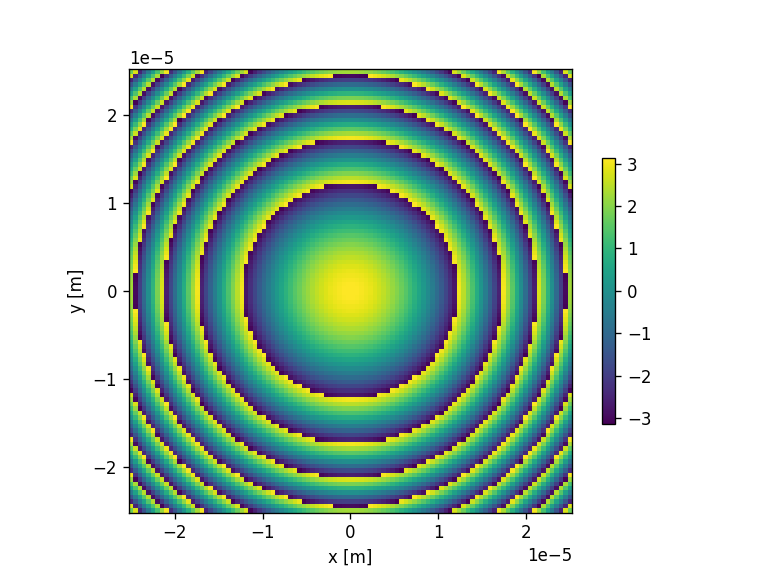

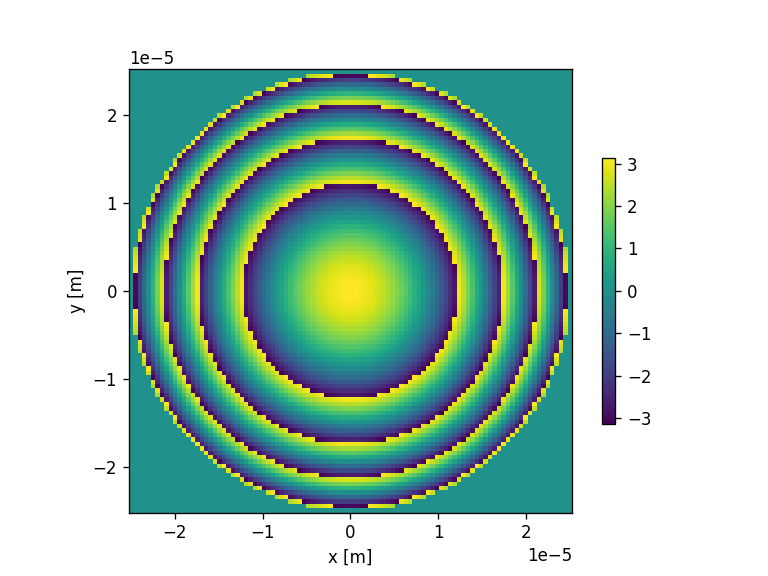

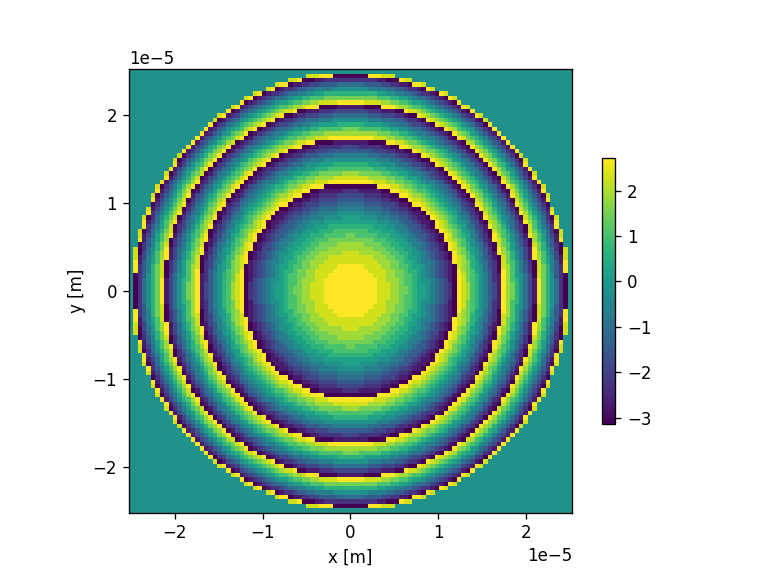

In [4]:
#number of pixels 
x_pixel = 100
y_pixel = 100

#size of the rectangular mask 
aperture_width  = 50e-6 #m
aperture_height = 50e-6

pixsize = 1e-6 #m

wavelength = 500e-9 #m
focal_length = 150e-6

zmin = wavelength
zmax = 1.2* focal_length
nzs = 500

radius = aperture_width/2 

# Create Aperture
aperture1 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)

# Populate Aperture with Fresnel mask 
mask1 = moe.generate.fresnel_phase(aperture1, focal_length, wavelength )

moe.plotting.plot_aperture(mask1)


##############
###Fresnel mask with a truncated circular aperture 

# Create empty mask
aperture2 = moe.generate.create_empty_aperture_from_aperture(aperture1)

# and truncate around radius
mask2 = moe.generate.fresnel_phase(aperture2, focal_length, wavelength, radius=radius)
moe.plotting.plot_aperture(mask2)

# Discretize mask in number of levels
# Select exact position of contours  in phase
phase_vals = np.linspace(-np.pi, np.pi, 16)

mask2.discretize(np.array( phase_vals)[:] ) 
moe.plotting.plot_aperture(mask2)

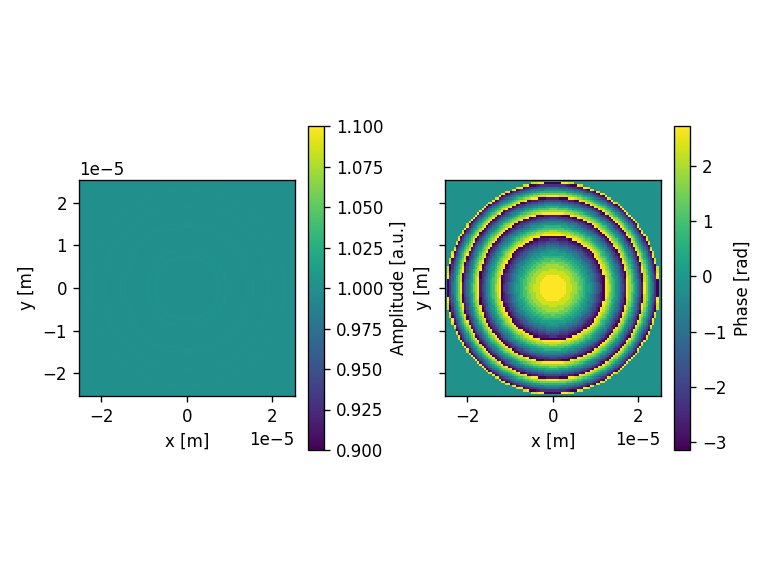

In [5]:
# Generate a uniform field
field = moe.field.create_empty_field_from_aperture(mask2)

field = moe.field.generate_uniform_field(field, E0=1)

# Modulates the field 
field = moe.field.modulate_field(field, amplitude_mask=None, phase_mask=mask2 )

# Plots the field (amplitude and phase)
moe.plotting.plot_field(field)

plt.tight_layout()
plt.show()


In [6]:
#Initial guess
x_pixel, y_pixel = 100, 100


x0 = np.random.rand(x_pixel, y_pixel) 
x0_flatten = x0.flatten()


xi = np.arange(x_pixel)
yi = np.arange(y_pixel)
XX, YY = np.meshgrid(xi,yi)
 

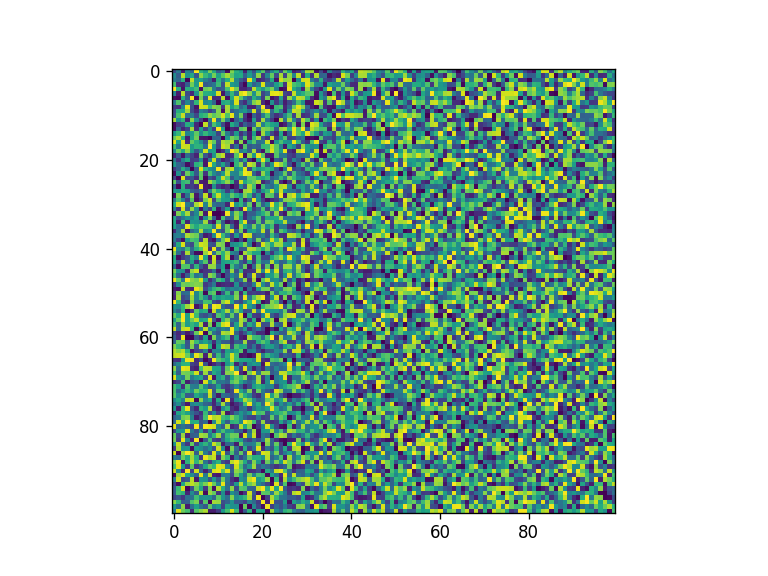

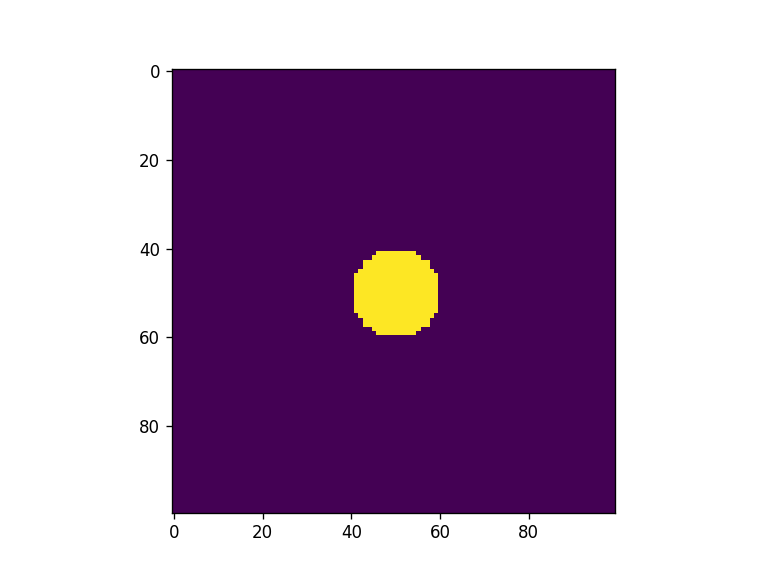

In [7]:
#create target     
matrix = np.zeros((x_pixel, y_pixel))
matrix[np.where(((XX-x_pixel/2)**2 + (YY-y_pixel/2)**2) < 10**2)] = 1 

matrix_flat = matrix.flatten()

fig = plt.figure() 
plt.imshow(x0)


fig = plt.figure() 
plt.imshow(matrix)

In [8]:
#Define Screen 

# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -aperture_height/2, aperture_height/2
xmin, xmax = -aperture_width/2, aperture_width/2

x = np.linspace(xmin, xmax, x_pixel)
y = np.linspace(ymin, ymax, y_pixel)
z = np.array([focal_length])


screen = moe.field.Screen(x,y,z)

Elapsed: 0:00:00.970387


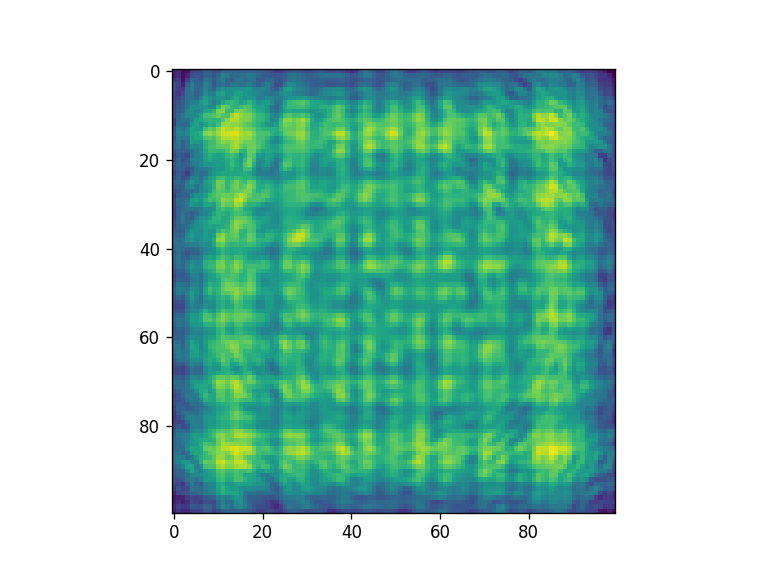

In [9]:
##check initial guess propagation 
prop = np.array(moe.optimizer.propagate(x0, mask2, screen, wavelength ))

fig = plt.figure() 
plt.imshow(np.abs(prop))

In [12]:
#Define loss functions 

def FOM(x, mask, screen, wavelength, mat=matrix_flat):
    #print("Type of x:", type(x), "First element:", x[0])
    #print("Type of x:", type(mask))
    #print("Type of x:", type(screen), "First element:", x[0])
    #print("Type of x:", type(wavelength), "First element:", x[0])
    import jax.numpy as np 
    
    prop_x = np.abs(moe.optimizer.propagate(np.reshape(x, (x_pixel, y_pixel)), mask, screen, wavelength).flatten())
    res = np.log(np.sum(((prop_x/np.max(prop_x)-mat/np.max(mat))**2)))
    #print(res)
    return res



def FOM2(x, mask, screen, wavelength, mat=matrix_flat): 
    #print("Type of x:", type(x), "First element:", x[0])
    #print("Type of x:", type(mask))
    #print("Type of x:", type(screen), "First element:", x[0])
    #print("Type of x:", type(wavelength), "First element:", x[0])
    import jax.numpy as np 
    
    prop_x = np.abs(moe.optimizer.propagate(np.reshape(x, (x_pixel, y_pixel)), mask, screen, wavelength).flatten())
    prop_x = np.reshape(prop_x, (x_pixel, y_pixel))
    midx, midy = int(x_pixel/2), int(y_pixel/2)
    mat = np.reshape(mat, (x_pixel, y_pixel))
    
    res = np.log(np.sum(((prop_x/np.max(prop_x)/(prop_x[(midx,midy)]/np.max(prop_x)) - mat/np.max(mat))**2)))
    
    #print(res, prop_x[(midx,midy)])#(prop_x[midx]/np.max(prop_x)-mat[midy]/np.max(mat))**2)
    return res



def FOM3(x, mask, screen, wavelength, mat): 
    #print("Type of x:", type(x), "First element:", x[0])
    #print("Type of x:", type(mask))
    #print("Type of x:", type(screen), "First element:", x[0])
    #print("Type of x:", type(wavelength), "First element:", x[0])
    import jax.numpy as np 
    
    prop_x =  np.abs(moe.optimizer.propagate(np.reshape(x, (len(screen.x), len(screen.y))), mask, screen, wavelength))
    
    diff = np.abs(prop_x/np.max(prop_x) - mat/np.max(mat))**2
     
    print(diff.shape)
    res = np.sum(diff)
    #print(res)
    
    return res

def FOM_strehl(x, mask, screen, wavelength, mat): 
    #print("Type of x:", type(x), "First element:", x[0])
    #print("Type of x:", type(mask))
    #print("Type of x:", type(screen), "First element:", x[0])
    #print("Type of x:", type(wavelength), "First element:", x[0])
    import jax.numpy as np 
    
    #prop_x =  np.abs(moe.optimizer.propagate(np.reshape(x, (len(screen.x), len(screen.y))), mask, screen, wavelength))
    
    diff = 1 - moe.metrics.strehl_ratio(np.abs(np.reshape(x, (len(screen.x), len(screen.y))))**2, screen, \
                                        np.max(screen.x) - np.min(screen.x), wavelength, z = screen.z[-1])
     
    #print(diff.shape)
    #res = np.sum(diff)
    #print(res)
    
    return diff

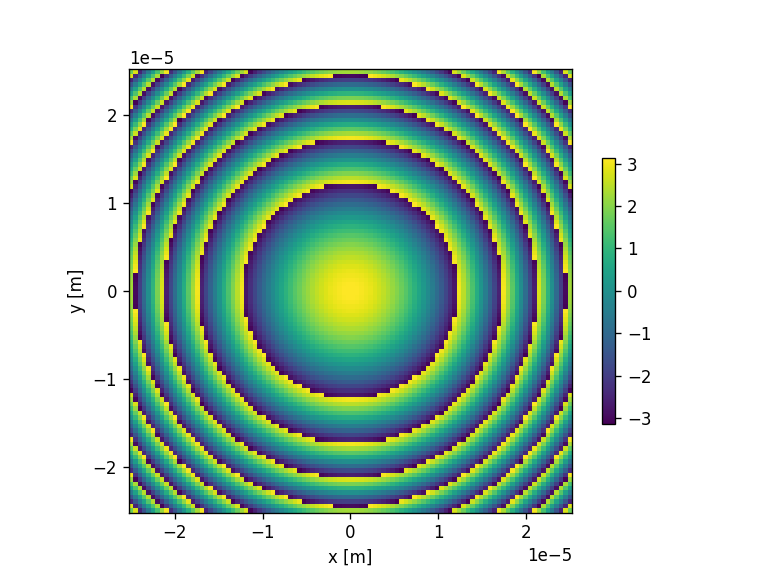

In [11]:
# Create Aperture
aperture1 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)

# Populate Aperture with Fresnel mask 
mask2 = moe.generate.fresnel_phase(aperture1, focal_length, wavelength )

moe.plotting.plot_aperture(mask2)

Elapsed: 0:00:00.025037


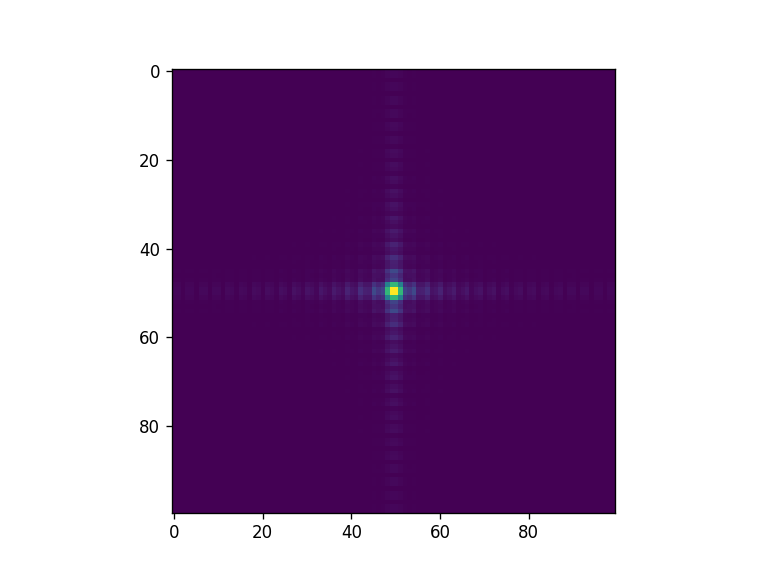

In [12]:
fig = plt.figure() 
plt.imshow(np.abs(np.array(propagate(mask2.aperture, mask2, screen, wavelength) ) ))

Elapsed: 0:00:00.013021
Elapsed: 0:00:00.261121
Elapsed: 0:00:00.015707
Elapsed: 0:00:00.015630
Elapsed: 0:00:00.015584
Elapsed: 0:00:00.031471
Elapsed: 0:00:00.015618
Elapsed: 0:00:00.031246
Elapsed: 0:00:00.035277
Elapsed: 0:00:00.031050
Elapsed: 0:00:00.015671
Elapsed: 0:00:00.025759
Elapsed: 0:00:00.015615
Elapsed: 0:00:00.031240
Elapsed: 0:00:00.008856
Elapsed: 0:00:00.013080
Elapsed: 0:00:00.023191
Elapsed: 0:00:00.015623
Elapsed: 0:00:00.015576
Elapsed: 0:00:00.031287
Elapsed: 0:00:00
Elapsed: 0:00:00.015607
Elapsed: 0:00:00.013539
Elapsed: 0:00:00.042447
Elapsed: 0:00:00
Elapsed: 0:00:00.025801
Elapsed: 0:00:00.015618
Elapsed: 0:00:00.169976
Elapsed: 0:00:00.012285
Elapsed: 0:00:00.013982
Elapsed: 0:00:00.010042
Elapsed: 0:00:00.015664
Elapsed: 0:00:00.015584
Elapsed: 0:00:00.015582
Elapsed: 0:00:00.040725
Elapsed: 0:00:00.003020
Elapsed: 0:00:00.031418
Elapsed: 0:00:00.015624
Elapsed: 0:00:00.016750
Elapsed: 0:00:00.025742
Elapsed: 0:00:00.014306
Elapsed: 0:00:00.021229
Elapse

Elapsed: 0:00:00.015666
Elapsed: 0:00:00.029242
Elapsed: 0:00:00.015659
Elapsed: 0:00:00.025772
Elapsed: 0:00:00
Elapsed: 0:00:00.015656
Elapsed: 0:00:00.010041
Elapsed: 0:00:00.036800
Elapsed: 0:00:00.015658
Elapsed: 0:00:00.031250
Elapsed: 0:00:00
Elapsed: 0:00:00.015660
Elapsed: 0:00:00
Elapsed: 0:00:00.039545
Elapsed: 0:00:00
Elapsed: 0:00:00.015622
Elapsed: 0:00:00.031350
Elapsed: 0:00:00.035133
Elapsed: 0:00:00.005141
Elapsed: 0:00:00.015666
Elapsed: 0:00:00.021515
Elapsed: 0:00:00.020782
Elapsed: 0:00:00.015622
Elapsed: 0:00:00.015623
Elapsed: 0:00:00.015730
Elapsed: 0:00:00.036735
Elapsed: 0:00:00
Elapsed: 0:00:00.041454
Elapsed: 0:00:00.015623
Elapsed: 0:00:00.031278
Elapsed: 0:00:00.011027
Elapsed: 0:00:00.011039
Elapsed: 0:00:00.015590
Elapsed: 0:00:00.025802
Elapsed: 0:00:00.015621
Elapsed: 0:00:00.031245
Elapsed: 0:00:00.015851
Elapsed: 0:00:00.025262
Elapsed: 0:00:00.015763
Elapsed: 0:00:00.015663
Elapsed: 0:00:00.015623
Elapsed: 0:00:00.015622
Elapsed: 0:00:00.015661
Ela

Elapsed: 0:00:00.040843
Elapsed: 0:00:00.009966
Elapsed: 0:00:00.015657
Elapsed: 0:00:00.007019
Elapsed: 0:00:00.031285
Elapsed: 0:00:00.015622
Elapsed: 0:00:00.025725
Elapsed: 0:00:00.011322
Elapsed: 0:00:00.018152
Elapsed: 0:00:00.015661
Elapsed: 0:00:00.031245
Elapsed: 0:00:00
Elapsed: 0:00:00.025856
Elapsed: 0:00:00.020421
Elapsed: 0:00:00.042770
Elapsed: 0:00:00.015584
Elapsed: 0:00:00.130619
Elapsed: 0:00:00.011697
Elapsed: 0:00:00.044066
Elapsed: 0:00:00.012020
Elapsed: 0:00:00.028689
Elapsed: 0:00:00.012112
Elapsed: 0:00:00.022614
Elapsed: 0:00:00.015619
Elapsed: 0:00:00.031884
Elapsed: 0:00:00
Elapsed: 0:00:00.031277
Elapsed: 0:00:00
Elapsed: 0:00:00.027846
Elapsed: 0:00:00.005011
Elapsed: 0:00:00.031923
Elapsed: 0:00:00.015622
Elapsed: 0:00:00.031196
Elapsed: 0:00:00.016290
Elapsed: 0:00:00.015672
Elapsed: 0:00:00.009993
Elapsed: 0:00:00.016265
Elapsed: 0:00:00.015616
Elapsed: 0:00:00.031202
Elapsed: 0:00:00
Elapsed: 0:00:00.031289
Elapsed: 0:00:00
Elapsed: 0:00:00.032990
Ela

Elapsed: 0:00:00.012908
Elapsed: 0:00:00.013526
Elapsed: 0:00:00.015623
Elapsed: 0:00:00.015624
Elapsed: 0:00:00.015662
Elapsed: 0:00:00.031243
Elapsed: 0:00:00.015622
Elapsed: 0:00:00.038518
Elapsed: 0:00:00.009040
Elapsed: 0:00:00.031280
Elapsed: 0:00:00.015617
Elapsed: 0:00:00.031245
Elapsed: 0:00:00
Elapsed: 0:00:00.059001
Elapsed: 0:00:00.015622
Elapsed: 0:00:00.031846
Elapsed: 0:00:00.015622
Elapsed: 0:00:00.031279
Elapsed: 0:00:00
Elapsed: 0:00:00.015655
Elapsed: 0:00:00.021127
Elapsed: 0:00:00.031281
Elapsed: 0:00:00.015625
Elapsed: 0:00:00.031819
Elapsed: 0:00:00
Elapsed: 0:00:00.015622
Elapsed: 0:00:00
Elapsed: 0:00:00.026722
Elapsed: 0:00:00
Elapsed: 0:00:00.047551
Elapsed: 0:00:00.015598
Elapsed: 0:00:00.015643
Elapsed: 0:00:00.016309
Elapsed: 0:00:00.052153
Elapsed: 0:00:00.015657
Elapsed: 0:00:00.016267
Elapsed: 0:00:00.015580
Elapsed: 0:00:00.031279
Elapsed: 0:00:00.016289
Elapsed: 0:00:00.031282
Elapsed: 0:00:00.014223
Elapsed: 0:00:00.034274
Elapsed: 0:00:00.015659
Ela

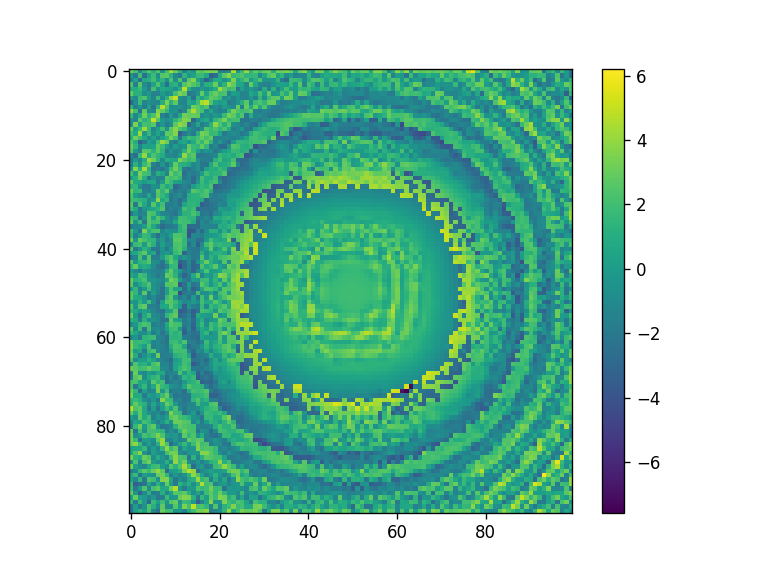

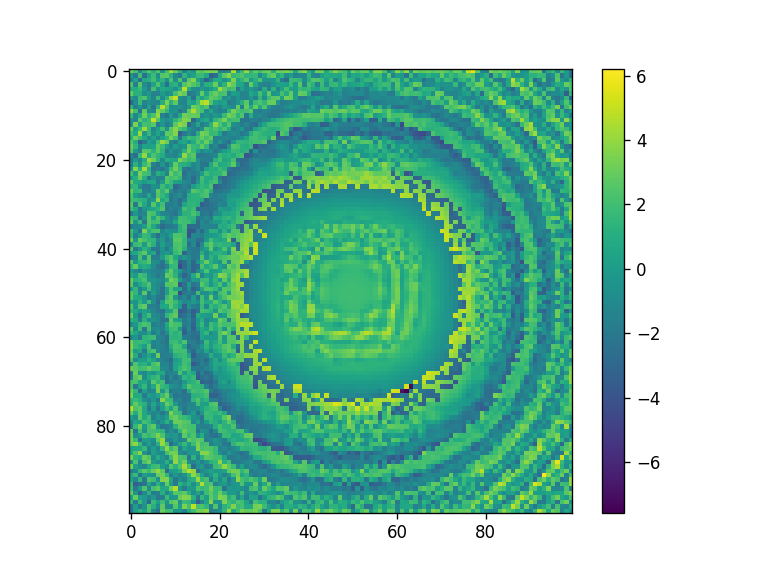

In [13]:
#optimize using the optimizer module 

solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=[mask2, screen, wavelength, matrix], verbose = 1, ftol=1e-4)

x = solution.x

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()

Elapsed: 0:00:00.013062
Elapsed: 0:00:00.012018


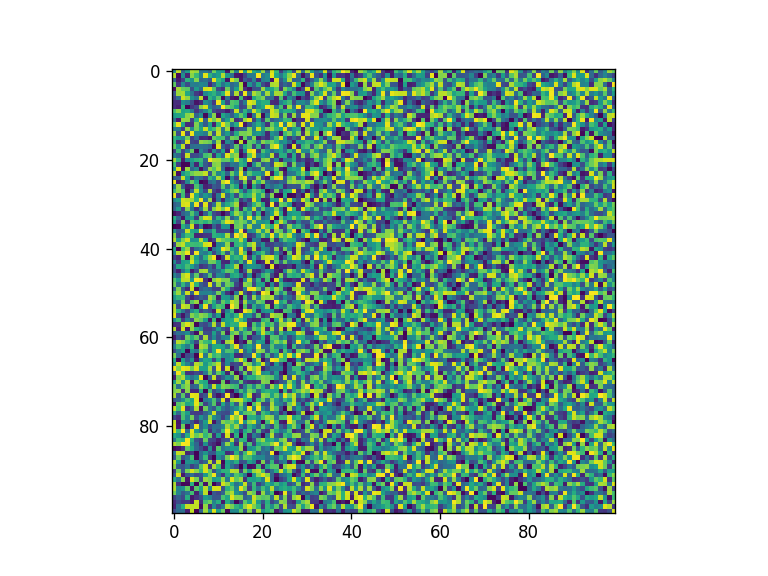

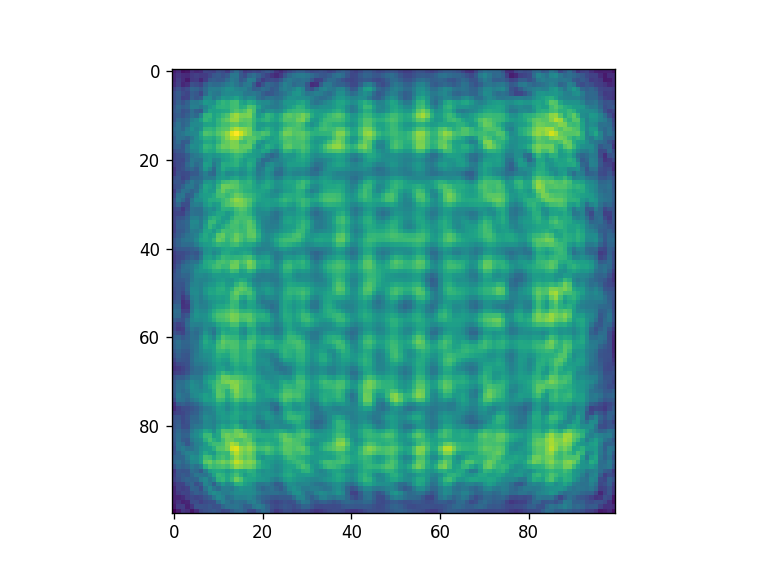

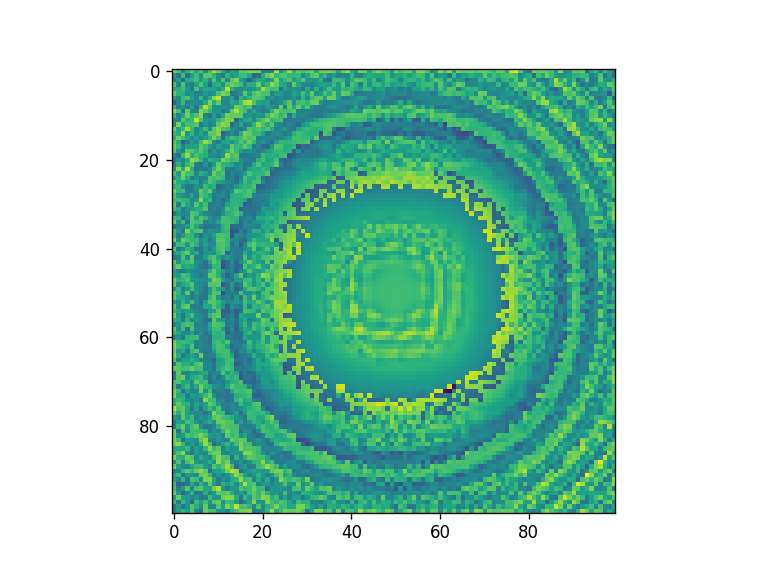

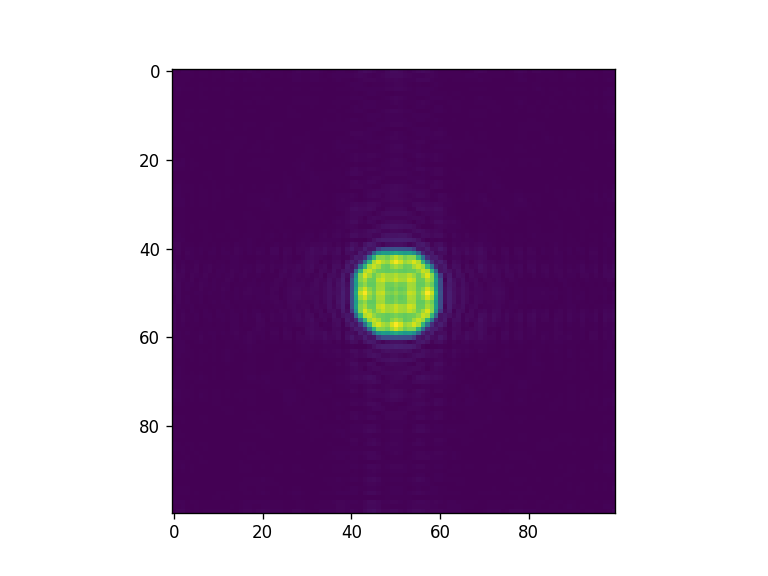

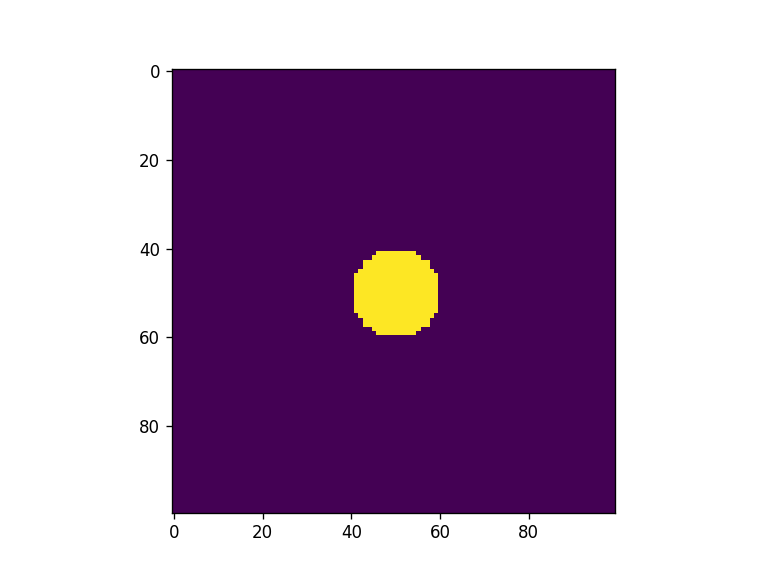

In [14]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, mask2, screen, wavelength) ) )

fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, mask2, screen, wavelength) ) )


fig = plt.figure() 
plt.imshow(np.reshape(matrix, (x_pixel, y_pixel)) )


In [15]:
def FOM3(x, mask, screen, wavelength, mat): 
    #print("Type of x:", type(x), "First element:", x[0])
    #print("Type of x:", type(mask))
    #print("Type of x:", type(screen), "First element:", x[0])
    #print("Type of x:", type(wavelength), "First element:", x[0])
    import jax.numpy as np 
    
    prop_x =  np.abs(moe.optimizer.propagate(np.reshape(x, (len(screen.x), len(screen.y))), mask, screen, wavelength))
    
    diff = np.abs(prop_x/prop_x[int(len(screen.x)/2), int(len(screen.y)/2)] - mat/np.max(mat))**2
     
    print(diff.shape)
    res = np.log(np.sum(diff))
    #print(res)
    
    return res

solution = moe.optimizer.optimize(FOM, x0_flatten, args1=[mask2, screen, wavelength, matrix_flat], verbose = 1, ftol=1e-6)

Elapsed: 0:00:00.022874
Elapsed: 0:00:00.029978
Elapsed: 0:00:00.015626
Elapsed: 0:00:00.015621
Elapsed: 0:00:00.025773
Elapsed: 0:00:00.167553
Elapsed: 0:00:00.010472
Elapsed: 0:00:00.031249
Elapsed: 0:00:00.031244
Elapsed: 0:00:00.041366
Elapsed: 0:00:00.015623
Elapsed: 0:00:00.035509
Elapsed: 0:00:00
Elapsed: 0:00:00.015661
Elapsed: 0:00:00.031206
Elapsed: 0:00:00.015634
Elapsed: 0:00:00.047249
Elapsed: 0:00:00.011218
Elapsed: 0:00:00.019113
Elapsed: 0:00:00
Elapsed: 0:00:00.025747
Elapsed: 0:00:00.015622
Elapsed: 0:00:00.039866
Elapsed: 0:00:00.013277
Elapsed: 0:00:00.026637
Elapsed: 0:00:00.015711
Elapsed: 0:00:00.025634
Elapsed: 0:00:00
Elapsed: 0:00:00.035214
Elapsed: 0:00:00.012066
Elapsed: 0:00:00.021614
Elapsed: 0:00:00.010040
Elapsed: 0:00:00.031250
Elapsed: 0:00:00.015622
Elapsed: 0:00:00.049974
Elapsed: 0:00:00.023159
Elapsed: 0:00:00.041383
Elapsed: 0:00:00
Elapsed: 0:00:00.015621
Elapsed: 0:00:00.010041
Elapsed: 0:00:00.026998
Elapsed: 0:00:00.012273
Elapsed: 0:00:00.025

Elapsed: 0:00:00.011947
Elapsed: 0:00:00.011948


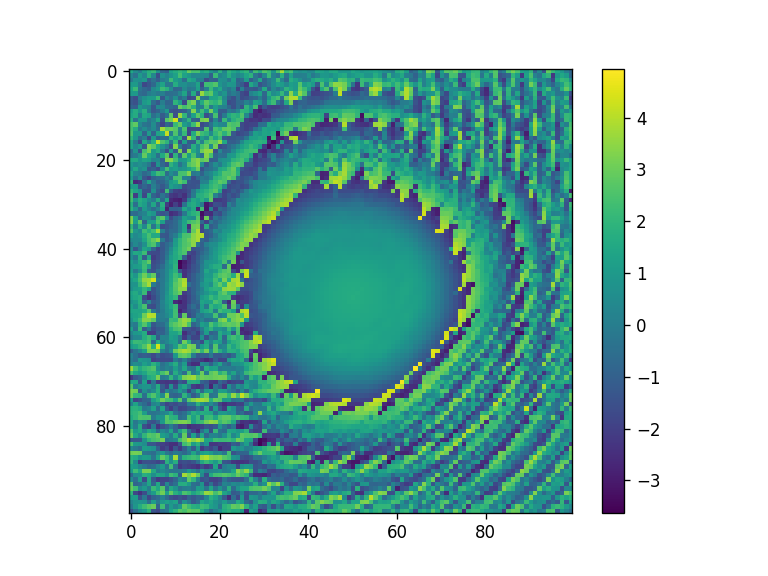

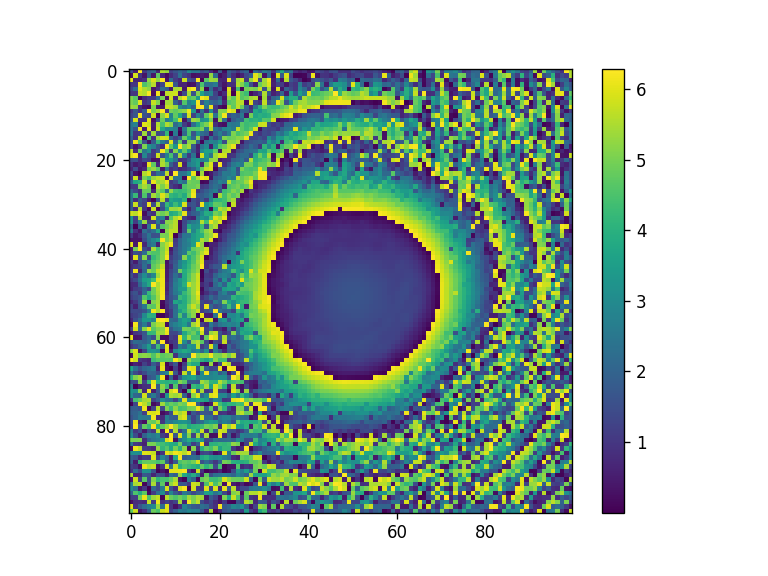

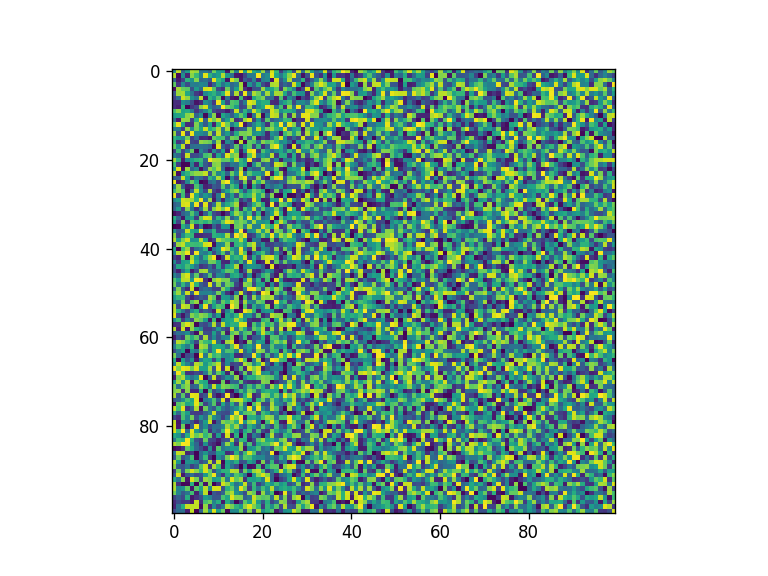

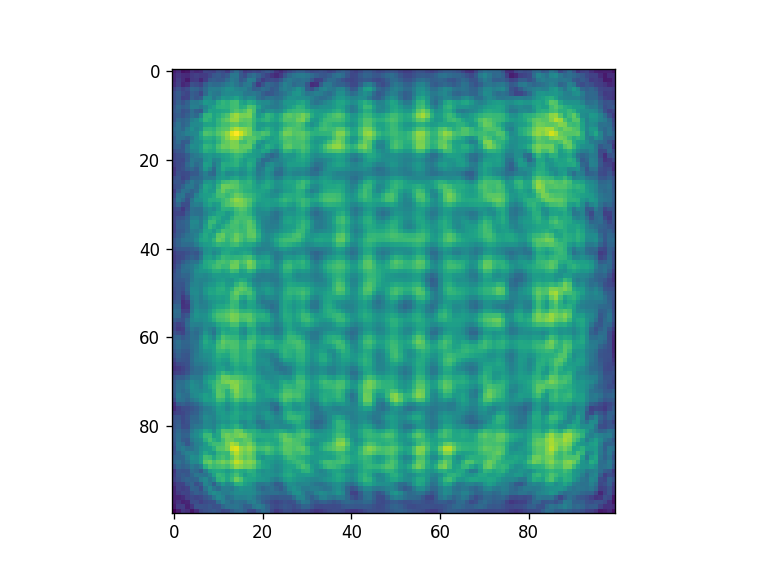

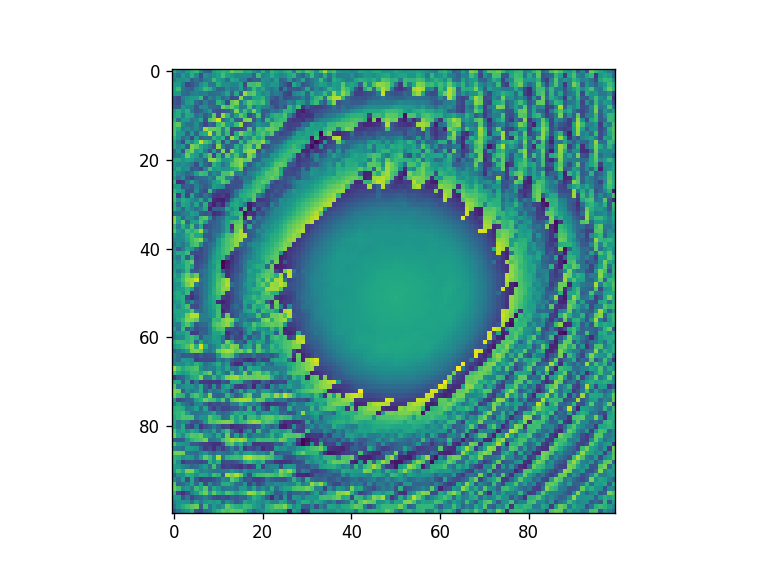

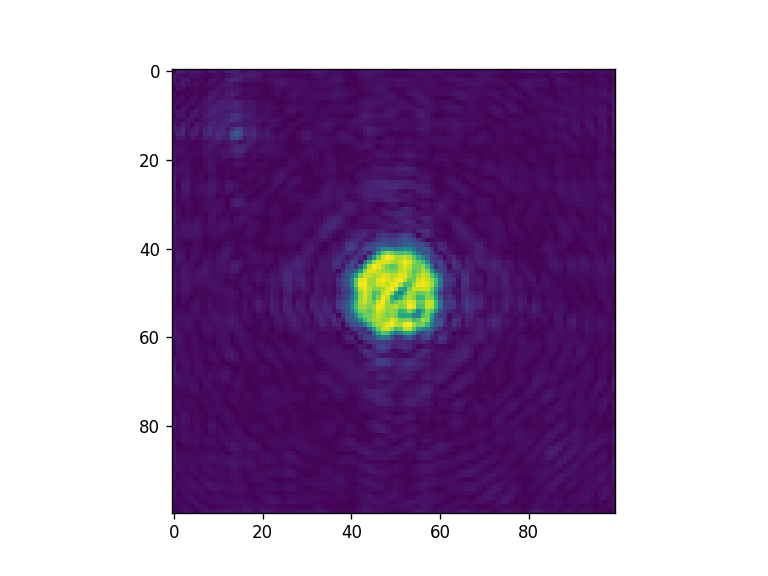

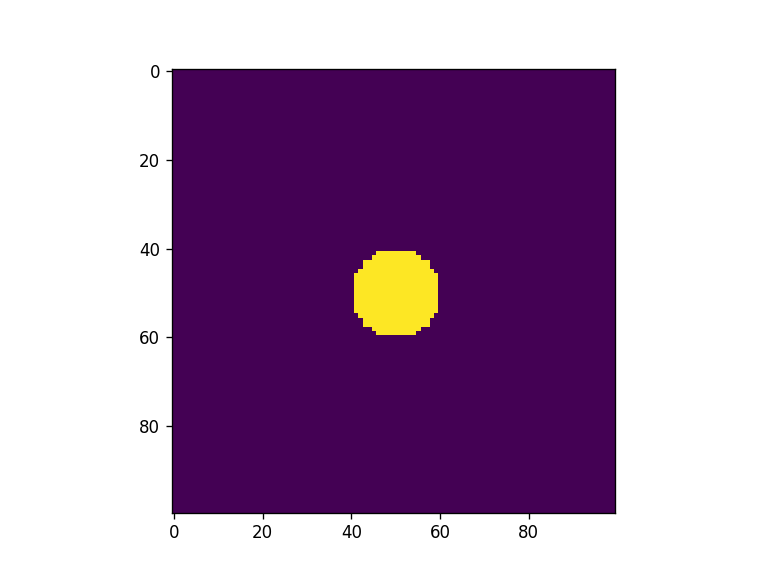

In [16]:
x = solution.x

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar%(2*np.pi)) 
plt.colorbar()

fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, mask2, screen, wavelength) ) )

fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, mask2, screen, wavelength) ) )


fig = plt.figure() 
plt.imshow(np.reshape(matrix, (x_pixel, y_pixel)) )


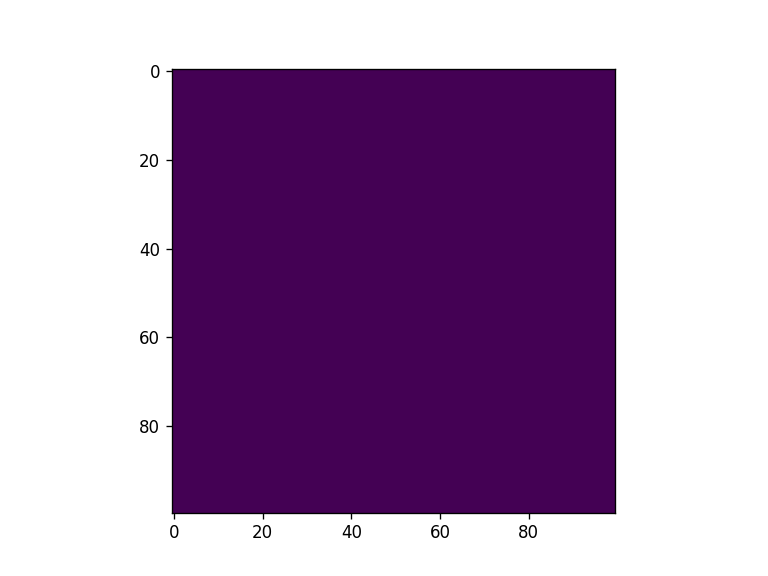

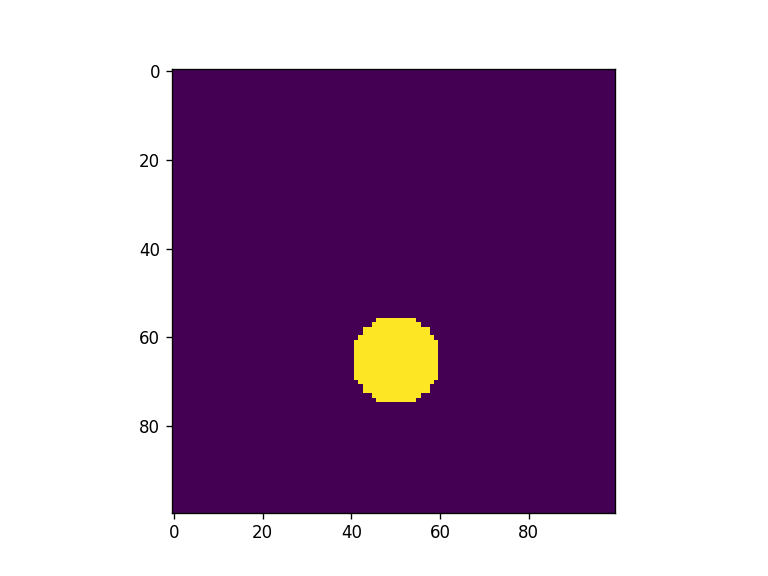

In [17]:
#Initial guess
x_pixel, y_pixel = 100, 100


x0 = np.random.rand(x_pixel, y_pixel)
x0 = np.ones((x_pixel, y_pixel))
x0_flatten = x0.flatten()


xi = np.arange(x_pixel)
yi = np.arange(y_pixel)
XX, YY = np.meshgrid(xi,yi)
    
matrix = np.zeros((x_pixel, y_pixel))
matrix[np.where(((XX-x_pixel/2- 0)**2 + (YY-y_pixel/2-15)**2) < 10**2)] = 1 

matrix_flat = matrix.flatten()

fig = plt.figure() 
plt.imshow(x0)


fig = plt.figure() 
plt.imshow(matrix)


Elapsed: 0:00:00.014093
(100, 100)
Elapsed: 0:00:00.046305
(100, 100)
Elapsed: 0:00:00.013083
(100, 100)
Elapsed: 0:00:00.042010
(100, 100)
Elapsed: 0:00:00.012061
(100, 100)
Elapsed: 0:00:00.028089
(100, 100)
Elapsed: 0:00:00.011050
(100, 100)
Elapsed: 0:00:00.044138
(100, 100)
Elapsed: 0:00:00.008003
(100, 100)
Elapsed: 0:00:00.031281
(100, 100)
Elapsed: 0:00:00.015586
(100, 100)
Elapsed: 0:00:00.015752
(100, 100)
Elapsed: 0:00:00.025669
(100, 100)
Elapsed: 0:00:00.015656
(100, 100)
Elapsed: 0:00:00.015588
(100, 100)
Elapsed: 0:00:00.036472
(100, 100)
Elapsed: 0:00:00.006104
(100, 100)
Elapsed: 0:00:00.015623
(100, 100)
Elapsed: 0:00:00.015628
(100, 100)
Elapsed: 0:00:00.031278
(100, 100)
Elapsed: 0:00:00.015589
(100, 100)
Elapsed: 0:00:00.035409
(100, 100)
Elapsed: 0:00:00.010952
(100, 100)
Elapsed: 0:00:00.027615
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00.015621
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00.010048
(100, 100)
Elapse

Elapsed: 0:00:00.038928
(100, 100)
Elapsed: 0:00:00.003025
(100, 100)
Elapsed: 0:00:00.015625
(100, 100)
Elapsed: 0:00:00.031277
(100, 100)
Elapsed: 0:00:00.010047
(100, 100)
Elapsed: 0:00:00.031249
(100, 100)
Elapsed: 0:00:00.015623
(100, 100)
Elapsed: 0:00:00.031278
(100, 100)
Elapsed: 0:00:00.012195
(100, 100)
Elapsed: 0:00:00.010010
(100, 100)
Elapsed: 0:00:00.034294
(100, 100)
Elapsed: 0:00:00.015661
(100, 100)
Elapsed: 0:00:00.031211
(100, 100)
Elapsed: 0:00:00.031431
(100, 100)
Elapsed: 0:00:00.036902
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00.025772
(100, 100)
Elapsed: 0:00:00.015657
(100, 100)
Elapsed: 0:00:00.190382
(100, 100)
Elapsed: 0:00:00.015663
(100, 100)
Elapsed: 0:00:00.031310
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00.031245
(100, 100)
Elapsed: 0:00:00.010007
(100, 100)
Elapsed: 0:00:00.038805
(100, 100)
Elapsed: 0:00:00.006006
(100, 100)
Elapsed: 0:00:00.031359
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00

Elapsed: 0:00:00.015777
(100, 100)
Elapsed: 0:00:00.036304
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00.031408
(100, 100)
Elapsed: 0:00:00.015622
(100, 100)
Elapsed: 0:00:00.015622
(100, 100)
Elapsed: 0:00:00.015739
(100, 100)
Elapsed: 0:00:00.032193
(100, 100)
Elapsed: 0:00:00.015623
(100, 100)
Elapsed: 0:00:00.025760
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00.015586
(100, 100)
Elapsed: 0:00:00.011947
(100, 100)
Elapsed: 0:00:00.013961
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00.025704
(100, 100)
Elapsed: 0:00:00.015657
(100, 100)
Elapsed: 0:00:00.031248
(100, 100)
Elapsed: 0:00:00.010007
(100, 100)
Elapsed: 0:00:00.040732
(100, 100)
Elapsed: 0:00:00.020359
(100, 100)
Elapsed: 0:00:00.025710
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00.015586
(100, 100)
Elapsed: 0:00:00.010049
(100, 100)
Elapsed: 0:00:00.031249
(100, 100)
Elapsed: 0:00:00.012100
(100, 100)
Elapsed: 0:00:00.027855
(100, 100)
Elapsed: 0:00:00.015657
(100, 100)
Elapsed: 0:00

Elapsed: 0:00:00.039542
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00.015586
(100, 100)
Elapsed: 0:00:00.010007
(100, 100)
Elapsed: 0:00:00.015661
(100, 100)
Elapsed: 0:00:00.015621
(100, 100)
Elapsed: 0:00:00.015656
(100, 100)
Elapsed: 0:00:00.011228
(100, 100)
Elapsed: 0:00:00.014963
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00.025703
(100, 100)
Elapsed: 0:00:00.015624
(100, 100)
Elapsed: 0:00:00.031210
(100, 100)
Elapsed: 0:00:00.010047
(100, 100)
Elapsed: 0:00:00.041889
(100, 100)
Elapsed: 0:00:00.002118
(100, 100)
Elapsed: 0:00:00.031406
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00.015619
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00.025708
(100, 100)
Elapsed: 0:00:00.022420
(100, 100)
Elapsed: 0:00:00.031397
(100, 100)
Elapsed: 0:00:00.015624
(100, 100)
Elapsed: 0:00:00.015622
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00.025706
(100, 100)
Elapsed: 0:00:00.015655
(100, 100)
Elapsed: 0:00:00.035605
(100, 100)
Elapsed: 0:00:00.002

Elapsed: 0:00:00.026938
(100, 100)
Elapsed: 0:00:00.028058
(100, 100)
Elapsed: 0:00:00.015627
(100, 100)
Elapsed: 0:00:00.031277
(100, 100)
Elapsed: 0:00:00.015659
(100, 100)
Elapsed: 0:00:00.047530
(100, 100)
Elapsed: 0:00:00.011268
(100, 100)
Elapsed: 0:00:00.024657
(100, 100)
Elapsed: 0:00:00.022269
(100, 100)
Elapsed: 0:00:00.015667
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00.015663
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00.040666
(100, 100)
Elapsed: 0:00:00.011948
(100, 100)
Elapsed: 0:00:00.032484
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00.015661
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00.043171
(100, 100)
Elapsed: 0:00:00.002027
(100, 100)
Elapsed: 0:00:00.031279
(100, 100)
Elapsed: 0:00:00.016780
(100, 100)
Elapsed: 0:00:00.031249
(100, 100)
Elapsed: 0:00:00.015657
(100, 100)
Elapsed: 0:00:00.031209
(100, 100)
Elapsed: 0:00:00.021260
(100, 100)
Elapsed: 0:00:00.017781
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00.034

...

Elapsed: 0:00:00.012220
(100, 100)
Elapsed: 0:00:00.023028
(100, 100)
Elapsed: 0:00:00.015588
(100, 100)
Elapsed: 0:00:00.025762
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00.046866
(100, 100)
Elapsed: 0:00:00.027804
(100, 100)
Elapsed: 0:00:00.017363
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00.025671
(100, 100)
Elapsed: 0:00:00.015655
(100, 100)
Elapsed: 0:00:00.015622
(100, 100)
Elapsed: 0:00:00.009509
(100, 100)
Elapsed: 0:00:00.039083
(100, 100)
Elapsed: 0:00:00.007982
(100, 100)
Elapsed: 0:00:00.025812
(100, 100)
Elapsed: 0:00:00.015589
(100, 100)
Elapsed: 0:00:00.031279
(100, 100)
Elapsed: 0:00:00.015783
(100, 100)
Elapsed: 0:00:00.025667
(100, 100)
Elapsed: 0:00:00.026497
(100, 100)
Elapsed: 0:00:00.027286
(100, 100)
Elapsed: 0:00:00.015627
(100, 100)
Elapsed: 0:00:00.031279
(100, 100)
Elapsed: 0:00:00.015725
(100, 100)
Elapsed: 0:00:00.015627
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00.045352
(100, 100)
Elapsed: 0:00:00.015585
(100, 100)
Elapse

Elapsed: 0:00:00.013148
(100, 100)
Elapsed: 0:00:00.023611
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00.025700
(100, 100)
Elapsed: 0:00:00.015589
(100, 100)
Elapsed: 0:00:00.015656
(100, 100)
Elapsed: 0:00:00.010040
(100, 100)
Elapsed: 0:00:00.040401
(100, 100)
Elapsed: 0:00:00.004999
(100, 100)
Elapsed: 0:00:00.031386
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00.031209
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00.064705
(100, 100)
Elapsed: 0:00:00.006008
(100, 100)
Elapsed: 0:00:00.025794
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00.015589
(100, 100)
Elapsed: 0:00:00.011168
(100, 100)
Elapsed: 0:00:00.015661
(100, 100)
Elapsed: 0:00:00.012080
(100, 100)
Elapsed: 0:00:00.041412
(100, 100)
Elapsed: 0:00:00.015661
(100, 100)
Elapsed: 0:00:00.031206
(100, 100)
Elapsed: 0:00:00.015731
(100, 100)
Elapsed: 0:00:00.041444
(100, 100)
Elapsed: 0:00:00.010951
(100, 100)
Elapsed: 0:00:00.015012
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00.031

Elapsed: 0:00:00.043287
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00.015622
(100, 100)
Elapsed: 0:00:00.019485
(100, 100)
Elapsed: 0:00:00.018697
(100, 100)
Elapsed: 0:00:00.015619
(100, 100)
Elapsed: 0:00:00.025732
(100, 100)
Elapsed: 0:00:00.012256
(100, 100)
Elapsed: 0:00:00.018194
(100, 100)
Elapsed: 0:00:00.015656
(100, 100)
Elapsed: 0:00:00.032418
(100, 100)
Elapsed: 0:00:00.025758
(100, 100)
Elapsed: 0:00:00.043059
(100, 100)
Elapsed: 0:00:00.015659
(100, 100)
Elapsed: 0:00:00.025725
(100, 100)
Elapsed: 0:00:00.015619
(100, 100)
Elapsed: 0:00:00.031209
(100, 100)
Elapsed: 0:00:00.015810
(100, 100)
Elapsed: 0:00:00.015664
(100, 100)
Elapsed: 0:00:00.012614
(100, 100)
Elapsed: 0:00:00.030849
(100, 100)
Elapsed: 0:00:00.031292
(100, 100)
Elapsed: 0:00:00.031196
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00.015623
(100, 100)
Elapsed: 0:00:00.007171
(100, 100)
Elapsed: 0:00:00.031245
(100, 100)
Elapsed: 0:00:00.015622
(100, 100)
Elapsed: 0:00:00.031352
(100, 100)

Elapsed: 0:00:00.017434
(100, 100)
Elapsed: 0:00:00.026399
(100, 100)
Elapsed: 0:00:00.015589
(100, 100)
Elapsed: 0:00:00.031440
(100, 100)
Elapsed: 0:00:00.015662
(100, 100)
Elapsed: 0:00:00.031210
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00.027922
(100, 100)
Elapsed: 0:00:00.001035
(100, 100)
Elapsed: 0:00:00.015623
(100, 100)
Elapsed: 0:00:00.015664
(100, 100)
Elapsed: 0:00:00.031209
(100, 100)
Elapsed: 0:00:00.031377
(100, 100)
Elapsed: 0:00:00.035479
(100, 100)
Elapsed: 0:00:00.015658
(100, 100)
Elapsed: 0:00:00.031330
(100, 100)
Elapsed: 0:00:00.015581
(100, 100)
Elapsed: 0:00:00.033167
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00.010136
(100, 100)
Elapsed: 0:00:00.005096
(100, 100)
Elapsed: 0:00:00.031385
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00.015654
(100, 100)
Elapsed: 0:00:00
(100, 100)
Elapsed: 0:00:00.025835
(100, 100)
Elapsed: 0:00:00.012554
(100, 100)
Elapsed: 0:00:00.017553
(100, 100)
Elapsed: 0:00:00.015626
(100, 100)
Elapsed: 0:00

Elapsed: 0:00:00.011644
(100, 100)
Elapsed: 0:00:00.028489
(100, 100)
Elapsed: 0:00:00.012057
(100, 100)
Elapsed: 0:00:00.027011
(100, 100)
Elapsed: 0:00:00.011114
(100, 100)
Elapsed: 0:00:00.027879
(100, 100)
Elapsed: 0:00:00.012047
(100, 100)
Elapsed: 0:00:00.039502
(100, 100)
Elapsed: 0:00:00.012038
(100, 100)
Elapsed: 0:00:00.029803
(100, 100)
Elapsed: 0:00:00.001087
(100, 100)
Elapsed: 0:00:00.031279
(100, 100)
Elapsed: 0:00:00.011084
(100, 100)
Elapsed: 0:00:00.039672
(100, 100)
Elapsed: 0:00:00.014640
(100, 100)
Elapsed: 0:00:00.033954
(100, 100)
Elapsed: 0:00:00.013018
(100, 100)
Elapsed: 0:00:00.038665
(100, 100)
Elapsed: 0:00:00.011399
(100, 100)
Elapsed: 0:00:00.027957
(100, 100)
Elapsed: 0:00:00.012008
(100, 100)
Elapsed: 0:00:00.028043
(100, 100)
Elapsed: 0:00:00.015623
(100, 100)
Elapsed: 0:00:00.058827
(100, 100)
Elapsed: 0:00:00.015659
(100, 100)
Elapsed: 0:00:00.015623
(100, 100)
Elapsed: 0:00:00.010007
(100, 100)
Elapsed: 0:00:00.031285
(100, 100)
Elapsed: 0:00:00.011

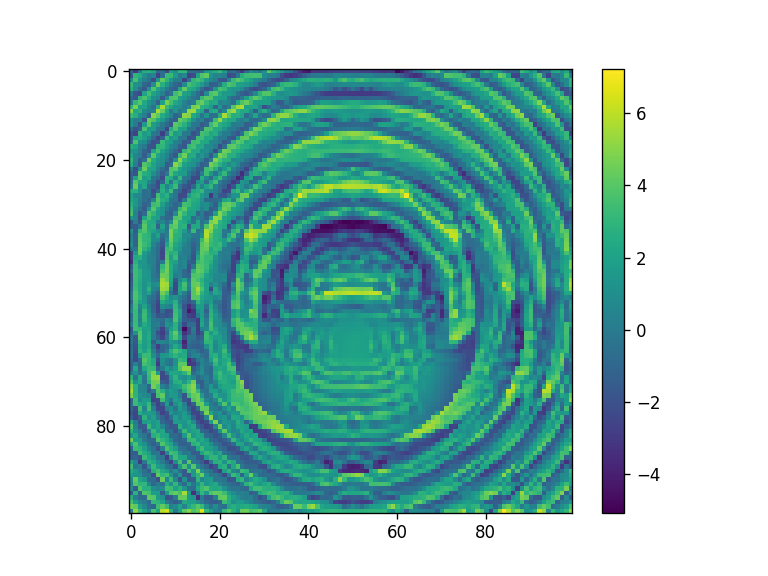

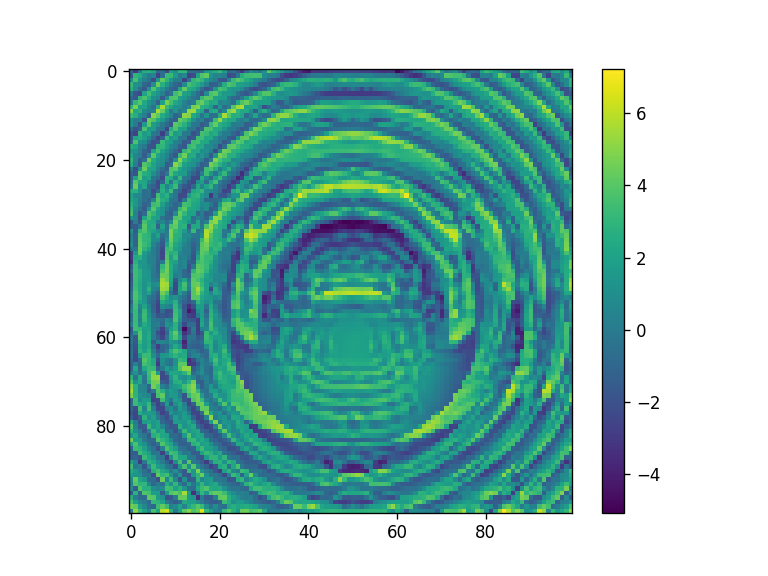

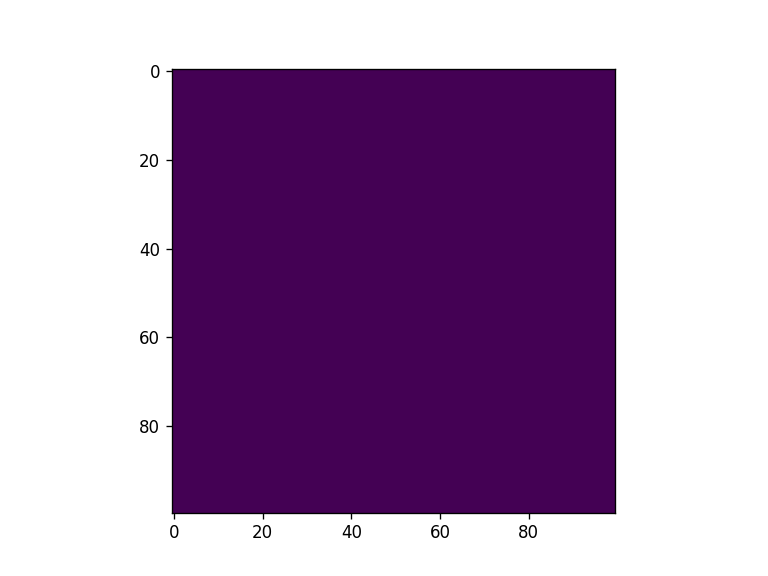

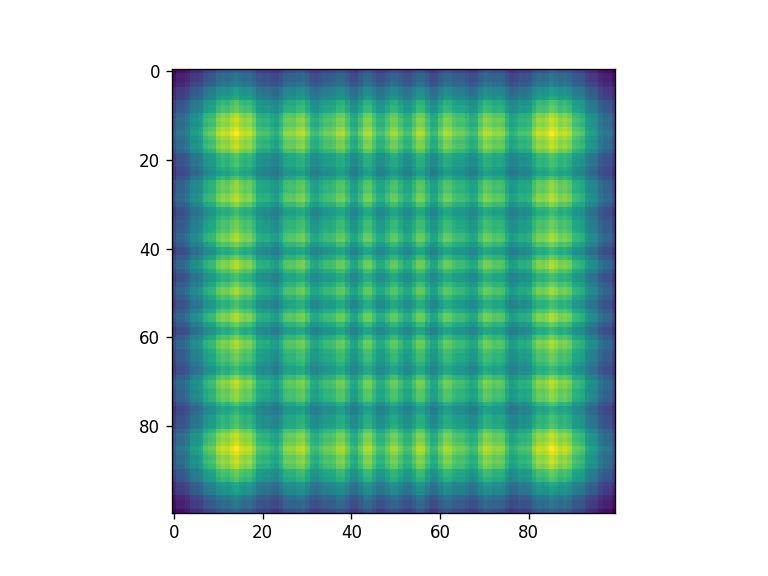

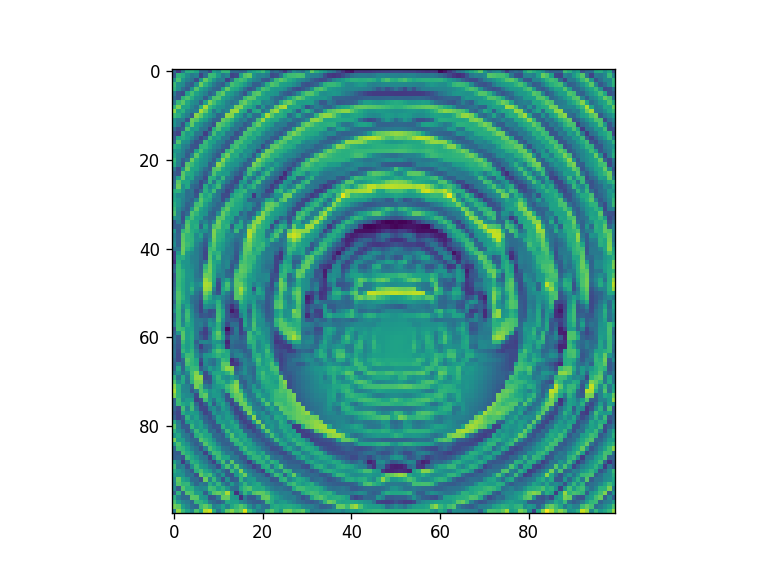

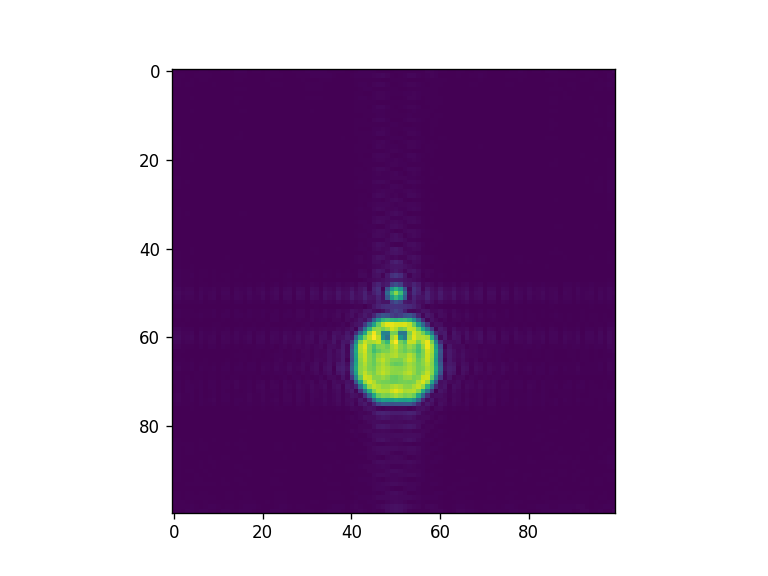

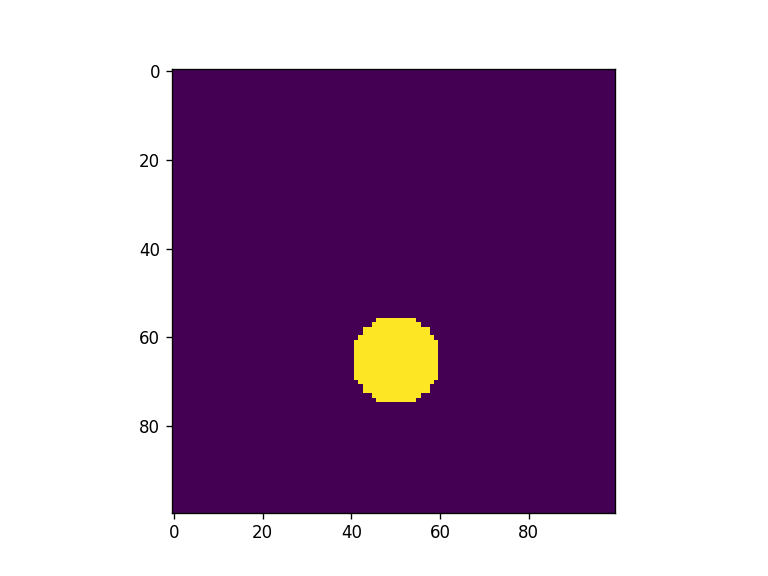

In [18]:
solution = moe.optimizer.optimize(FOM3, x0_flatten, args1=[mask2, screen, wavelength, matrix], verbose = 1, ftol=1e-5)

x = solution.x

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()

fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, mask2, screen, wavelength) ) )

fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, mask2, screen, wavelength) ) )


fig = plt.figure() 
plt.imshow(np.reshape(matrix, (x_pixel, y_pixel)) )


Elapsed: 0:00:00.012465
Elapsed: 0:00:00.028688
Elapsed: 0:00:00.021782
Elapsed: 0:00:00.029527
Elapsed: 0:00:00.012467
Elapsed: 0:00:00.037671
Elapsed: 0:00:00.012805
Elapsed: 0:00:00.038135
Elapsed: 0:00:00.011727
Elapsed: 0:00:00.027402
Elapsed: 0:00:00.012302
Elapsed: 0:00:00.001125
Elapsed: 0:00:00.015661
Elapsed: 0:00:00.031208
Elapsed: 0:00:00.016282
Elapsed: 0:00:00.031284
Elapsed: 0:00:00.015657
Elapsed: 0:00:00.016209
Elapsed: 0:00:00.011855
Elapsed: 0:00:00.033123
Elapsed: 0:00:00.015654
Elapsed: 0:00:00.015625
Elapsed: 0:00:00.046830
Elapsed: 0:00:00.015626
Elapsed: 0:00:00.043313
Elapsed: 0:00:00.011992
Elapsed: 0:00:00.016102
Elapsed: 0:00:00.015661
Elapsed: 0:00:00.031242
Elapsed: 0:00:00
Elapsed: 0:00:00.026720
Elapsed: 0:00:00.012494
Elapsed: 0:00:00.039805
Elapsed: 0:00:00
Elapsed: 0:00:00.015619
Elapsed: 0:00:00.031902
Elapsed: 0:00:00
Elapsed: 0:00:00.040711
Elapsed: 0:00:00.015656
Elapsed: 0:00:00.031245
Elapsed: 0:00:00
Elapsed: 0:00:00.016293
Elapsed: 0:00:00.031

Elapsed: 0:00:00.011947
Elapsed: 0:00:00.025692
Elapsed: 0:00:00
Elapsed: 0:00:00.031244
Elapsed: 0:00:00.010008
Elapsed: 0:00:00.031288
Elapsed: 0:00:00.012172
Elapsed: 0:00:00.015658
Elapsed: 0:00:00.015623
Elapsed: 0:00:00.044960
Elapsed: 0:00:00
Elapsed: 0:00:00.031216
Elapsed: 0:00:00.012135
Elapsed: 0:00:00.022675
Elapsed: 0:00:00
Elapsed: 0:00:00.015664
Elapsed: 0:00:00.015659
Elapsed: 0:00:00.031322
Elapsed: 0:00:00.024171
Elapsed: 0:00:00.025815
Elapsed: 0:00:00.015662
Elapsed: 0:00:00.015622
Elapsed: 0:00:00.015623
Elapsed: 0:00:00.036937
Elapsed: 0:00:00.012297
Elapsed: 0:00:00.016116
Elapsed: 0:00:00.015627
Elapsed: 0:00:00.031283
Elapsed: 0:00:00
Elapsed: 0:00:00.041342
Elapsed: 0:00:00.036684
Elapsed: 0:00:00.024719
Elapsed: 0:00:00.015620
Elapsed: 0:00:00.015622
Elapsed: 0:00:00
Elapsed: 0:00:00.015620
Elapsed: 0:00:00.015765
Elapsed: 0:00:00.028085
Elapsed: 0:00:00
Elapsed: 0:00:00.031357
Elapsed: 0:00:00.015621
Elapsed: 0:00:00.015622
Elapsed: 0:00:00.011375
Elapsed: 0

Elapsed: 0:00:00.021789
Elapsed: 0:00:00.029053
Elapsed: 0:00:00
Elapsed: 0:00:00.015584
Elapsed: 0:00:00.015812
Elapsed: 0:00:00.025636
Elapsed: 0:00:00.020519
Elapsed: 0:00:00.019118
Elapsed: 0:00:00.002161
Elapsed: 0:00:00.031281
Elapsed: 0:00:00.015664
Elapsed: 0:00:00.031240
Elapsed: 0:00:00.012092
Elapsed: 0:00:00.024133
Elapsed: 0:00:00
Elapsed: 0:00:00.015622
Elapsed: 0:00:00.015663
Elapsed: 0:00:00.031242
Elapsed: 0:00:00.033966
Elapsed: 0:00:00.041600
Elapsed: 0:00:00.015621
Elapsed: 0:00:00.026235
Elapsed: 0:00:00
Elapsed: 0:00:00.015657
Elapsed: 0:00:00.037273
Elapsed: 0:00:00.028197
Elapsed: 0:00:00.001128
Elapsed: 0:00:00.031281
Elapsed: 0:00:00
Elapsed: 0:00:00.025696
Elapsed: 0:00:00.038305
Elapsed: 0:00:00.027718
Elapsed: 0:00:00.015659
Elapsed: 0:00:00.031208
Elapsed: 0:00:00.010013
Elapsed: 0:00:00.035695
Elapsed: 0:00:00.017262
Elapsed: 0:00:00.031284
Elapsed: 0:00:00
Elapsed: 0:00:00.031308
Elapsed: 0:00:00.015620
Elapsed: 0:00:00.031246
Elapsed: 0:00:00.012586
Ela

Elapsed: 0:00:00.021276
Elapsed: 0:00:00.031281
Elapsed: 0:00:00.010041
Elapsed: 0:00:00.015627
Elapsed: 0:00:00.015620
Elapsed: 0:00:00.031252
Elapsed: 0:00:00
Elapsed: 0:00:00.032216
Elapsed: 0:00:00.008005
Elapsed: 0:00:00.035371
Elapsed: 0:00:00.015587
Elapsed: 0:00:00.031356
Elapsed: 0:00:00.015624
Elapsed: 0:00:00.052038
Elapsed: 0:00:00
Elapsed: 0:00:00.015618
Elapsed: 0:00:00.031286
Elapsed: 0:00:00.031242
Elapsed: 0:00:00.013478
Elapsed: 0:00:00.027191
Elapsed: 0:00:00.015620
Elapsed: 0:00:00.047472
Elapsed: 0:00:00.015586
Elapsed: 0:00:00.031244
Elapsed: 0:00:00.011948
Elapsed: 0:00:00.015657
Elapsed: 0:00:00.015711
Elapsed: 0:00:00.025704
Elapsed: 0:00:00
Elapsed: 0:00:00.015623
Elapsed: 0:00:00.015661
Elapsed: 0:00:00.030827
Elapsed: 0:00:00.015774
Elapsed: 0:00:00.025671
Elapsed: 0:00:00
Elapsed: 0:00:00.028399
Elapsed: 0:00:00.015624
Elapsed: 0:00:00.031245
Elapsed: 0:00:00.010952
Elapsed: 0:00:00.015659
Elapsed: 0:00:00.015667
Elapsed: 0:00:00.041335
Elapsed: 0:00:00.015

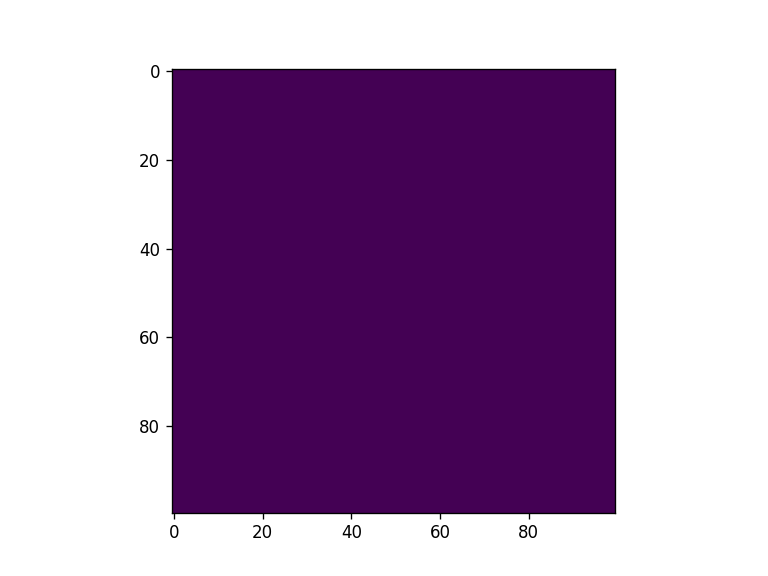

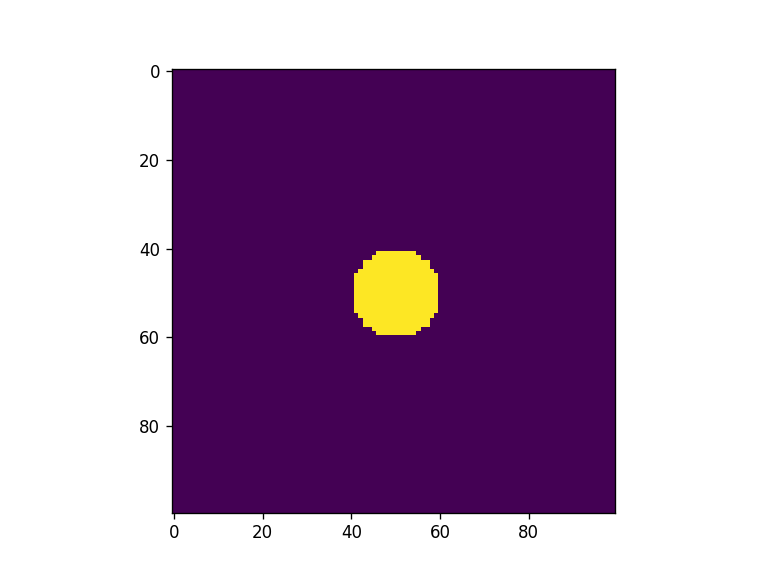

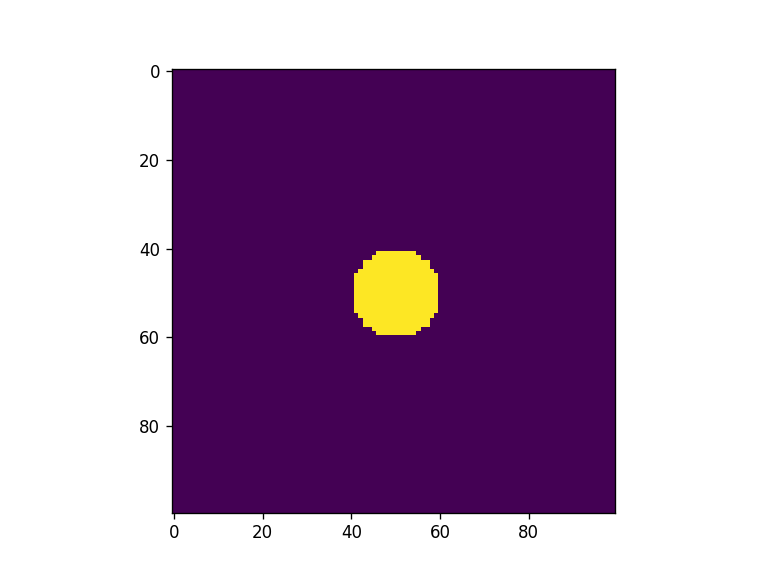

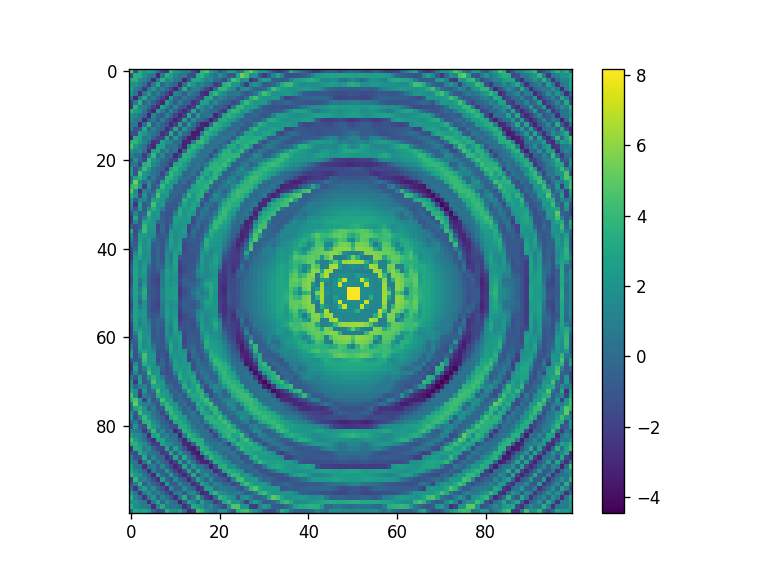

In [19]:
#Initial guess
x_pixel, y_pixel = 100, 100


x0 = np.random.rand(x_pixel, y_pixel)
x0 = np.ones((x_pixel,y_pixel))
x0_flatten = x0.flatten()


xi = np.arange(x_pixel)
yi = np.arange(y_pixel)
XX, YY = np.meshgrid(xi,yi)
    
matrix = np.zeros((x_pixel, y_pixel))
matrix[np.where(((XX-x_pixel/2)**2 + (YY-y_pixel/2)**2) < 10**2)] = 1 

matrix_flat = matrix.flatten()

fig = plt.figure() 
plt.imshow(x0)


fig = plt.figure() 
plt.imshow(matrix)

fig = plt.figure() 
plt.imshow(np.reshape(matrix_flat, (x_pixel, y_pixel)))


solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=(mask2, screen, wavelength, matrix), verbose=1, ftol=1e-4)

x = solution.x

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()

Elapsed: 0:00:00.013716
Elapsed: 0:00:00.013230


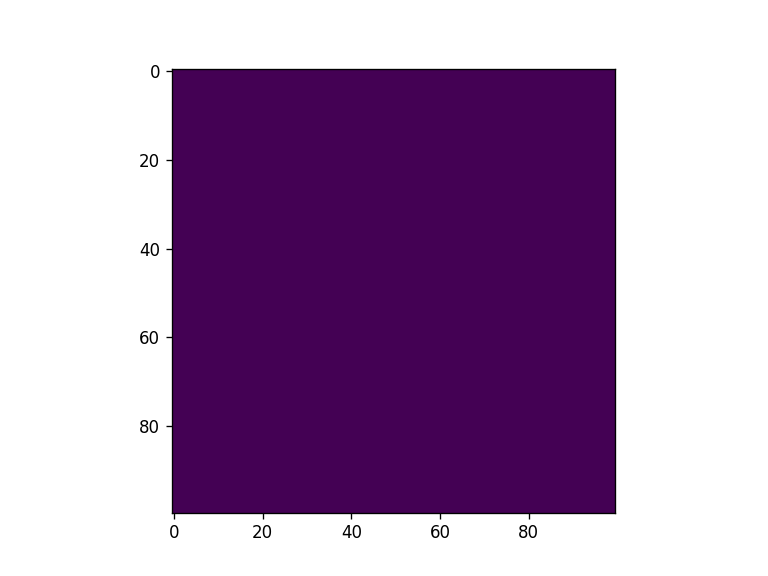

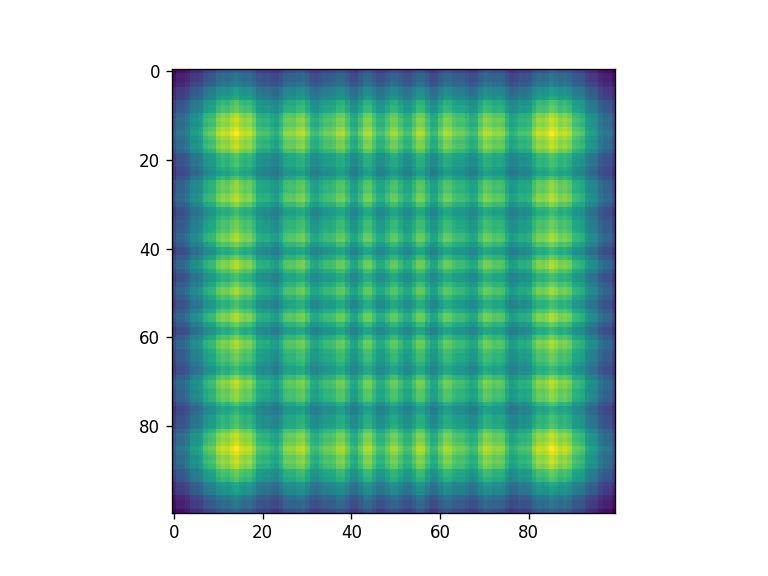

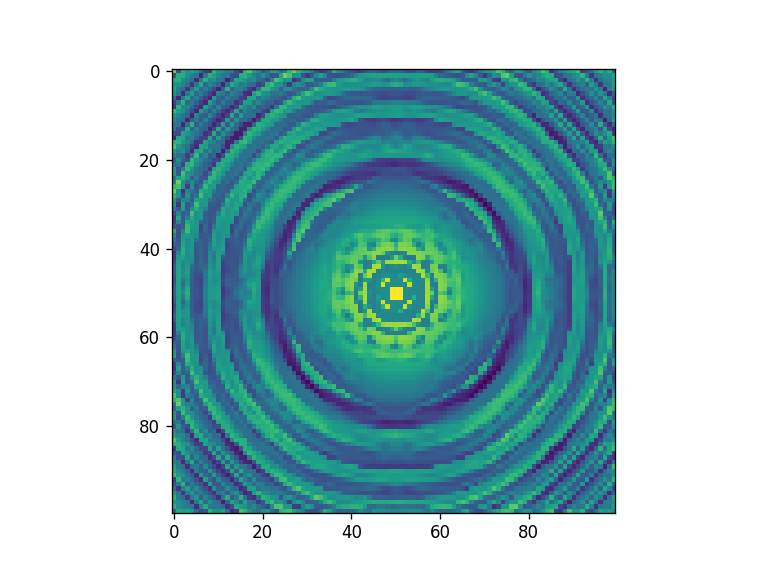

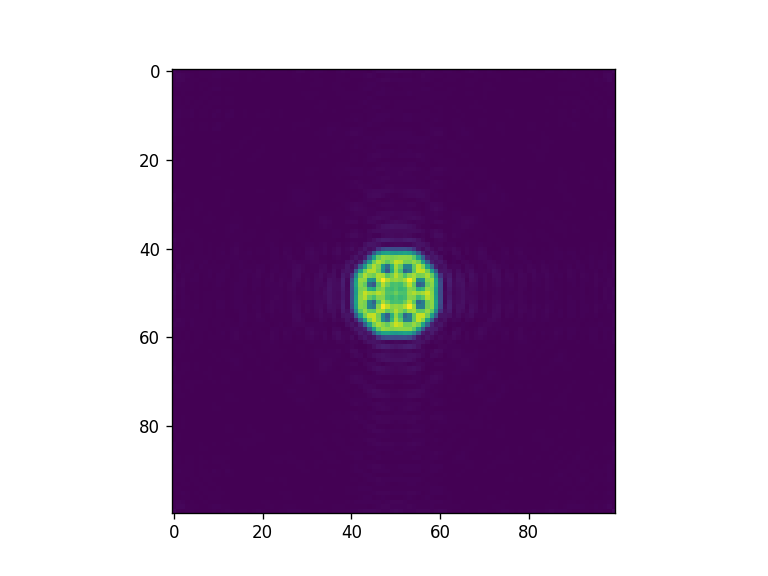

In [20]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, mask2, screen, wavelength) ) )

fig = plt.figure() 
xar2 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar, mask2, screen, wavelength) ) )


Elapsed: 0:00:00.012943
Elapsed: 0:00:00.045915
Elapsed: 0:00:00.012397
Elapsed: 0:00:00.028275
Elapsed: 0:00:00.011317
Elapsed: 0:00:00.031488
Elapsed: 0:00:00.012038
Elapsed: 0:00:00.028229
Elapsed: 0:00:00.012177
Elapsed: 0:00:00.028346
Elapsed: 0:00:00.012331
Elapsed: 0:00:00.012040
Elapsed: 0:00:00.028723
Elapsed: 0:00:00.015624
Elapsed: 0:00:00.021622
Elapsed: 0:00:00.015627
Elapsed: 0:00:00
Elapsed: 0:00:00
Elapsed: 0:00:00.045269
Elapsed: 0:00:00
Elapsed: 0:00:00.015661
Elapsed: 0:00:00.010007
Elapsed: 0:00:00.031288
Elapsed: 0:00:00
Elapsed: 0:00:00.047115
Elapsed: 0:00:00.012044
Elapsed: 0:00:00.026047
Elapsed: 0:00:00.012193
Elapsed: 0:00:00.001074
Elapsed: 0:00:00.031285
Elapsed: 0:00:00.027008
Elapsed: 0:00:00.032895
Elapsed: 0:00:00.012332
Elapsed: 0:00:00.014126
Elapsed: 0:00:00.010041
Elapsed: 0:00:00.031863
Elapsed: 0:00:00.011976
Elapsed: 0:00:00.024174
Elapsed: 0:00:00.016990
Elapsed: 0:00:00.022036
Elapsed: 0:00:00.015586
Elapsed: 0:00:00.045919
Elapsed: 0:00:00
Ela

Elapsed: 0:00:00.033501
Elapsed: 0:00:00.015623
Elapsed: 0:00:00.031245
Elapsed: 0:00:00
Elapsed: 0:00:00.015623
Elapsed: 0:00:00.015585
Elapsed: 0:00:00.054556
Elapsed: 0:00:00.015657
Elapsed: 0:00:00.031865
Elapsed: 0:00:00.015621
Elapsed: 0:00:00.031245
Elapsed: 0:00:00.016157
Elapsed: 0:00:00.044574
Elapsed: 0:00:00
Elapsed: 0:00:00.015661
Elapsed: 0:00:00.015624
Elapsed: 0:00:00
Elapsed: 0:00:00.016271
Elapsed: 0:00:00.025171
Elapsed: 0:00:00.032380
Elapsed: 0:00:00.008238
Elapsed: 0:00:00.031281
Elapsed: 0:00:00.016186
Elapsed: 0:00:00.031281
Elapsed: 0:00:00.014268
Elapsed: 0:00:00.027760
Elapsed: 0:00:00.015624
Elapsed: 0:00:00.031248
Elapsed: 0:00:00.015627
Elapsed: 0:00:00.063399
Elapsed: 0:00:00.006000
Elapsed: 0:00:00.031278
Elapsed: 0:00:00
Elapsed: 0:00:00.016237
Elapsed: 0:00:00.039124
Elapsed: 0:00:00.015661
Elapsed: 0:00:00.054597
Elapsed: 0:00:00.015622
Elapsed: 0:00:00.031210
Elapsed: 0:00:00
Elapsed: 0:00:00
Elapsed: 0:00:00.015588
Elapsed: 0:00:00.020296
Elapsed: 0

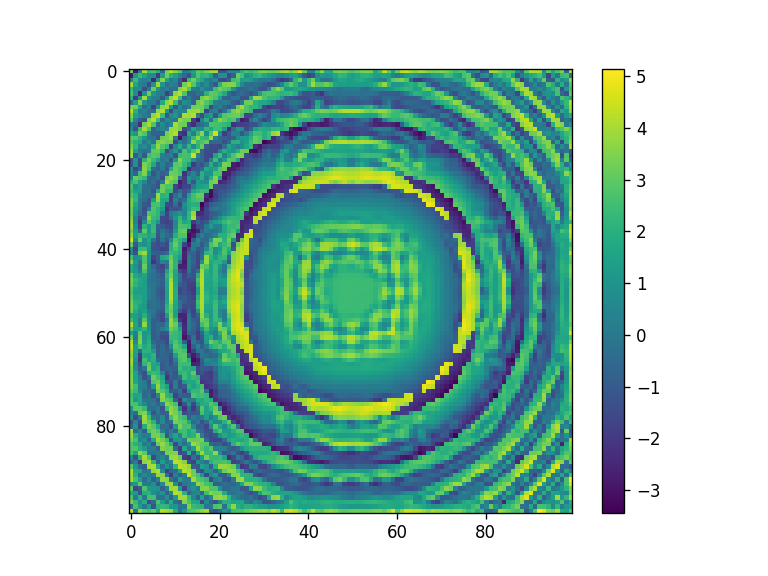

In [21]:
solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=(mask2, screen, wavelength,matrix), optimizer_method="dogbox", verbose=0, ftol=1e-4)

x = solution.x

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()




Elapsed: 0:00:00.025614
Elapsed: 0:00:00.012426


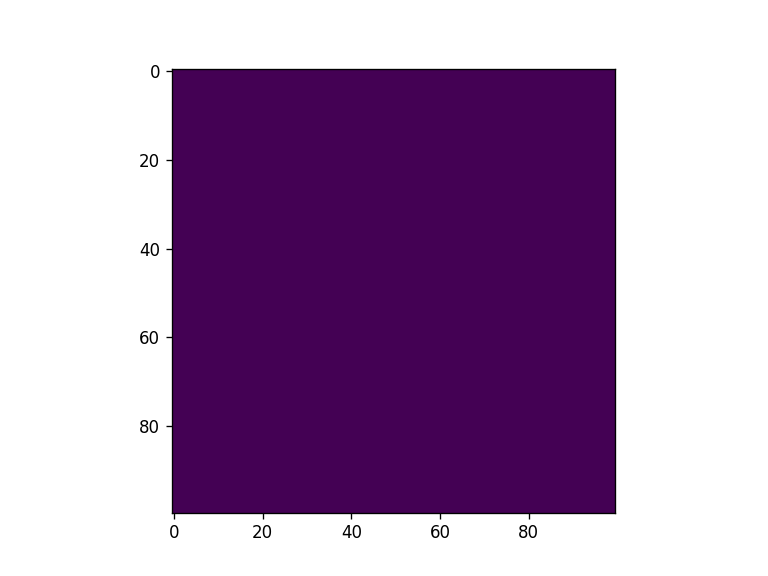

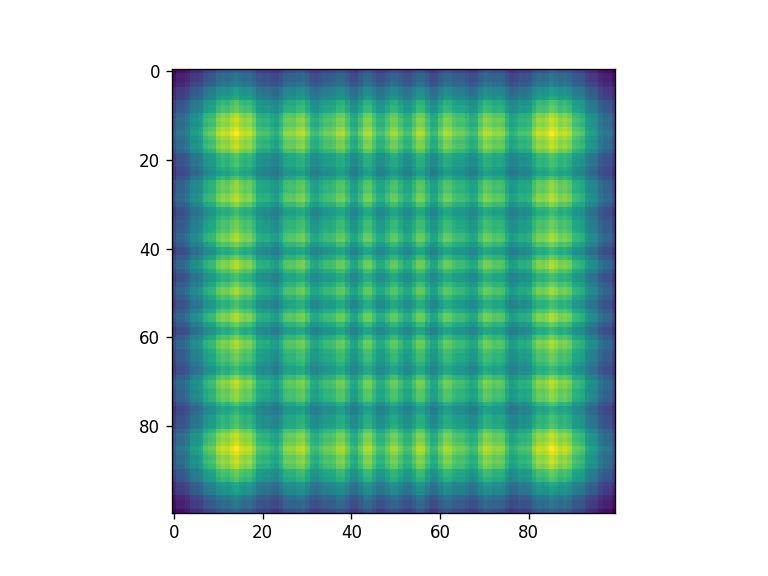

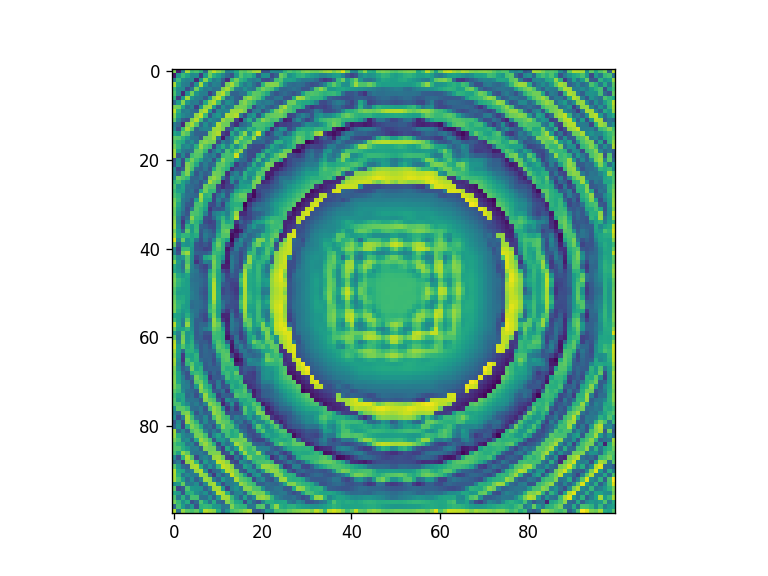

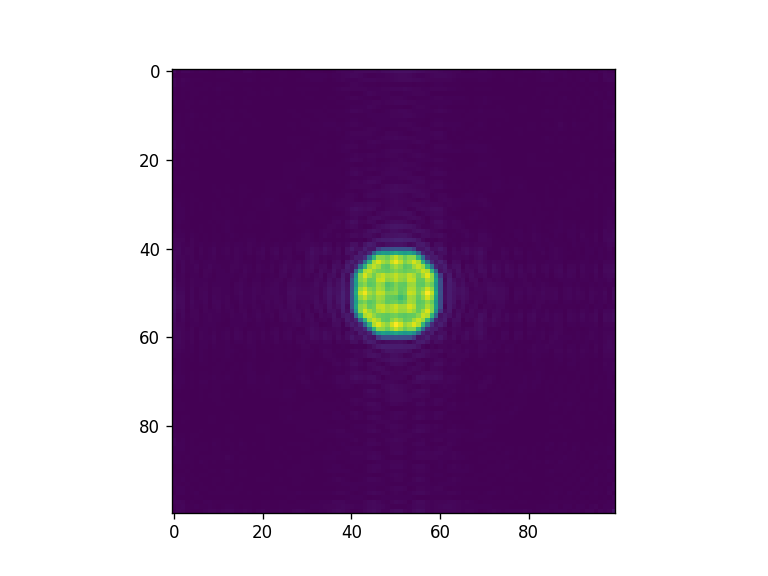

In [22]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, mask2, screen, wavelength) ) )

fig = plt.figure() 
xar2 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar, mask2, screen, wavelength) ) )


Elapsed: 0:00:00.013138
Elapsed: 0:00:00.028898
Elapsed: 0:00:00.011586
Elapsed: 0:00:00.162558
Elapsed: 0:00:00.021514
Elapsed: 0:00:00.028456
Elapsed: 0:00:00.012250
Elapsed: 0:00:00.027616
Elapsed: 0:00:00.019078
Elapsed: 0:00:00.026773
Elapsed: 0:00:00
Elapsed: 0:00:00.015622
Elapsed: 0:00:00.023929
Elapsed: 0:00:00.013085
`ftol` termination condition is satisfied.
Function evaluations 7, initial cost 3.9044e+01, final cost 1.3392e+01, first-order optimality 1.53e-03.


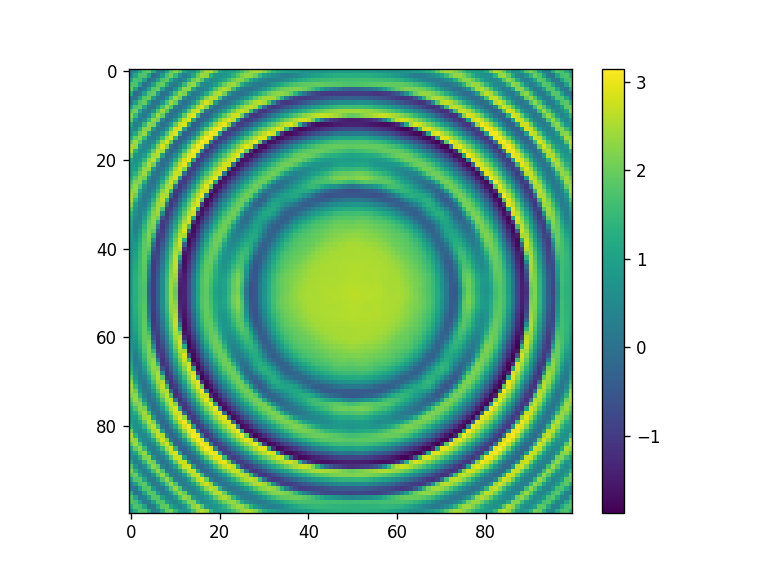

In [23]:
solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=(mask2, screen, wavelength, matrix), optimizer_method="dogbox", bounds =(-np.pi, np.pi), ftol = 1e-4 )

x = solution.x

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()




Elapsed: 0:00:00.025410
Elapsed: 0:00:00.013682


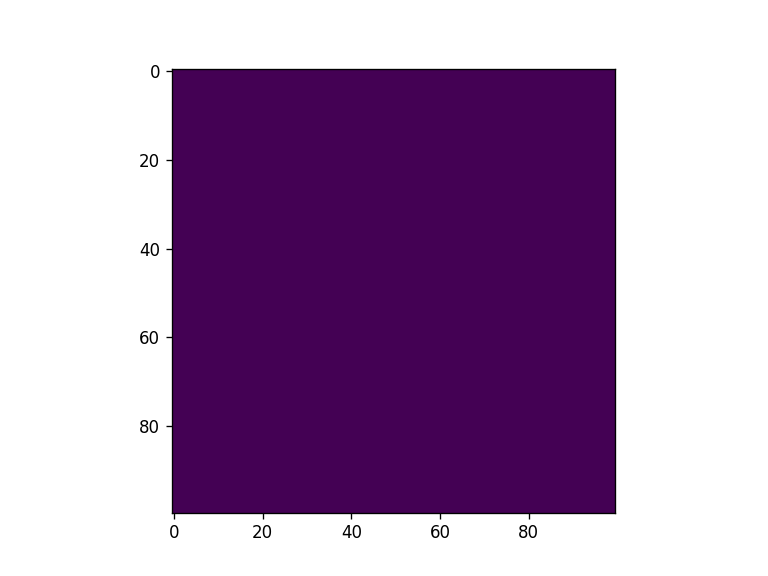

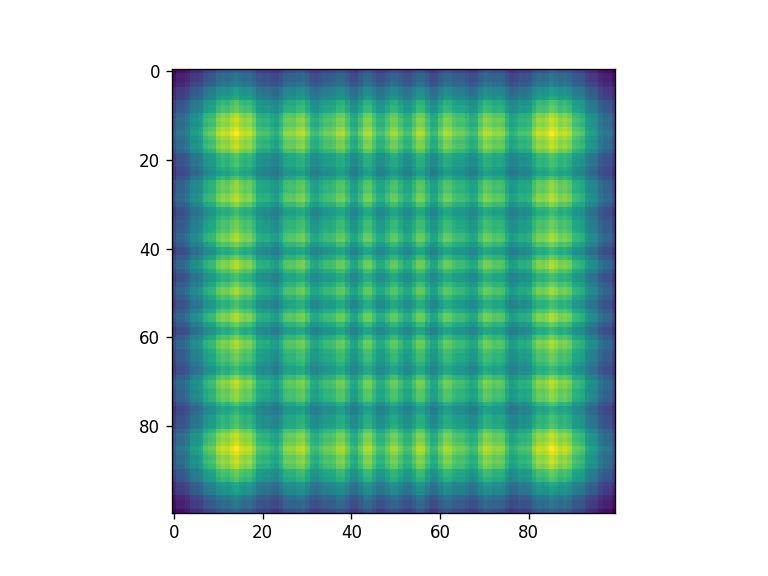

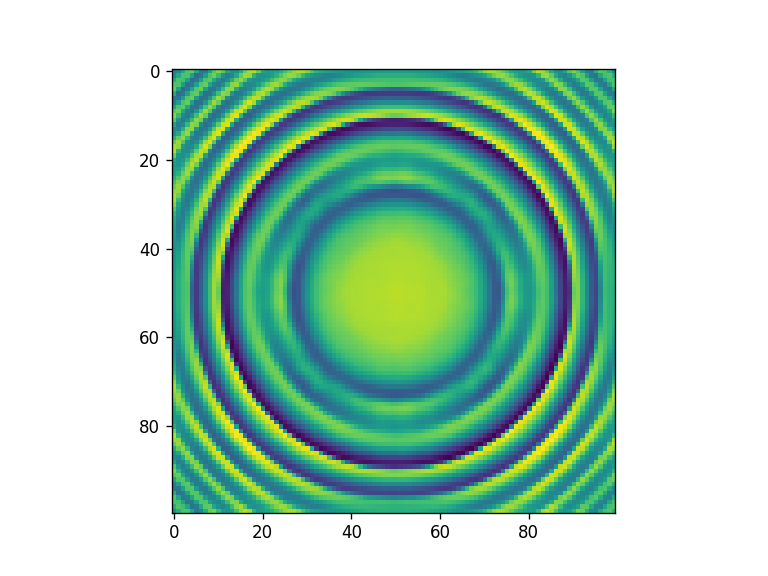

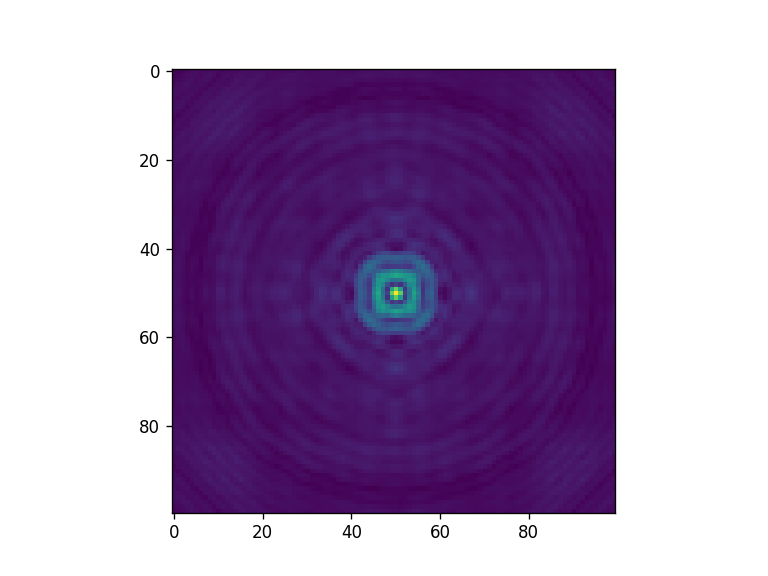

In [24]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, mask2, screen, wavelength) ) )

fig = plt.figure() 
xar2 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar, mask2, screen, wavelength) ) )


Elapsed: 0:00:00.013032
Elapsed: 0:00:00.028712
Elapsed: 0:00:00.011388
Elapsed: 0:00:00.027525
Elapsed: 0:00:00.012217
Elapsed: 0:00:00.041483
Elapsed: 0:00:00.014321
Elapsed: 0:00:00.028605
Elapsed: 0:00:00.011244
Elapsed: 0:00:00.044858
Elapsed: 0:00:00.011948
Elapsed: 0:00:00.010987
Elapsed: 0:00:00
Elapsed: 0:00:00.025742
Elapsed: 0:00:00.015624
Elapsed: 0:00:00.031243
Elapsed: 0:00:00.015810
Elapsed: 0:00:00.015628
Elapsed: 0:00:00.011947
Elapsed: 0:00:00.028894
Elapsed: 0:00:00.015658
Elapsed: 0:00:00.015586
Elapsed: 0:00:00.038266
Elapsed: 0:00:00.015622
Elapsed: 0:00:00.039881
Elapsed: 0:00:00.012116
Elapsed: 0:00:00.015659
Elapsed: 0:00:00.012243
Elapsed: 0:00:00.039759
Elapsed: 0:00:00.015620
Elapsed: 0:00:00.055788
Elapsed: 0:00:00
Elapsed: 0:00:00.042192
Elapsed: 0:00:00.015623
Elapsed: 0:00:00.017863
Elapsed: 0:00:00.026978
Elapsed: 0:00:00.014447
Elapsed: 0:00:00.031762
Elapsed: 0:00:00.031247
Elapsed: 0:00:00.031245
Elapsed: 0:00:00.015627
Elapsed: 0:00:00
Elapsed: 0:00

Elapsed: 0:00:00.015729
Elapsed: 0:00:00.028107
Elapsed: 0:00:00.013043
Elapsed: 0:00:00.028085
Elapsed: 0:00:00.011947
Elapsed: 0:00:00.038732
Elapsed: 0:00:00.012035
Elapsed: 0:00:00.027605
Elapsed: 0:00:00.013062
Elapsed: 0:00:00.038196
Elapsed: 0:00:00.013037
Elapsed: 0:00:00.037834
Elapsed: 0:00:00.012040
Elapsed: 0:00:00.028089
Elapsed: 0:00:00.011183
Elapsed: 0:00:00.028984
Elapsed: 0:00:00.012233
Elapsed: 0:00:00.042670
Elapsed: 0:00:00.011949
Elapsed: 0:00:00.042162
Elapsed: 0:00:00.011202
Elapsed: 0:00:00.028378
Elapsed: 0:00:00.009545
Elapsed: 0:00:00.027004
Elapsed: 0:00:00.024110
Elapsed: 0:00:00.038112
Elapsed: 0:00:00.012042
Elapsed: 0:00:00.028029
Elapsed: 0:00:00.011295
Elapsed: 0:00:00.018146
Elapsed: 0:00:00.015622
Elapsed: 0:00:00.035982
Elapsed: 0:00:00.010041
Elapsed: 0:00:00.031282
Elapsed: 0:00:00.015623
Elapsed: 0:00:00.031366
Elapsed: 0:00:00.011382
Elapsed: 0:00:00.043998
Elapsed: 0:00:00.012082
Elapsed: 0:00:00.028119
Elapsed: 0:00:00.011041
Elapsed: 0:00:00

Elapsed: 0:00:00.011860
Elapsed: 0:00:00.024110
Elapsed: 0:00:00
Elapsed: 0:00:00.015660
Elapsed: 0:00:00.015592
Elapsed: 0:00:00.031916
Elapsed: 0:00:00.012032
Elapsed: 0:00:00.029690
Elapsed: 0:00:00.015627
Elapsed: 0:00:00.031278
Elapsed: 0:00:00
Elapsed: 0:00:00.016233
Elapsed: 0:00:00.017708
Elapsed: 0:00:00.036568
Elapsed: 0:00:00.015627
Elapsed: 0:00:00.031244
Elapsed: 0:00:00
Elapsed: 0:00:00.016247
Elapsed: 0:00:00.012337
Elapsed: 0:00:00.026674
Elapsed: 0:00:00.015655
Elapsed: 0:00:00.031249
Elapsed: 0:00:00.015664
Elapsed: 0:00:00.015620
Elapsed: 0:00:00.030594
Elapsed: 0:00:00.029202
Elapsed: 0:00:00.015656
Elapsed: 0:00:00.031244
Elapsed: 0:00:00.015661
Elapsed: 0:00:00.031211
Elapsed: 0:00:00
Elapsed: 0:00:00.057932
Elapsed: 0:00:00.015623
Elapsed: 0:00:00.031932
Elapsed: 0:00:00
Elapsed: 0:00:00.031244
Elapsed: 0:00:00
Elapsed: 0:00:00.059777
Elapsed: 0:00:00.016232
Elapsed: 0:00:00.046904
Elapsed: 0:00:00
Elapsed: 0:00:00.016258
Elapsed: 0:00:00
Elapsed: 0:00:00.028630


Elapsed: 0:00:00.014496
Elapsed: 0:00:00.023179
Elapsed: 0:00:00
Elapsed: 0:00:00.015623
Elapsed: 0:00:00
Elapsed: 0:00:00.015625
Elapsed: 0:00:00.015624
Elapsed: 0:00:00.027865
Elapsed: 0:00:00.016253
Elapsed: 0:00:00.031249
Elapsed: 0:00:00
Elapsed: 0:00:00.016153
Elapsed: 0:00:00
Elapsed: 0:00:00.016231
Elapsed: 0:00:00
Elapsed: 0:00:00.015622
Elapsed: 0:00:00.015628
Elapsed: 0:00:00.031244
Elapsed: 0:00:00.025970
Elapsed: 0:00:00.019732
Elapsed: 0:00:00.015621
Elapsed: 0:00:00.047995
Elapsed: 0:00:00
Elapsed: 0:00:00.015622
Elapsed: 0:00:00.011946
Elapsed: 0:00:00.015624
Elapsed: 0:00:00.031244
Elapsed: 0:00:00.031245
Elapsed: 0:00:00
Elapsed: 0:00:00.044619
Elapsed: 0:00:00.006014
Elapsed: 0:00:00.015627
Elapsed: 0:00:00.015622
Elapsed: 0:00:00.031331
Elapsed: 0:00:00.015661
Elapsed: 0:00:00.031241
Elapsed: 0:00:00.012118
Elapsed: 0:00:00.015658
Elapsed: 0:00:00
Elapsed: 0:00:00.041293
Elapsed: 0:00:00.015285
Elapsed: 0:00:00.028173
Elapsed: 0:00:00.031281
Elapsed: 0:00:00.031355


Elapsed: 0:00:00.006078
Elapsed: 0:00:00.031280
Elapsed: 0:00:00
Elapsed: 0:00:00.025743
Elapsed: 0:00:00.015623
Elapsed: 0:00:00.032453
Elapsed: 0:00:00
Elapsed: 0:00:00.027396
Elapsed: 0:00:00.015732
Elapsed: 0:00:00.025670
Elapsed: 0:00:00
Elapsed: 0:00:00.031292
Elapsed: 0:00:00.015661
Elapsed: 0:00:00.030391
Elapsed: 0:00:00.010042
Elapsed: 0:00:00.015668
Elapsed: 0:00:00.015657
Elapsed: 0:00:00.031312
Elapsed: 0:00:00
Elapsed: 0:00:00.043863
Elapsed: 0:00:00.015658
Elapsed: 0:00:00.046867
Elapsed: 0:00:00.015657
Elapsed: 0:00:00.031247
Elapsed: 0:00:00.034261
Elapsed: 0:00:00.023179
Elapsed: 0:00:00
Elapsed: 0:00:00.041426
Elapsed: 0:00:00
Elapsed: 0:00:00.015622
Elapsed: 0:00:00.012908
Elapsed: 0:00:00.010038
Elapsed: 0:00:00.015694
Elapsed: 0:00:00.015663
Elapsed: 0:00:00
Elapsed: 0:00:00.015656
Elapsed: 0:00:00.015663
Elapsed: 0:00:00.051380
Elapsed: 0:00:00.015740
Elapsed: 0:00:00.015627
Elapsed: 0:00:00.016946
Elapsed: 0:00:00.019737
Elapsed: 0:00:00
Elapsed: 0:00:00.015589


...

Elapsed: 0:00:00.012326
Elapsed: 0:00:00.024079
Elapsed: 0:00:00.015763
Elapsed: 0:00:00.015660
Elapsed: 0:00:00.015621
Elapsed: 0:00:00.025670
Elapsed: 0:00:00.011947
Elapsed: 0:00:00.022791
Elapsed: 0:00:00
Elapsed: 0:00:00.015624
Elapsed: 0:00:00.015664
Elapsed: 0:00:00.025706
Elapsed: 0:00:00.031245
Elapsed: 0:00:00.029724
Elapsed: 0:00:00.015625
Elapsed: 0:00:00.031208
Elapsed: 0:00:00.015626
Elapsed: 0:00:00.031283
Elapsed: 0:00:00.011949
Elapsed: 0:00:00.015656
Elapsed: 0:00:00.031334
Elapsed: 0:00:00.025669
Elapsed: 0:00:00
Elapsed: 0:00:00.015621
Elapsed: 0:00:00.035134
Elapsed: 0:00:00.029117
Elapsed: 0:00:00
Elapsed: 0:00:00.031282
Elapsed: 0:00:00
Elapsed: 0:00:00.025746
Elapsed: 0:00:00.027340
Elapsed: 0:00:00.027894
Elapsed: 0:00:00.012143
Elapsed: 0:00:00.021788
Elapsed: 0:00:00.011950
Elapsed: 0:00:00.029076
Elapsed: 0:00:00.016321
Elapsed: 0:00:00.018642
Elapsed: 0:00:00.015620
Elapsed: 0:00:00.031286
Elapsed: 0:00:00.012371
Elapsed: 0:00:00.028943
Elapsed: 0:00:00.021

Elapsed: 0:00:00.015221
Elapsed: 0:00:00.028028
Elapsed: 0:00:00.011085
Elapsed: 0:00:00.027003
Elapsed: 0:00:00
Elapsed: 0:00:00.042521
Elapsed: 0:00:00.011533
Elapsed: 0:00:00.028042
Elapsed: 0:00:00.011911
Elapsed: 0:00:00.024678
Elapsed: 0:00:00.012053
Elapsed: 0:00:00.016726
Elapsed: 0:00:00.014242
Elapsed: 0:00:00.031801
Elapsed: 0:00:00.011035
Elapsed: 0:00:00.040297
Elapsed: 0:00:00.011948
Elapsed: 0:00:00.027951
Elapsed: 0:00:00.001099
Elapsed: 0:00:00.031281
Elapsed: 0:00:00.011906
Elapsed: 0:00:00.027753
Elapsed: 0:00:00.012060
Elapsed: 0:00:00.021878
Elapsed: 0:00:00.011425
Elapsed: 0:00:00.028589
Elapsed: 0:00:00.011948
Elapsed: 0:00:00.026882
Elapsed: 0:00:00.012042
Elapsed: 0:00:00.028087
Elapsed: 0:00:00.011148
Elapsed: 0:00:00.027004
Elapsed: 0:00:00.015622
Elapsed: 0:00:00.035131
Elapsed: 0:00:00.015623
Elapsed: 0:00:00.031279
Elapsed: 0:00:00.011948
Elapsed: 0:00:00.015659
Elapsed: 0:00:00.015619
Elapsed: 0:00:00.041356
Elapsed: 0:00:00.015615
Elapsed: 0:00:00.025775

Elapsed: 0:00:00.012431
Elapsed: 0:00:00.026185
Elapsed: 0:00:00.015659
Elapsed: 0:00:00.031898
Elapsed: 0:00:00
Elapsed: 0:00:00.030063
Elapsed: 0:00:00.013164
Elapsed: 0:00:00.011017
Elapsed: 0:00:00.015623
Elapsed: 0:00:00.031243
Elapsed: 0:00:00
Elapsed: 0:00:00.015657
Elapsed: 0:00:00.015135
Elapsed: 0:00:00.033826
Elapsed: 0:00:00.015620
Elapsed: 0:00:00.031883
Elapsed: 0:00:00.015616
Elapsed: 0:00:00.031244
Elapsed: 0:00:00.012280
Elapsed: 0:00:00.022158
Elapsed: 0:00:00
Elapsed: 0:00:00.031791
Elapsed: 0:00:00.015619
Elapsed: 0:00:00.015620
Elapsed: 0:00:00.014110
Elapsed: 0:00:00.015951
Elapsed: 0:00:00.015626
Elapsed: 0:00:00.015657
Elapsed: 0:00:00.015656
Elapsed: 0:00:00.031848
Elapsed: 0:00:00.015629
Elapsed: 0:00:00.032503
Elapsed: 0:00:00.012078
Elapsed: 0:00:00.025646
Elapsed: 0:00:00.011467
Elapsed: 0:00:00.021172
Elapsed: 0:00:00
Elapsed: 0:00:00.044945
Elapsed: 0:00:00.003014
Elapsed: 0:00:00.015657
Elapsed: 0:00:00.031828
Elapsed: 0:00:00.015623
Elapsed: 0:00:00.029

Elapsed: 0:00:00.038811
Elapsed: 0:00:00.012304
Elapsed: 0:00:00.027984
Elapsed: 0:00:00.015594
Elapsed: 0:00:00.031442
Elapsed: 0:00:00.015620
Elapsed: 0:00:00.041228
Elapsed: 0:00:00.011949
Elapsed: 0:00:00.015623
Elapsed: 0:00:00.016265
Elapsed: 0:00:00.048254
Elapsed: 0:00:00.022416
Elapsed: 0:00:00.028931
Elapsed: 0:00:00.012178
Elapsed: 0:00:00.031827
Elapsed: 0:00:00.015588
Elapsed: 0:00:00.048402
Elapsed: 0:00:00.011379
Elapsed: 0:00:00.029095
Elapsed: 0:00:00.015618
Elapsed: 0:00:00.015624
Elapsed: 0:00:00.031497
Elapsed: 0:00:00.029809
Elapsed: 0:00:00.001129
Elapsed: 0:00:00.015589
Elapsed: 0:00:00.015626
Elapsed: 0:00:00.032400
Elapsed: 0:00:00.016546
Elapsed: 0:00:00.011047
Elapsed: 0:00:00.017239
Elapsed: 0:00:00.031286
Elapsed: 0:00:00
Elapsed: 0:00:00.031245
Elapsed: 0:00:00
Elapsed: 0:00:00.036109
Elapsed: 0:00:00.005507
Elapsed: 0:00:00.031287
Elapsed: 0:00:00.027039
Elapsed: 0:00:00.032713
Elapsed: 0:00:00.011992
Elapsed: 0:00:00.027091
Elapsed: 0:00:00.015625
Elapse

Elapsed: 0:00:00.016111
Elapsed: 0:00:00.022231
Elapsed: 0:00:00
Elapsed: 0:00:00.031246
Elapsed: 0:00:00.015663
Elapsed: 0:00:00.031242
Elapsed: 0:00:00.028896
Elapsed: 0:00:00.026339
Elapsed: 0:00:00
Elapsed: 0:00:00.025772
Elapsed: 0:00:00.015631
Elapsed: 0:00:00.031236
Elapsed: 0:00:00.038046
Elapsed: 0:00:00.016287
Elapsed: 0:00:00.032374
Elapsed: 0:00:00.010008
Elapsed: 0:00:00.031286
Elapsed: 0:00:00
Elapsed: 0:00:00.025778
Elapsed: 0:00:00.012059
Elapsed: 0:00:00.046340
Elapsed: 0:00:00.024445
Elapsed: 0:00:00.028337
Elapsed: 0:00:00.012789
Elapsed: 0:00:00.026942
Elapsed: 0:00:00.011187
Elapsed: 0:00:00.029615
Elapsed: 0:00:00.010008
Elapsed: 0:00:00.015626
Elapsed: 0:00:00.015117
Elapsed: 0:00:00.018300
Elapsed: 0:00:00
Elapsed: 0:00:00.015620
Elapsed: 0:00:00.015663
Elapsed: 0:00:00.031244
Elapsed: 0:00:00
Elapsed: 0:00:00.039991
Elapsed: 0:00:00.012064
Elapsed: 0:00:00.018141
Elapsed: 0:00:00
Elapsed: 0:00:00.015621
Elapsed: 0:00:00.010007
Elapsed: 0:00:00.054544
Elapsed: 0

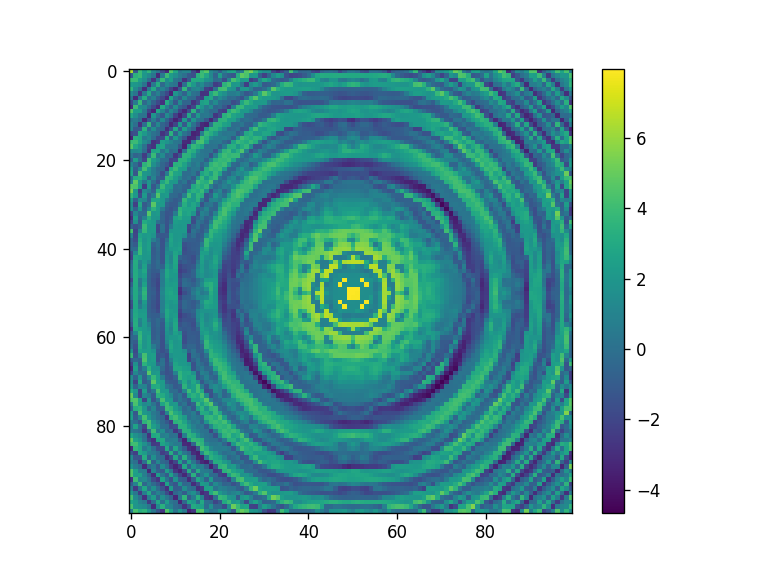

In [25]:
solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=(mask2, screen, wavelength, matrix), ftol=1e-6)

x = solution.x

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()




Elapsed: 0:00:00.012999
Elapsed: 0:00:00.013140


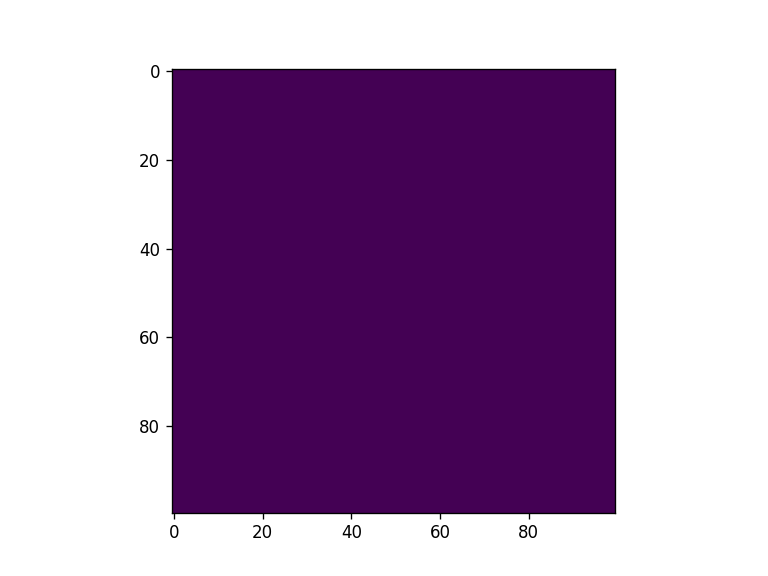

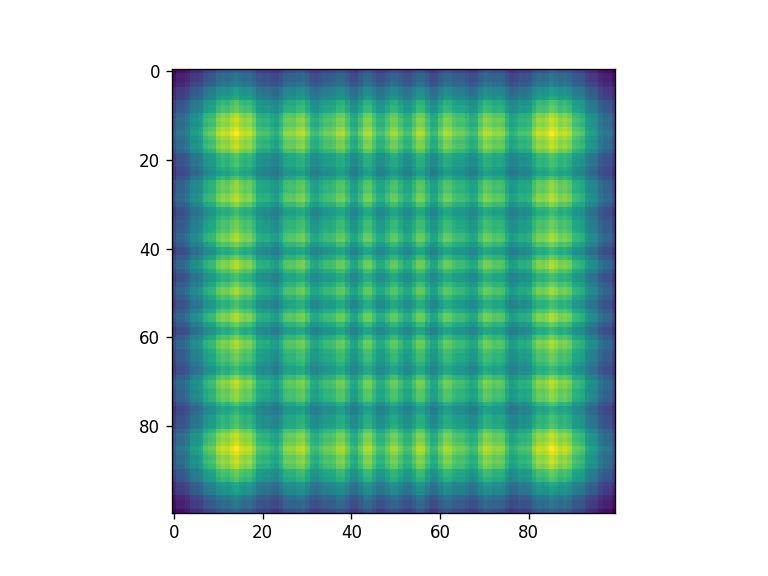

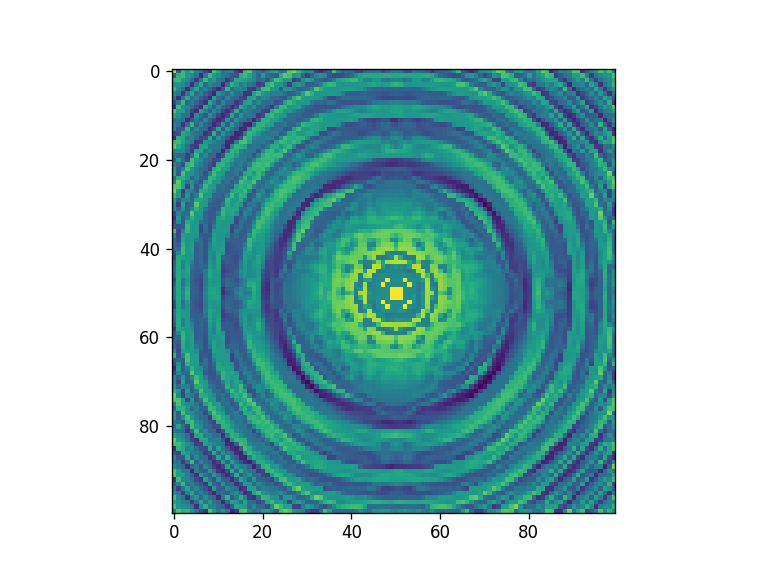

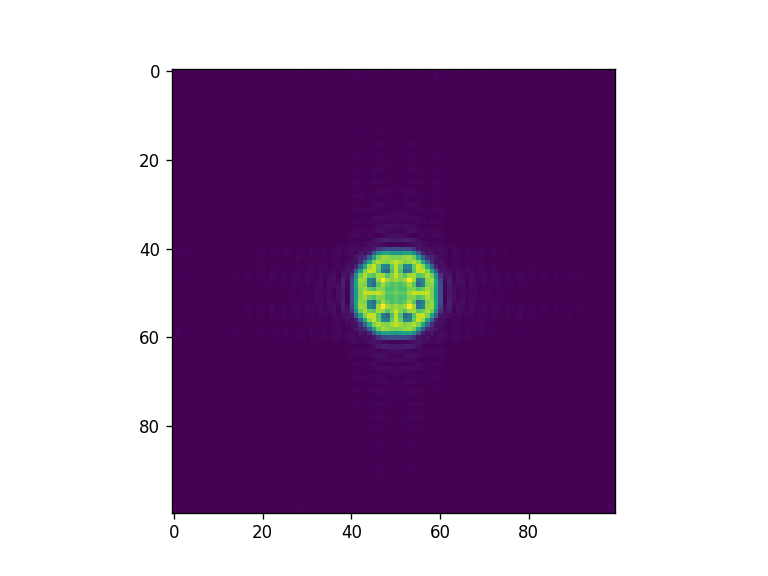

In [26]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, mask2, screen, wavelength) ) )

fig = plt.figure() 
xar2 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar, mask2, screen, wavelength) ) )


In [27]:
#Uncomment to try any of these global optimization methods 

##bounds = [(-np.pi, np.pi)]*len(x0_flatten)

##solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=(mask2, screen,wavelength),  optimizer_method="dual_annealing", tol=1 , minimizer_kwargs={"args":(mask2, screen, wavelength), "tol": 1 },  bounds = bounds)

##solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=(mask2, screen),  optimizer_method="basinhopping", tol=1 ,minimizer_kwargs={"args":(mask2, screen), "tol": 1 },  bounds = bounds)

##solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=(mask2, screen),  optimizer_method="differential_evolution", tol=1 ,minimizer_kwargs={"args":(mask2, screen), "tol": 1 },  bounds = bounds)



## Hologram creation via inverse design

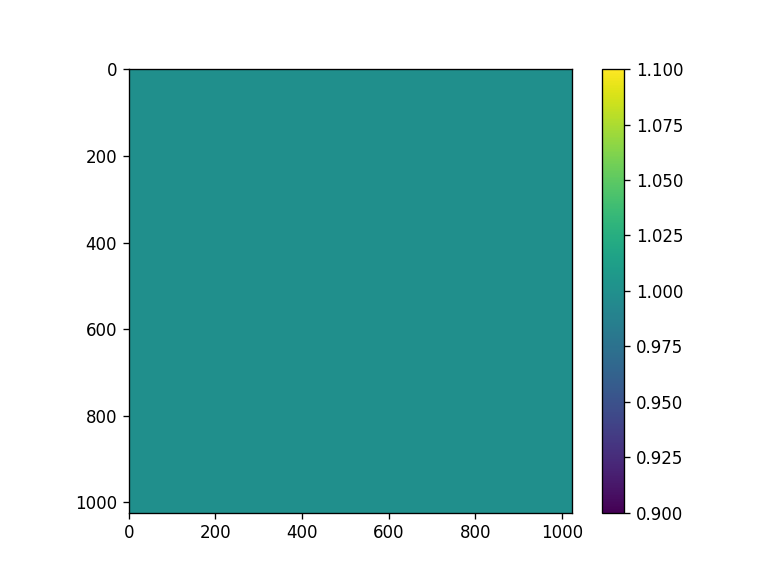

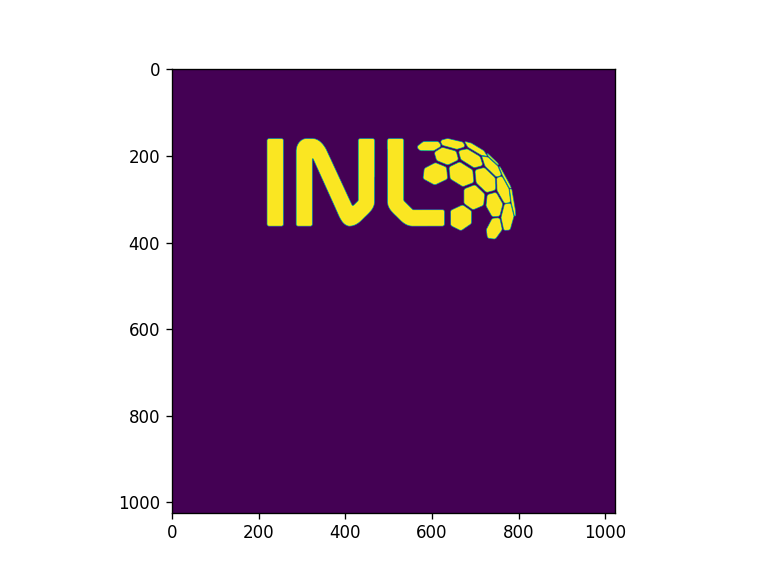

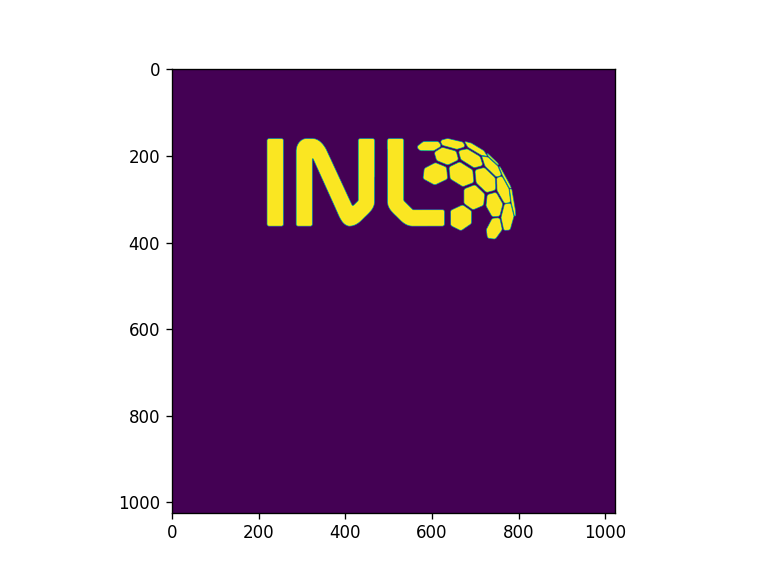

In [41]:
#Using GS first 

#Initial guess
x_pixel, y_pixel = 100, 100
matrix = plt.imread("target.png")

x_pixel, y_pixel = np.shape(matrix)
matrix_flat = matrix.flatten()

x0 = np.random.rand(x_pixel, y_pixel) 
x0 = np.ones((x_pixel,y_pixel))
#x0 = 
x0_flatten = x0.flatten()


xi = np.arange(x_pixel)
yi = np.arange(y_pixel)
XX, YY = np.meshgrid(xi,yi)
    

fig = plt.figure() 
plt.imshow(x0)
plt.colorbar()


fig = plt.figure() 
plt.imshow(matrix)

fig = plt.figure() 
plt.imshow(np.reshape(matrix_flat, (x_pixel, y_pixel)))

Progress: [####################] 100.0%
[Gerchberg Saxton Algorithm]
Elapsed: 0:01:10.573397


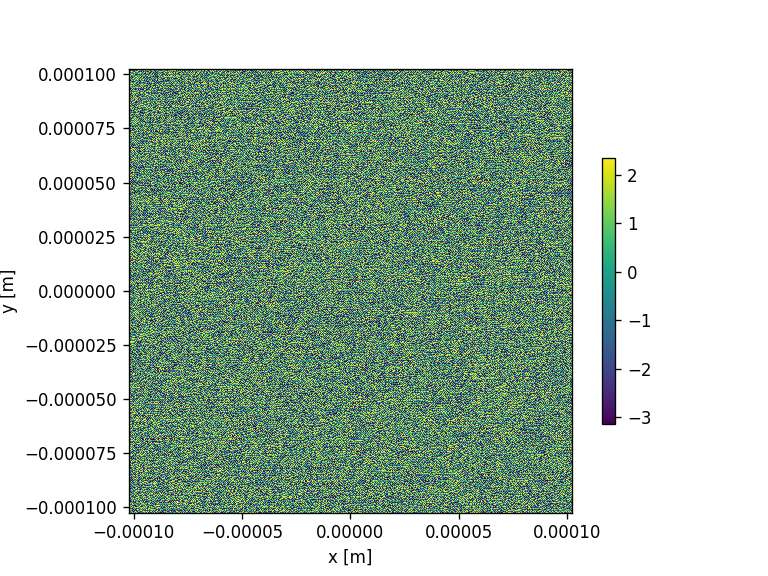

In [42]:
# Multilevel phase hologram
levels = 8

iterations = 100

levels = moe.utils.create_levels(-np.pi, np.pi, levels,)
phase_mask, errors = moe.holograms.algorithm_Gerchberg_Saxton(matrix, iterations=iterations, levels=levels)

phase_mask = moe.holograms.correct_mask_shift(phase_mask)
mask = moe.generate.create_aperture_from_array(phase_mask, pixel_size=(0.2*micro, 0.2*micro), center=True, )


# Discretize to same levels as original
mask.discretize(levels)
moe.plotting.plot_aperture(mask)



Text(0.5, 1.0, 'Calculated far field intensity')

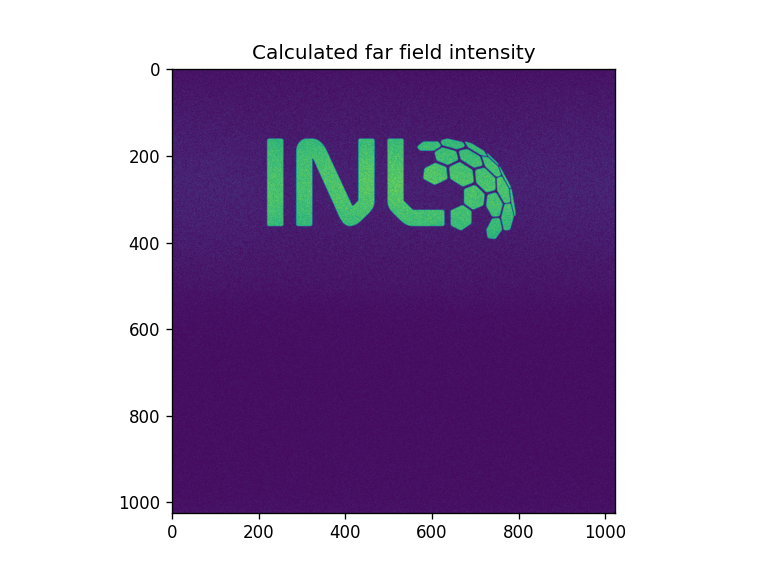

In [43]:

far_field = moe.holograms.calculate_phase_farfield(phase_mask)

plt.figure()
plt.imshow(far_field)
plt.title("Calculated far field intensity")


In [59]:
#Place holders for apertures 

#size of the rectangular mask 
aperture_width  = 50e-6 #m
aperture_height = 50e-6

pixsize = 1e-6 #m

wavelength = 500e-9 #m
focal_length = 200e-6

zmin = wavelength
zmax = 1.2* focal_length
nzs = 500

radius = aperture_width/2 

# Create Aperture
aperture1 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)

# Populate Aperture with Fresnel mask 
mask1 = moe.generate.fresnel_phase(aperture1, focal_length, wavelength )

#moe.plotting.plot_aperture(mask1)


##############
###Fresnel mask with a truncated circular aperture 

# Create empty mask
aperture2 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)


# and truncate around radius
mask2 = moe.generate.fresnel_phase(aperture2, focal_length, wavelength, radius=radius)
#moe.plotting.plot_aperture(mask2)

# Discretize mask in number of levels
# Select exact position of contours  in phase
phase_vals = np.linspace(-np.pi, np.pi, 16)

mask2.discretize(np.array( phase_vals)[:] ) 
#moe.plotting.plot_aperture(mask2)

# Generate a uniform field
field = moe.field.create_empty_field_from_aperture(mask2)

field = moe.field.generate_uniform_field(field, E0=1)

# Modulates the field 
field = moe.field.modulate_field(field, amplitude_mask=None, phase_mask=mask2 )


# Create Aperture
aperture1 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)

# Populate Aperture with Fresnel mask 
mask2 = moe.generate.fresnel_phase(aperture1, focal_length, wavelength )

#moe.plotting.plot_aperture(mask2)

In [53]:
#Define Screen 

# define the wavelength used in the propagation
wavelength = 532*nano

# Define the screen size and create it

screen_width = 2.5
screen_height = 2.5
x_pixel = 1024
y_pixel = 1024


# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -screen_height/2, screen_height/2
xmin, xmax = -screen_width/2, screen_width/2 

x = np.linspace(xmin, xmax, x_pixel)
y = np.linspace(ymin, ymax, y_pixel)
z = np.array([2])


screen = moe.field.Screen(x,y,z)

In [54]:


def FOM3(x, mask, screen, wavelength, mat): 
    #print("Type of x:", type(x), "First element:", x[0])
    #print("Type of x:", type(mask))
    #print("Type of x:", type(screen), "First element:", x[0])
    #print("Type of x:", type(wavelength), "First element:", x[0])
    import jax.numpy as np 
    
    prop_x =  np.abs(moe.optimizer.propagate(np.reshape(x, (len(screen.x), len(screen.y))), mask, screen, wavelength))**2
    
    diff = np.abs(prop_x/np.max(prop_x) - mat/np.max(mat))**2
     
    #print(diff.shape)
    res = (np.sqrt(np.sum(diff)) )
    #print(res)
    
    return res


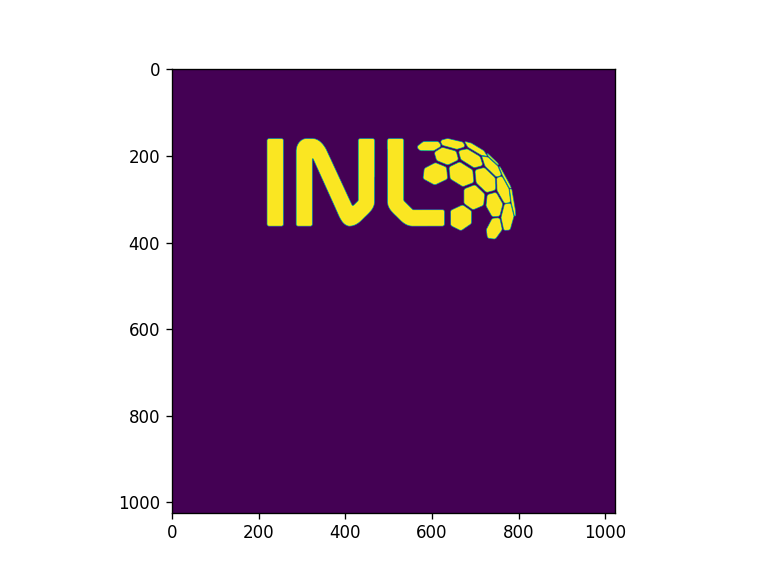

In [55]:

fig = plt.figure() 
plt.imshow(matrix)


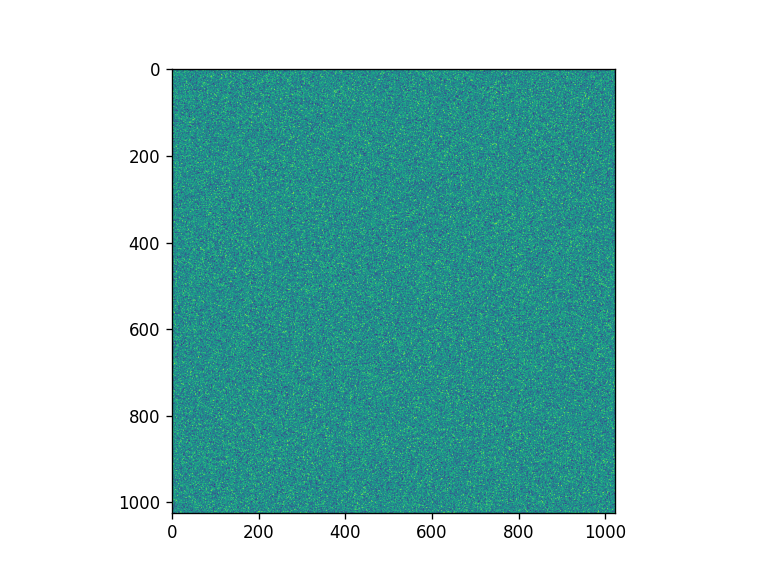

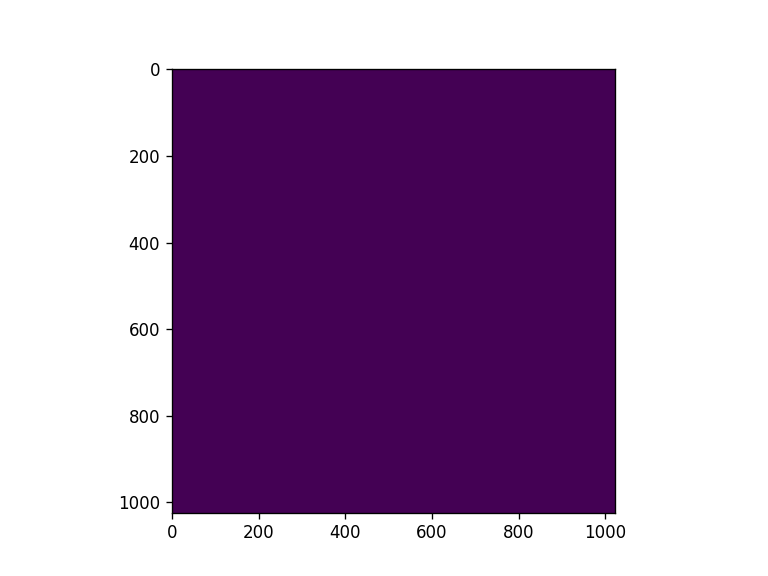

In [56]:
# generation of initial guesses, 

#random 
xrand = np.random.rand(x_pixel, y_pixel)

plt.figure() 
plt.imshow(xrand)

#constant 
xvalues = np.ones((x_pixel, y_pixel))

plt.figure()
plt.imshow(xvalues)
#plt.colorbar()

Elapsed: 0:00:01.800436
Elapsed: 0:00:01.294326
Elapsed: 0:00:00.549510
Elapsed: 0:00:00.784317
Elapsed: 0:00:00.557580
Elapsed: 0:00:00.738106
Elapsed: 0:00:00.583186
Elapsed: 0:00:00.692062
Elapsed: 0:00:00.599912
Elapsed: 0:00:00.763737
Elapsed: 0:00:00.566186
Elapsed: 0:00:00.706758
Elapsed: 0:00:00.553279
Elapsed: 0:00:00.784363
Elapsed: 0:00:00.581808
Elapsed: 0:00:00.799149
Elapsed: 0:00:00.639040
Elapsed: 0:00:00.810719
Elapsed: 0:00:00.587964
Elapsed: 0:00:00.740754
Elapsed: 0:00:00.600261
Elapsed: 0:00:00.748304
Elapsed: 0:00:00.598143
Elapsed: 0:00:00.727523
Elapsed: 0:00:00.569041
Elapsed: 0:00:00.864871
Elapsed: 0:00:00.595863
Elapsed: 0:00:00.750983
Elapsed: 0:00:00.534062
Elapsed: 0:00:00.819535
Elapsed: 0:00:00.603319
Elapsed: 0:00:00.828672
Elapsed: 0:00:00.547702
Elapsed: 0:00:00.753117
Elapsed: 0:00:00.572613
Elapsed: 0:00:00.582952
Elapsed: 0:00:00.694559
Elapsed: 0:00:00.584339
Elapsed: 0:00:00.710136
Elapsed: 0:00:00.535244
Elapsed: 0:00:00.775039
Elapsed: 0:00:00

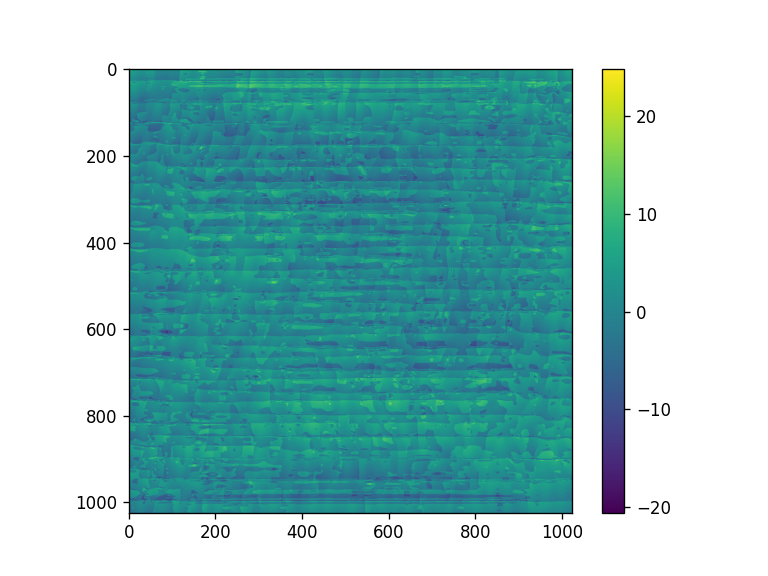

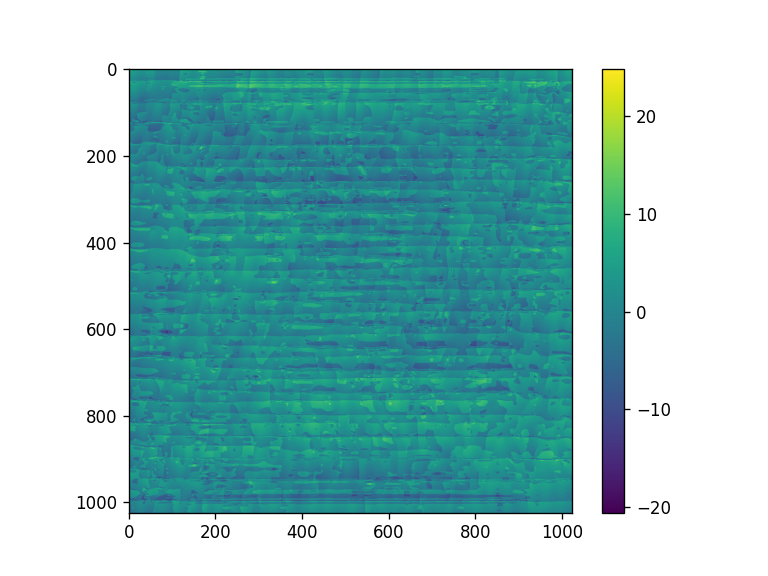

In [57]:
solution = moe.optimizer.optimize(FOM3, x0= xvalues.flatten(), args1=[mask2, screen, wavelength, matrix], verbose = 1, ftol=1e-14,xtol=None, optimizer_method='dogbox' )


x = solution.x

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()

Elapsed: 0:00:00.548954
Elapsed: 0:00:00.512591


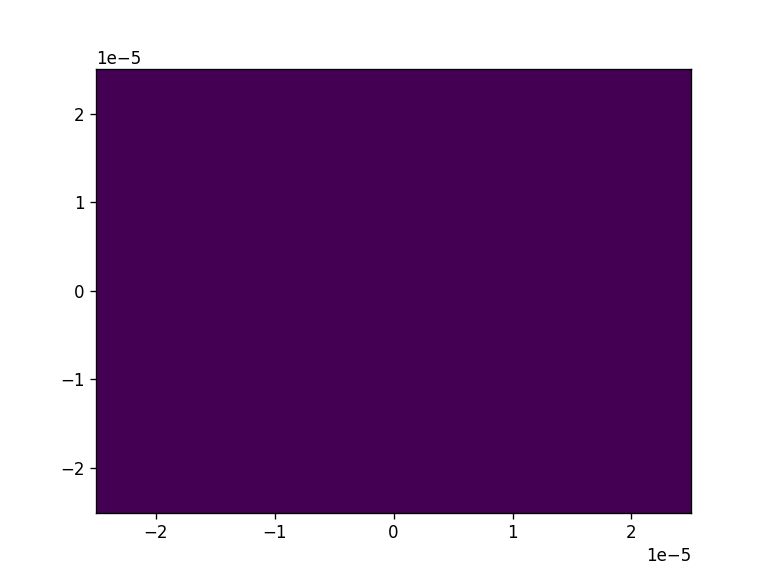

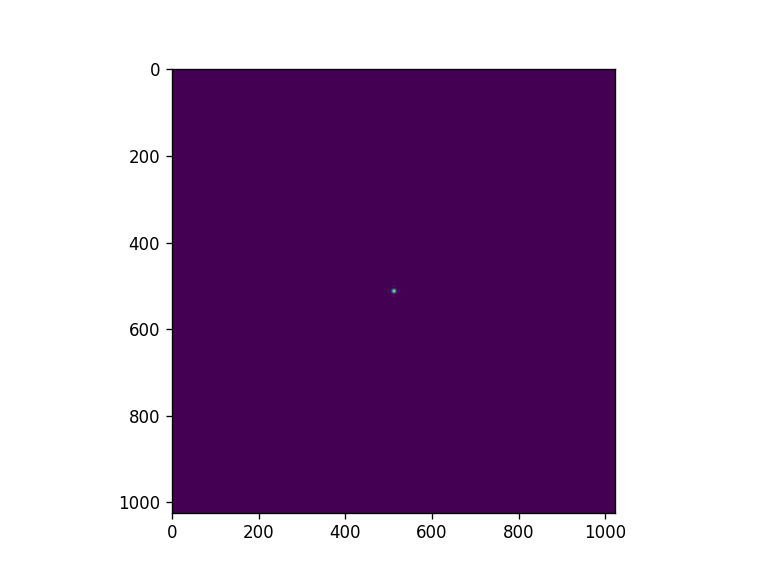

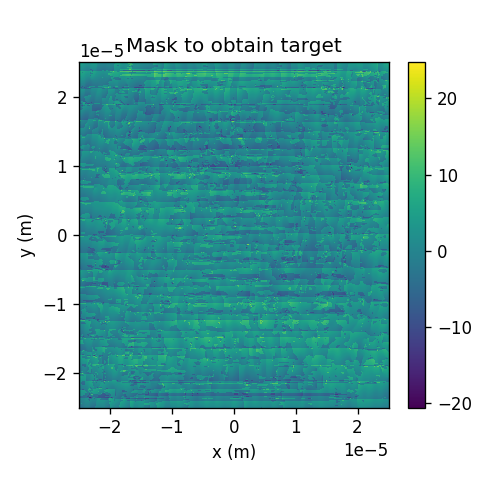

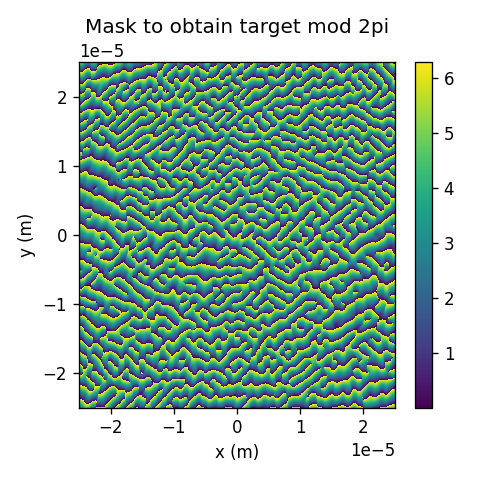

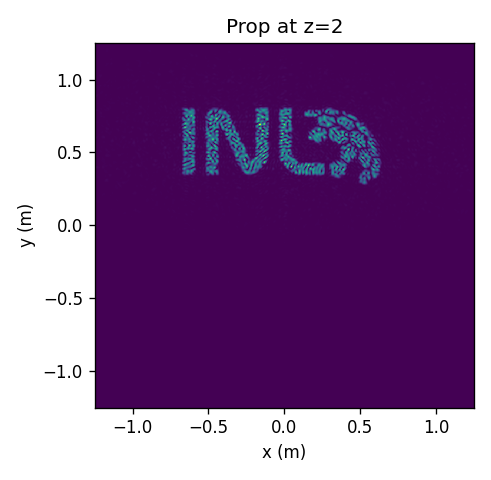

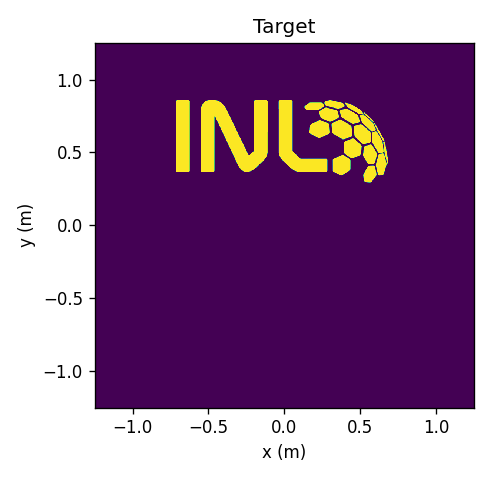

In [61]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
#plt.imshow(xar2) 
plt.pcolormesh(mask2.x, mask2.y, xar2)

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, mask2, screen, wavelength) )**2 )


fig = plt.figure(figsize=(4.1,4)) 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.pcolormesh(mask2.x, mask2.y, np.flip(np.flip(xar3), axis=1)) 
plt.title("Mask to obtain target")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.colorbar()
plt.tight_layout()




fig = plt.figure(figsize=(4.1,4)) 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.pcolormesh(mask2.x, mask2.y, np.flip(np.flip(xar3)%(2*np.pi), axis=1)) 
plt.title("Mask to obtain target mod 2pi")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.colorbar()
plt.tight_layout()



fig = plt.figure(figsize=(4.1,4)) 
plt.pcolormesh(screen.x, screen.y, np.flip(np.flip(np.abs(moe.optimizer.propagate(xar3, mask2, screen, wavelength) )**2 ) , axis=1))
plt.title("Prop at z="+str(screen.z[-1]))
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()

fig = plt.figure(figsize=(4.1,4)) 
plt.pcolormesh(screen.x,screen.y, np.flip(np.flip(np.reshape(matrix, (x_pixel, y_pixel)) ) ,axis =1))
plt.title("Target")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()

# Now we introduce several possible metrics 

In [13]:
sfreq = moe.metrics.spatial_freq_space(screen)

Elapsed: 0:00:01.770882


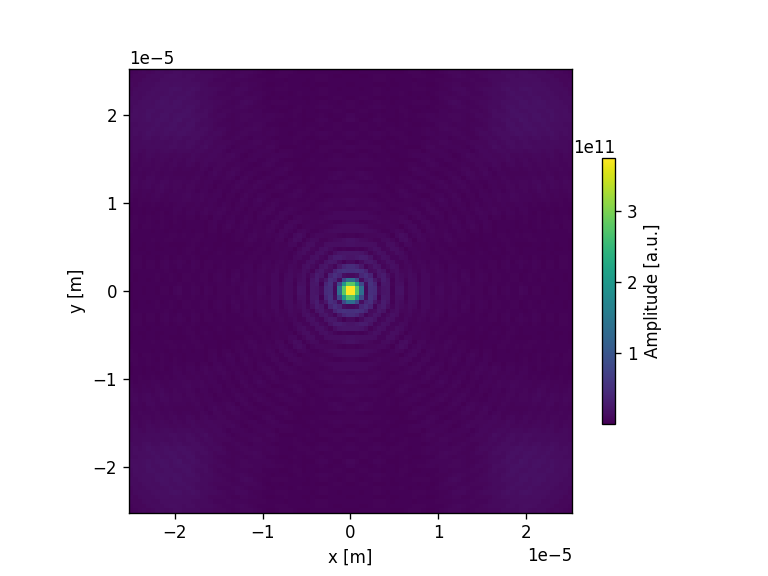

In [10]:
###Propagate field *10and calculate in plane YZ, using npix bins in Y
zmin = wavelength*10
zmax = 1.2* focal_length
nzs = 500

# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -aperture_height/2, aperture_height/2
xmin, xmax = -aperture_width/2, aperture_width/2

x = np.linspace(xmin, xmax, x_pixel)
y = np.linspace(ymin, ymax, y_pixel)
z = np.linspace(zmin, zmax, nzs)


screen = moe.field.Screen(x,y,z)

# Propagate the field 
EXYZ = moe.propagate.Bluestein(field, screen, wavelength)

Exy = moe.field.Screen(x,y,z)
Exy.screen = np.reshape(EXYZ.screen[:,:, int(focal_length/zmax*nzs)], (x_pixel,y_pixel,1))

moe.plotting.plot_screen_XY(Exy, which='amplitude')

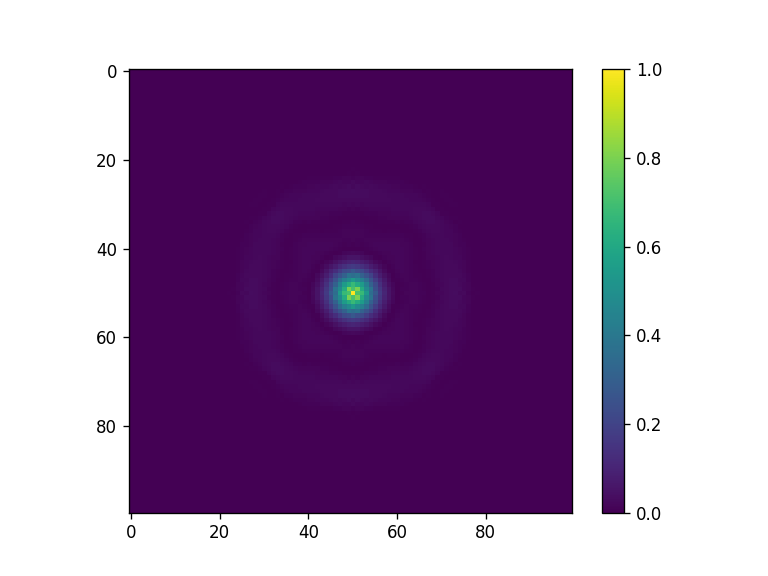

In [11]:
intensity = np.abs(screen.screen[:,:,-1])**2
#intensity = np.abs(Escreen)**2
norm_intensity = intensity/np.max(intensity)  # normalize intensity, not field

otf = sfft.fftshift(sfft.fft2(sfft.ifftshift(norm_intensity)))

center = (otf.shape[0] // 2, otf.shape[1] // 2)
otf_norm =  otf/np.abs(otf[center])


fig = plt.figure() 

plt.imshow( np.abs(otf_norm) )
plt.colorbar()

plt.show()

fig.savefig("OTF.png")



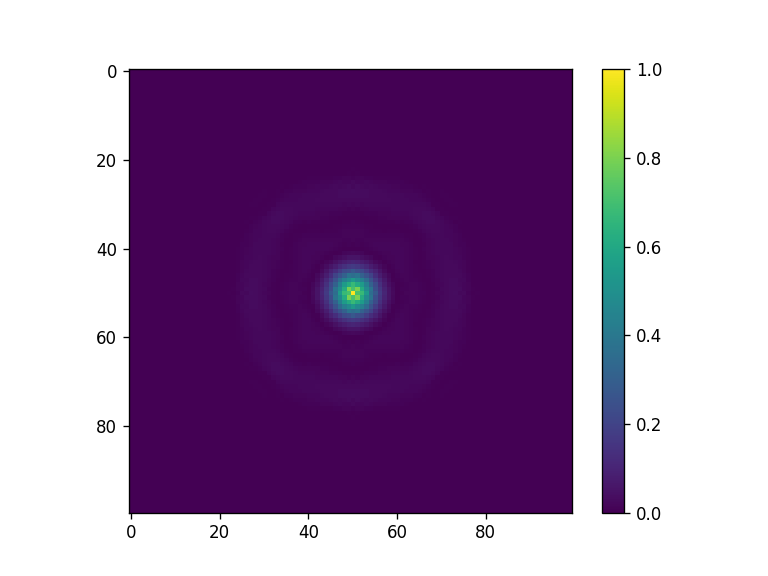

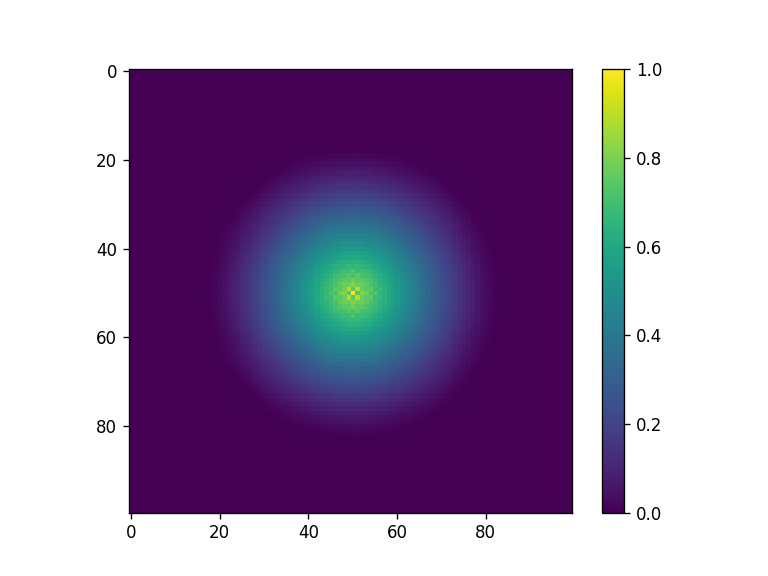

C:\Users\jcunha377\Desktop\pyMOE-main-v1.5\notebooks\6 - Propagation\../..\pyMOE\metrics.py:161: RuntimeWarning: invalid value encountered in arccos
  OTF = (2 / np.pi) * (np.arccos(rho / fc) - (rho / fc) * np.sqrt(1 - (rho / fc)**2))
C:\Users\jcunha377\Desktop\pyMOE-main-v1.5\notebooks\6 - Propagation\../..\pyMOE\metrics.py:161: RuntimeWarning: invalid value encountered in sqrt
  OTF = (2 / np.pi) * (np.arccos(rho / fc) - (rho / fc) * np.sqrt(1 - (rho / fc)**2))


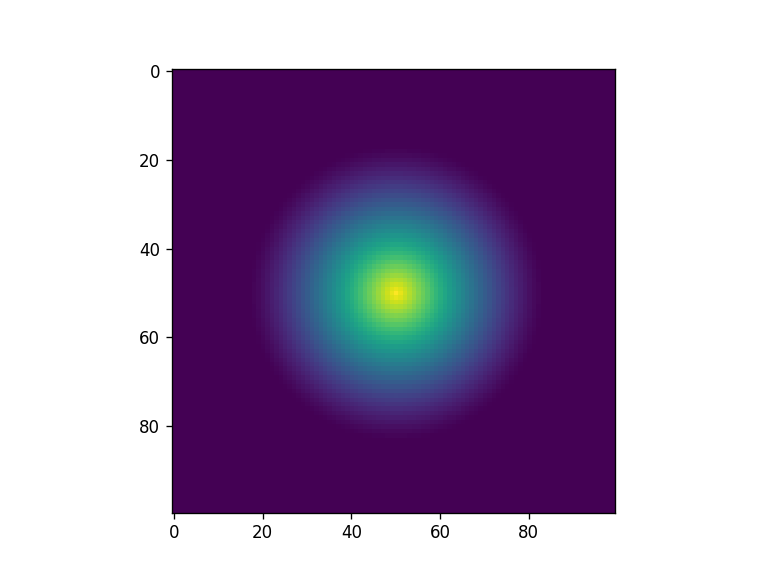

In [12]:
#Calculate the OTF out of focus and in focus 
import scipy.fftpack as sfft

o1 = moe.metrics.calculate_OTF(np.abs(screen.screen[:,:,-1])**2 , plot_OTF=True);
o2 = moe.metrics.calculate_OTF(np.abs(Exy.screen[:,:,-1])**2  , plot_OTF=True);

D = np.max(Exy.x)*2
OTF_ideal = moe.metrics.theoretical_ideal_OTF(Exy, D, wavelength, focal_length)

fig = plt.figure()
plt.imshow( OTF_ideal)

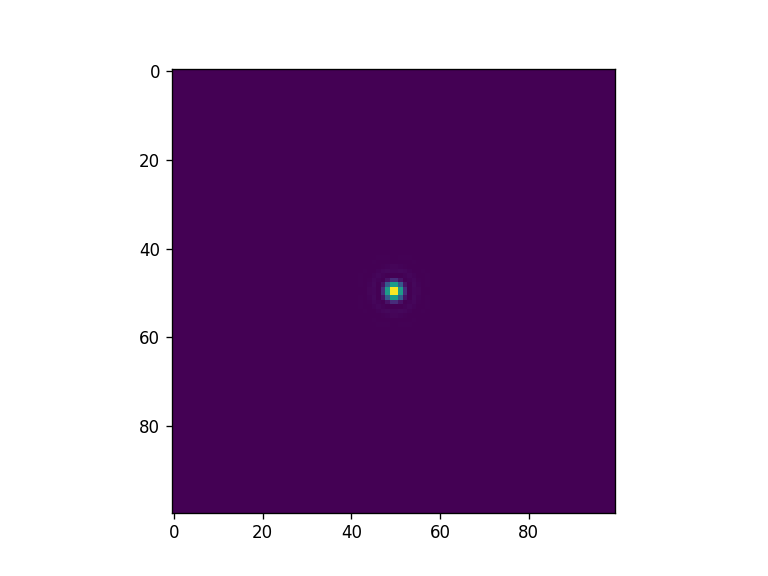

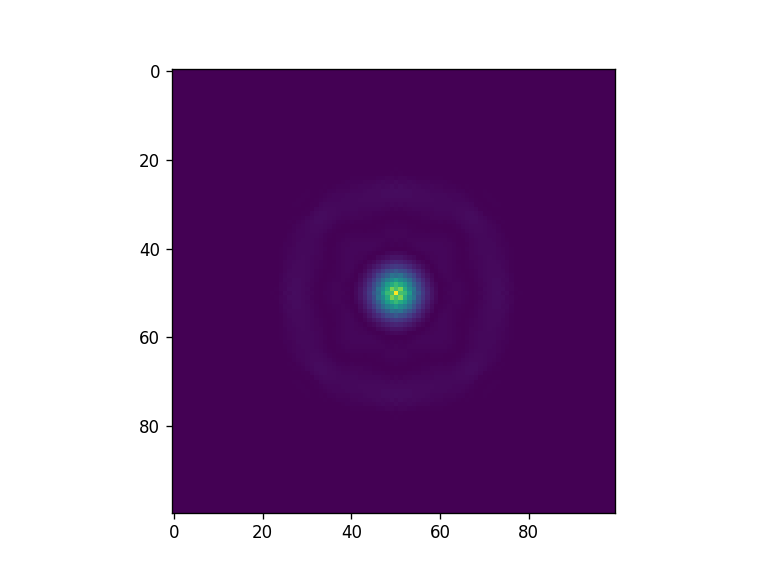

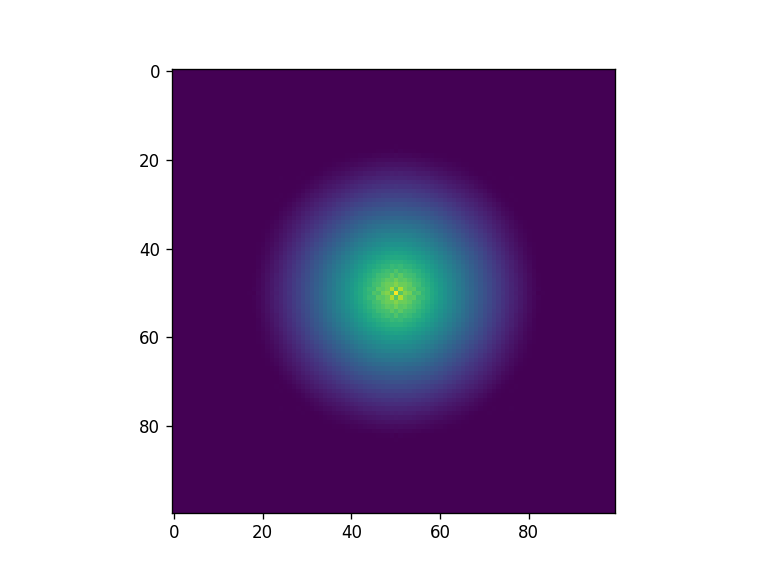

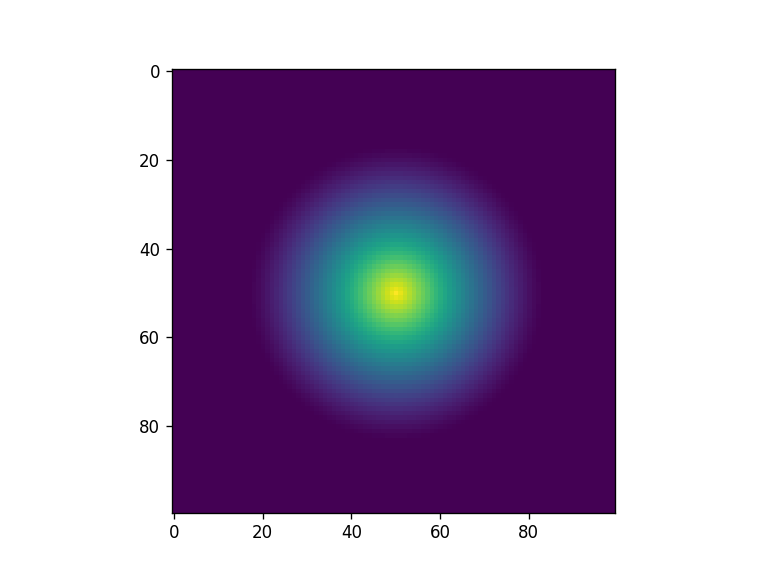

In [13]:
plt.figure() 

plt.imshow(np.abs(Exy.screen)**2) 

plt.figure()

plt.imshow(np.abs(o1) )

plt.figure()

plt.imshow(np.abs(o2) )

plt.figure()
plt.imshow(np.abs(OTF_ideal) )

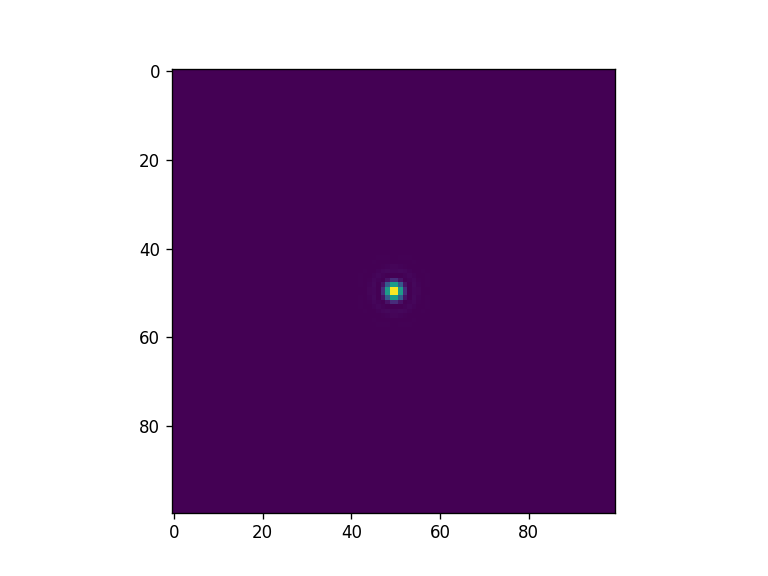

In [14]:
max([max(Exy.x), max(Exy.y)])
Exy.z[0]


fig = plt.figure() 
plt.imshow(np.abs(Exy.screen)**2)

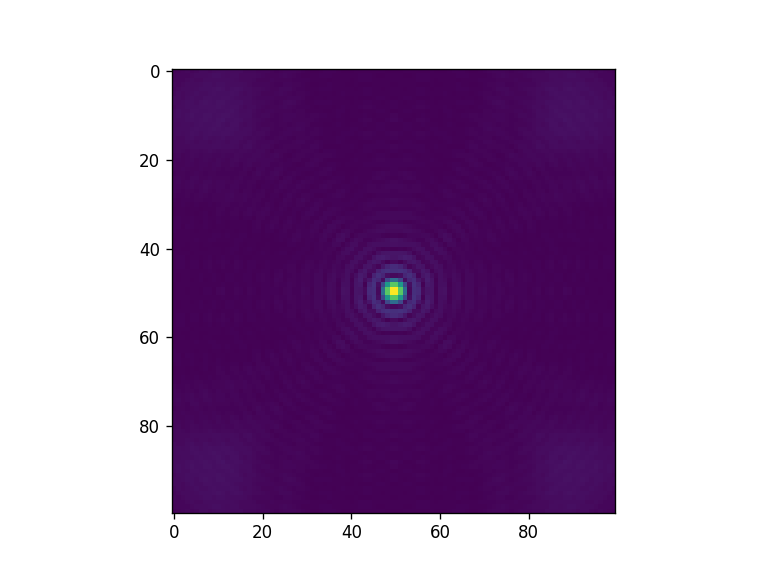

In [15]:
fig= plt.figure() 
plt.imshow(np.abs(Exy.screen) )

(0.14001191436478574, 0.8533976582064924)

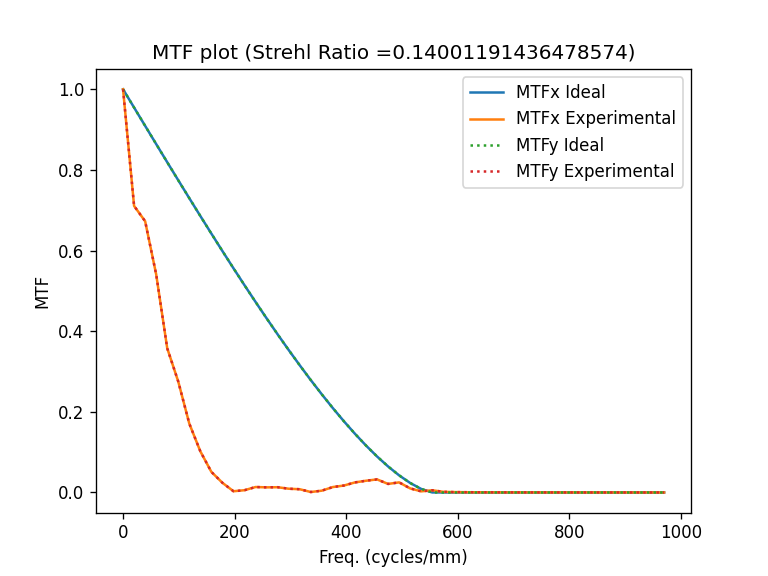

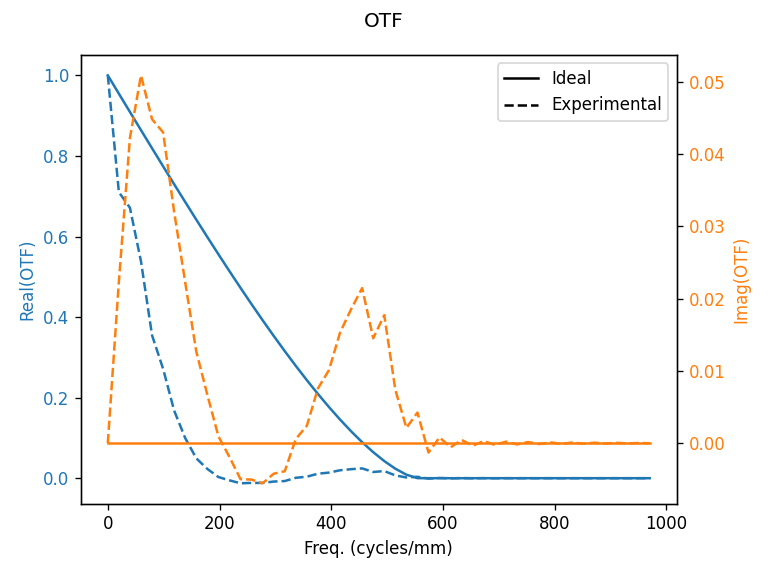

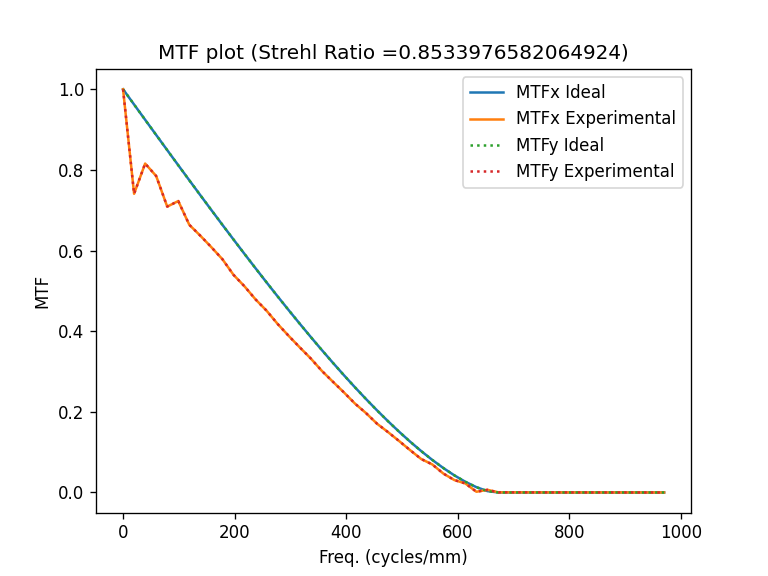

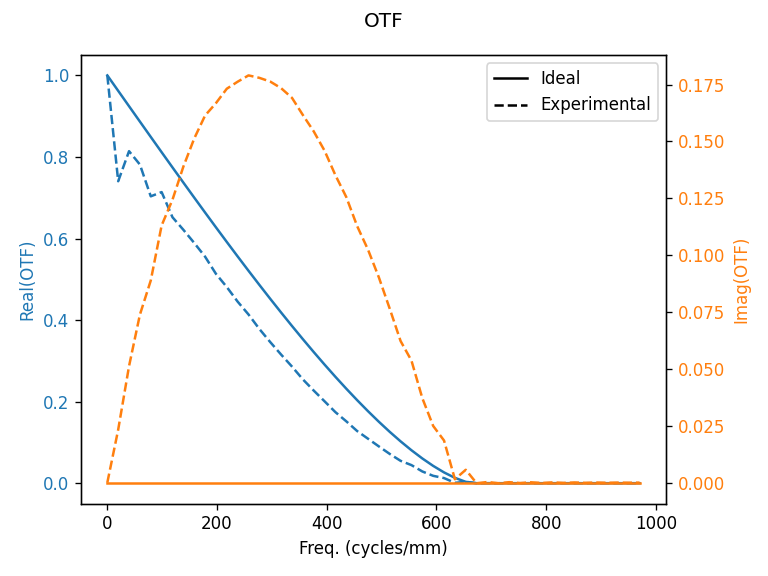

In [16]:
#DEFOCUSED PLANE 
strehlv1 = moe.metrics.strehl_ratio(np.abs(screen.screen[:,:,-1] )**2, screen, max([max(Exy.x), max(Exy.y)])*2, wavelength, screen.z[-1], strehl_from_mtf=True, plot_MTF=True, plot_OTF=True) 

#FOCUSED PLANE 
strehlv2 = moe.metrics.strehl_ratio(np.abs(Exy.screen[:,:,-1] )**2, Exy, max([max(Exy.x), max(Exy.y)])*2, wavelength, focal_length, strehl_from_mtf=True, plot_MTF=True, plot_OTF=True )

strehlv1, strehlv2

(0.7409945149886844, 0.7409945149886844)

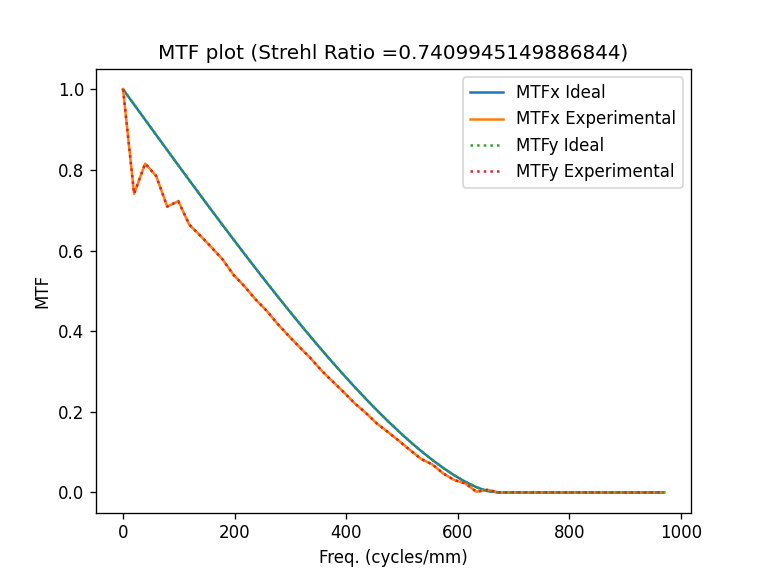

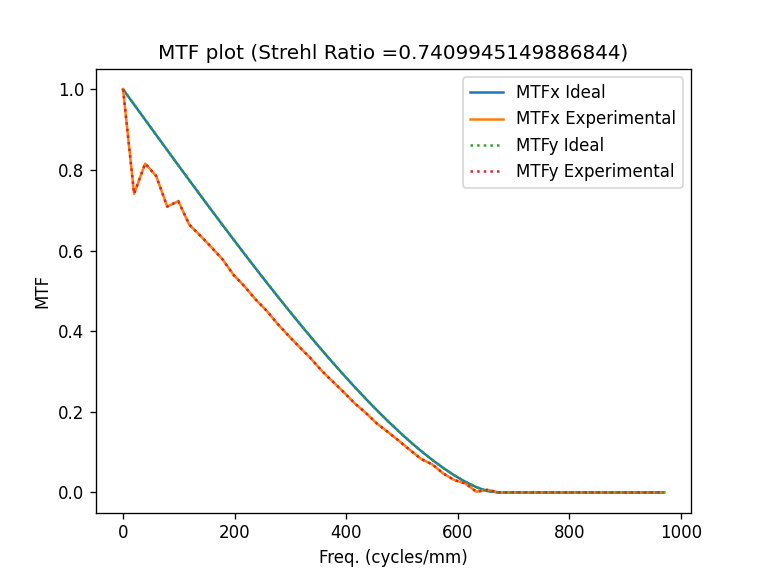

In [17]:
moe.metrics.strehl_ratio(np.abs(Exy.screen[:,:,-1])**2, screen, max([max(screen.x), max(screen.y)])*2, wavelength, focal_length, plot_MTF=True) ,\
moe.metrics.strehl_ratio(np.abs(Exy.screen[:,:,-1])**2, Exy, max([max(Exy.x), max(Exy.y)])*2, wavelength, focal_length, plot_MTF=True) 
      

Text(0.5, 1.0, 'Encircled energy')

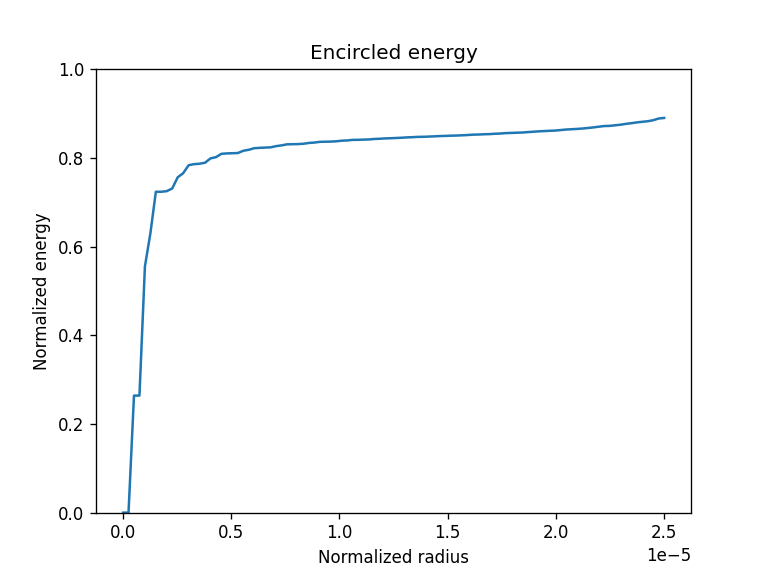

In [18]:
center=(0,0)

parray = np.linspace(0, aperture_width/2, 100)

enarray = [moe.metrics.encircled_energy(Exy, p) for p in parray]
enmax = moe.metrics.encircled_energy(Exy, 1.01)

fig = plt.figure() 

plt.plot(parray, enarray/enmax)
plt.ylim([0,1])
plt.xlabel("Normalized radius")
plt.ylabel("Normalized energy")
plt.title("Encircled energy")
#plt.yscale("log")

#This is not exactly one, because other energy is lost to the square parts of the sensor 


#The energy plateus at 0.5e-6, so makes sense to use that as p 

In [19]:
XY=np.abs(Exy.screen[:,:,-1])**2


largestpeak_height , largestpeak_width, position = moe.metrics.find_FWHM_2d(XY, prominence=0.5)

largestpeak_height , largestpeak_width, position

(1.407829971532031e+22, 5.443500790316065, array([50, 50], dtype=int64))

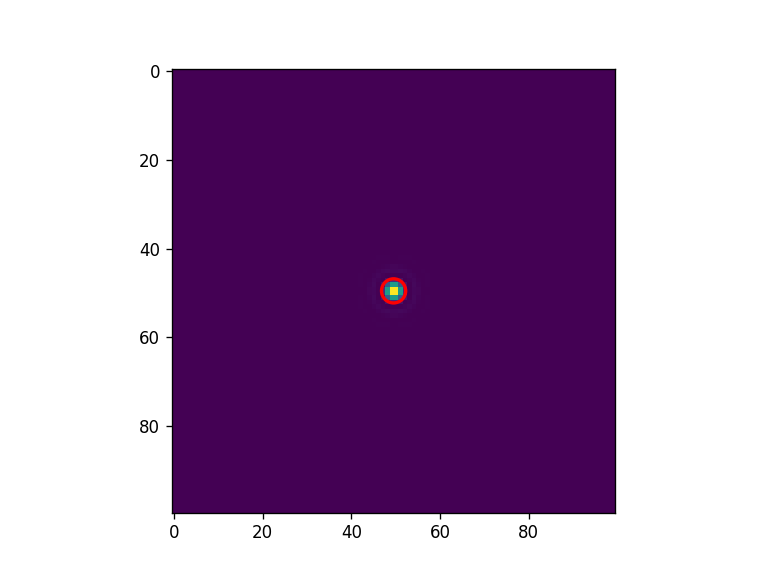

In [20]:
from matplotlib.patches import Circle 

fig = plt.figure() 

plt.imshow(np.abs(XY))

# Get image dimensions
height, width = XY.shape

# Add central circle
circle = Circle((position[0]-0.5, position[1]-0.5), radius=largestpeak_width/2, color='red', fill=False, linewidth=2)
plt.gca().add_patch(circle)

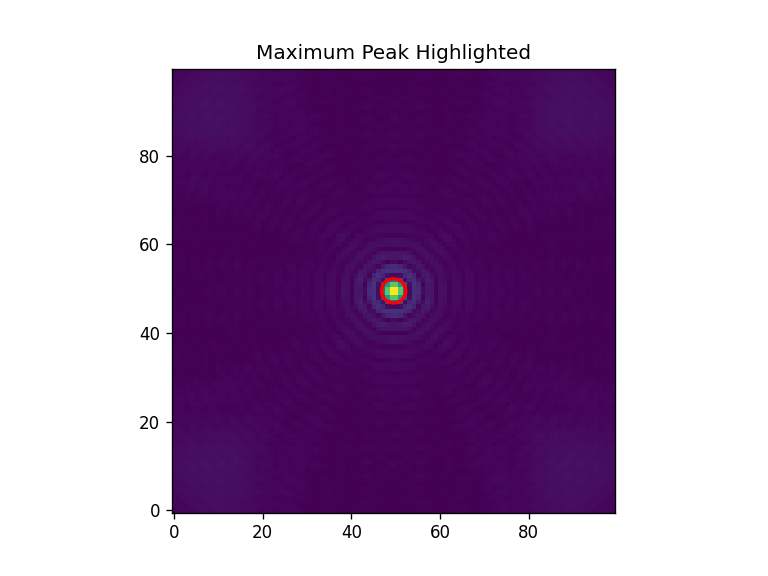

In [21]:
largestpeak_height , largestpeak_width, largestpeak_position = moe.metrics.find_FWHM_2d(np.abs(Exy.screen[:,:,-1])**2, prominence=0.5)

import matplotlib.pyplot as plt
from matplotlib.patches import Circle

fig, ax = plt.subplots()
ax.imshow(np.abs(Exy.screen[:,:,-1]),  origin='lower')

# Draw the circle
circle = Circle((largestpeak_position[0]-0.5, largestpeak_position[1]-0.5),  # x, y
                radius=largestpeak_width/2, color='red', fill=False, linewidth=2)
ax.add_patch(circle)

# Optional: mark the center
#ax.plot(largestpeak_position[0], largestpeak_position[1], 'ro')  # center dot

plt.title("Maximum Peak Highlighted")
plt.show()

In [22]:
##encircled energy at 1 FWHM 

one_fwhm = moe.metrics.encircled_energy(Exy, (width/2)*pixsize)/moe.metrics.encircled_energy(Exy, 1.01)

##encircled energy at 0.5 FWHM 

half_fwhm = moe.metrics.encircled_energy(Exy, (width/2)*pixsize*0.5)/moe.metrics.encircled_energy(Exy, 1.01)


(width/2)*pixsize, one_fwhm, half_fwhm 
#This is consistent with the plateauing that is seen in the encircled energy 

(4.9999999999999996e-05, 1.0, 0.8898830512987684)

Text(0.5, 1.0, 'FOcusing Efficiency')

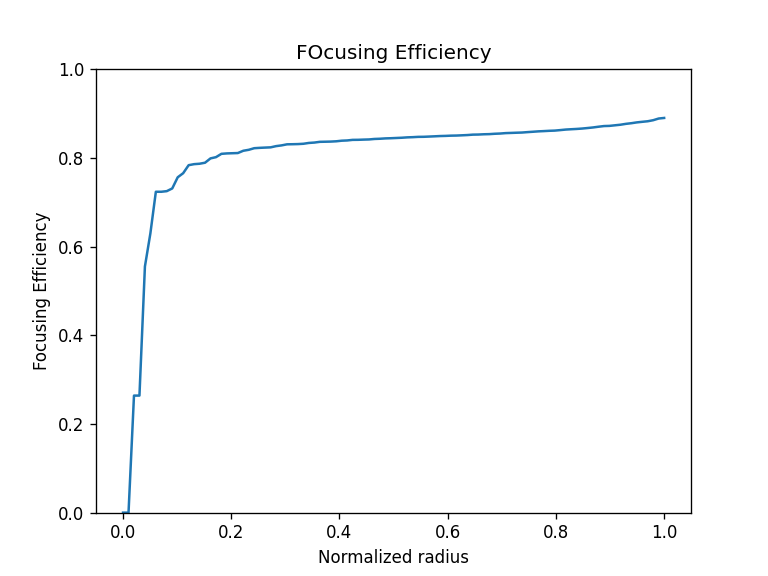

In [23]:
center=(0,0)

parray = np.linspace(0, aperture_width/2, 100)

#Should give the same as the enclircled energy 
farray1 = [moe.metrics.focus_efficiency(Exy, p,  encircled_energy(Exy, 1.01),center=(0,0),) for p in parray]

fig = plt.figure() 

plt.plot(parray/(aperture_width/2), farray1)
plt.ylim([0,1])
plt.xlabel("Normalized radius")
plt.ylabel("Focusing Efficiency")
plt.title("FOcusing Efficiency")
#plt.yscale("log")


Text(0.5, 1.0, 'Engelberg OPM')

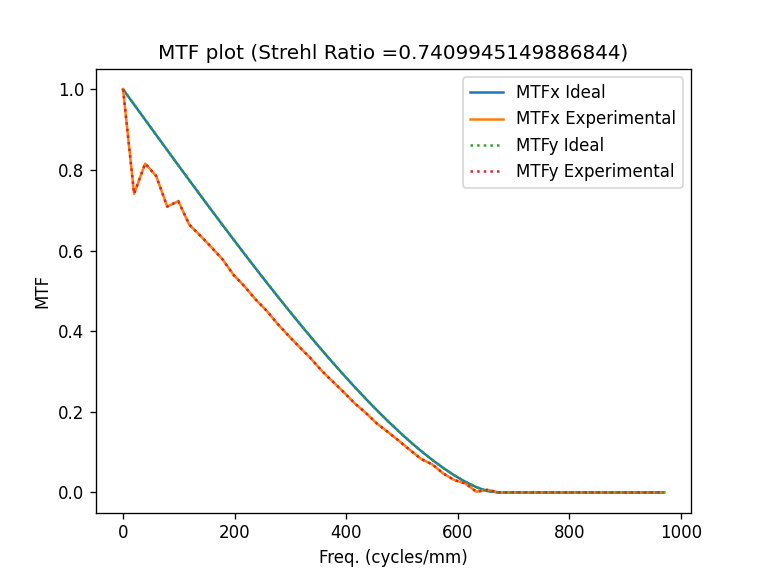

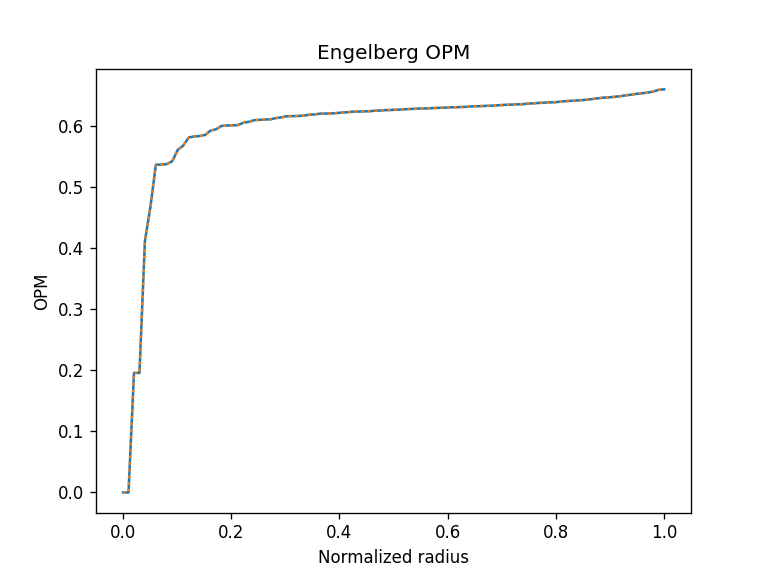

In [24]:
center=(0,0)

parray = np.linspace(0, aperture_width/2, 100)

farray2 = [moe.metrics.Engelberg_OPM(Exy, p,  moe.metrics.encircled_energy(Exy, 1.01),1, wavelength, z = focal_length) for p in parray]
strehlr = moe.metrics.strehl_ratio(np.abs(Exy.screen[:,:,-1])**2, Exy, max([max(Exy.x), max(Exy.y)])*2, wavelength, focal_length, plot_MTF=True) 

fig = plt.figure() 

plt.plot(parray/(aperture_width/2), farray2)
plt.plot(parray/(aperture_width/2), strehlr*np.array(farray1), ':' )
#plt.ylim([0,1])
plt.xlabel("Normalized radius")
plt.ylabel("OPM")
plt.title("Engelberg OPM")
#plt.yscale("log")


#This is not exactly one, because other energy is lost to the square parts of the sensor 

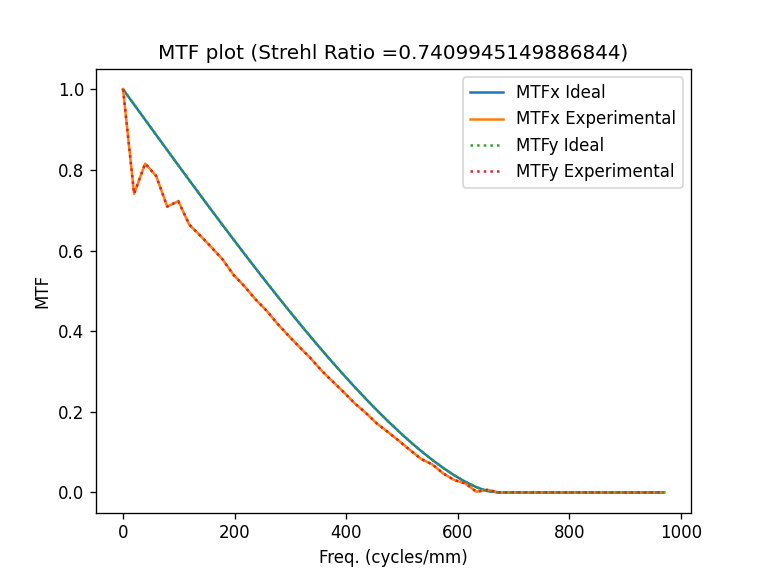

In [25]:
strehlr = moe.metrics.strehl_ratio(np.abs(Exy.screen[:,:,0])**2, screen, max([max(Exy.x), max(Exy.y)])*2, wavelength, focal_length, plot_MTF=True) 

Text(0.5, 1.0, 'Ensquared energy')

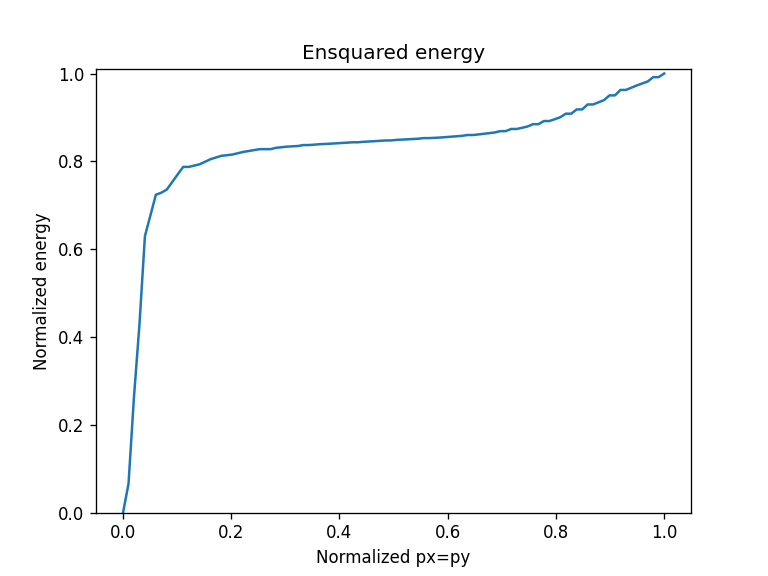

In [26]:
center=(0,0)

parray = np.linspace(0, aperture_width/2, 100)

enarray = [moe.metrics.ensquared_energy(Exy, p, p) for p in parray]
enmax = moe.metrics.ensquared_energy(Exy, 1,1)

fig = plt.figure() 

plt.plot(parray/(aperture_width/2), enarray/enmax)
plt.ylim([0,1.01])
plt.xlabel("Normalized px=py")
plt.ylabel("Normalized energy")
plt.title("Ensquared energy")

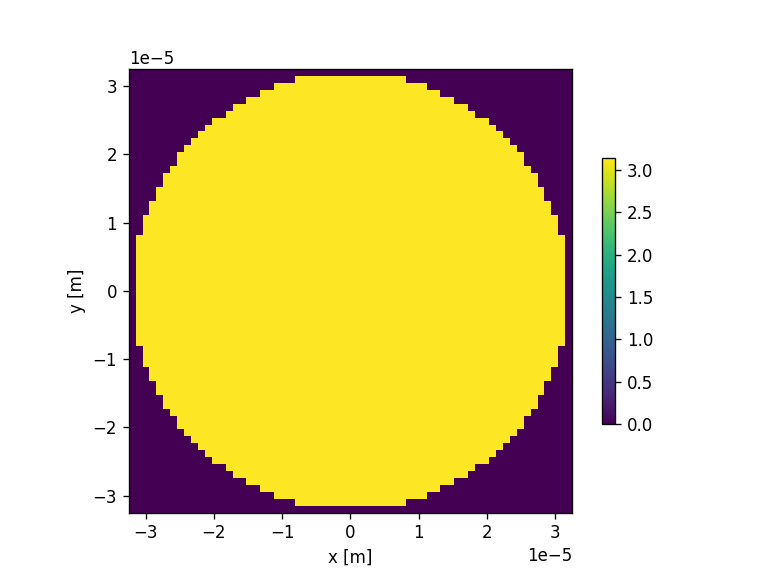

In [27]:
# Make circular apertures (returns also the 2D array)

wavelength = 1550e-9 #m

 
pixsize = 1e-6
x_pixel = 64
y_pixel = 64
 
aperture_width  = x_pixel*pixsize
aperture_height = y_pixel*pixsize

radius = 0.5*x_pixel*pixsize #m 
zdist = 10*radius #m

#screen size 
xminus = -400e-3 #m
xplus = 400e-3 #m 

    

# Define Aperture
aperture = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)

# Populate Aperture from phase mask 
mask = moe.generate.circular_aperture(aperture, radius=radius, center=(0,0))

# Define Phase mask 
mask_phase = moe.generate.create_empty_aperture_from_aperture(aperture)
mask_phase.aperture = mask.aperture*np.pi


# Plot the circular mask
moe.plotting.plot_aperture(mask_phase)



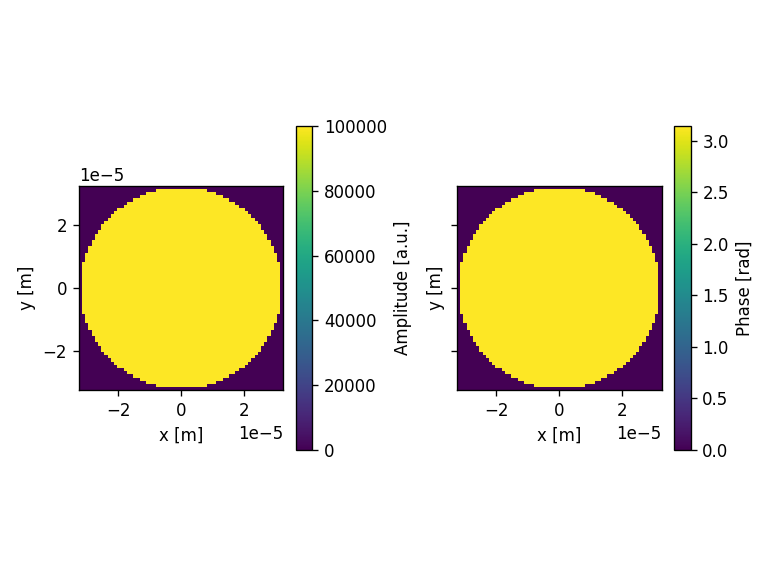

Elapsed: 0:00:00.784793


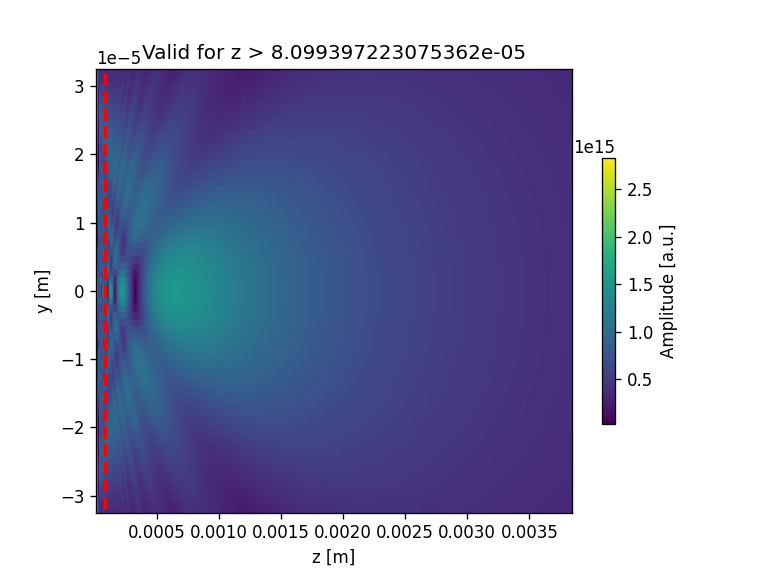

C:\Users\jcunha377\AppData\Roaming\Python\Python311\site-packages\numpy\ma\core.py:3387: ComplexWarning: Casting complex values to real discards the imaginary part
  _data[indx] = dval


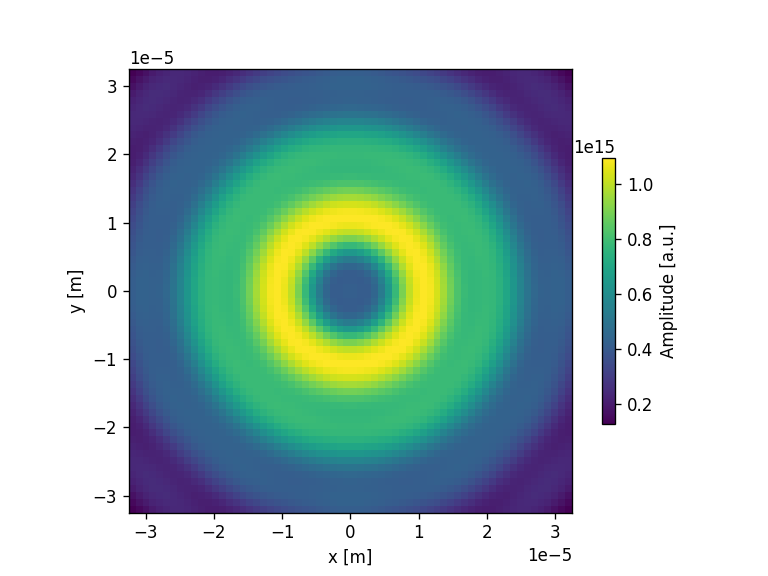

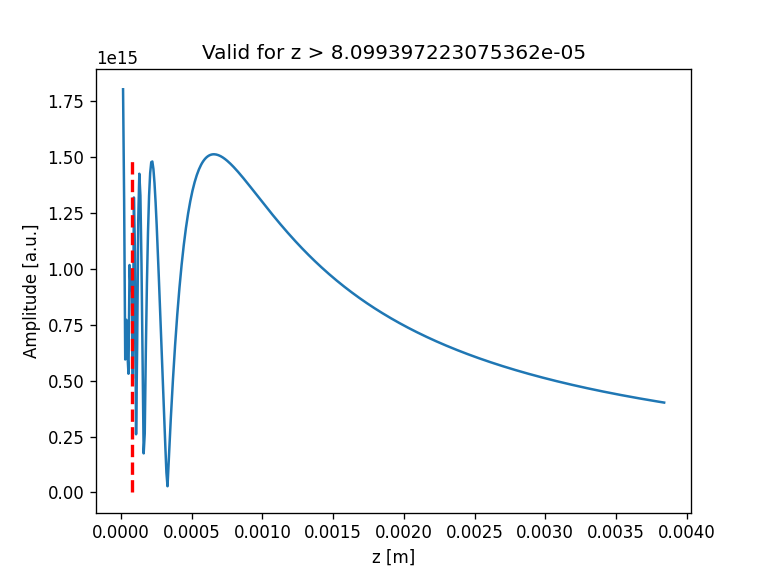

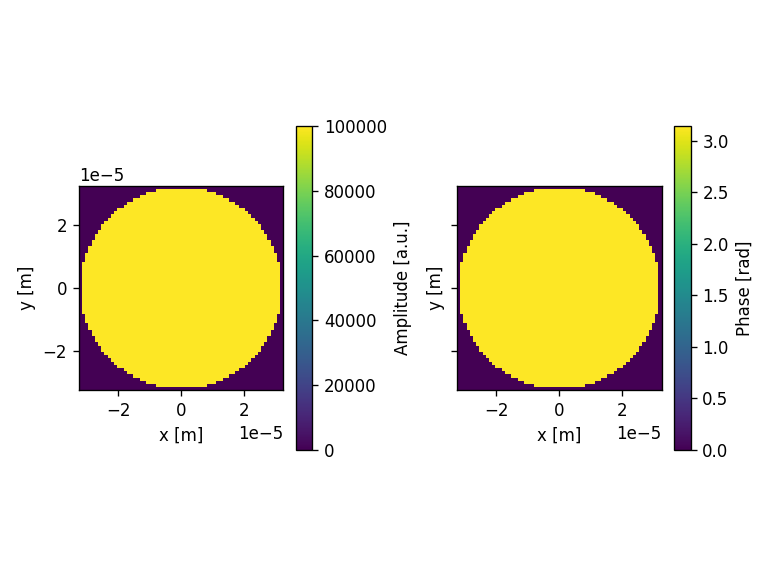

Elapsed: 0:00:00.749079


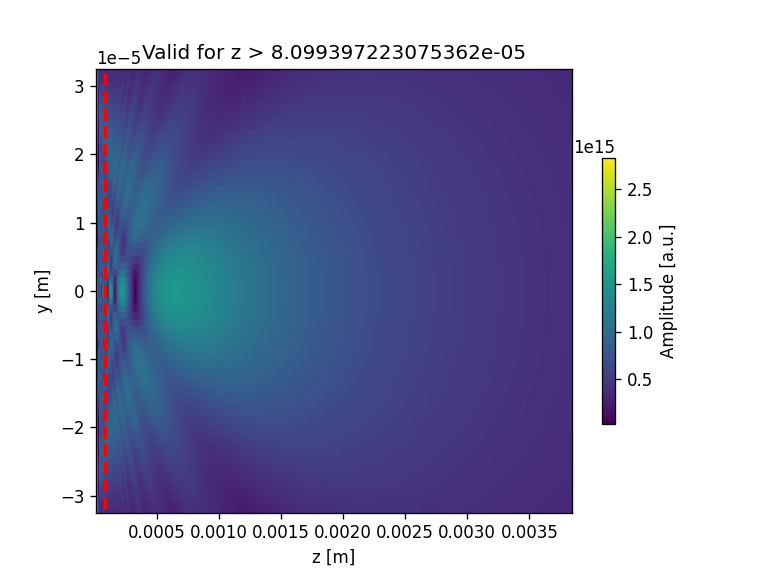

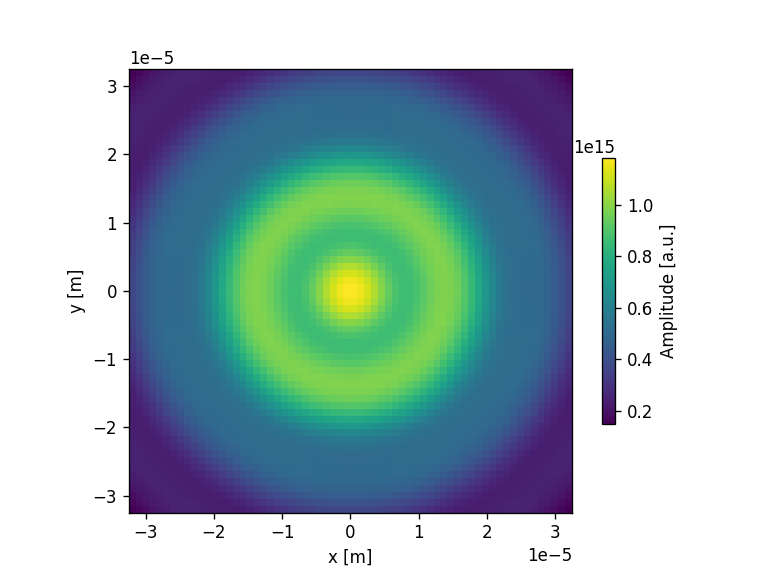

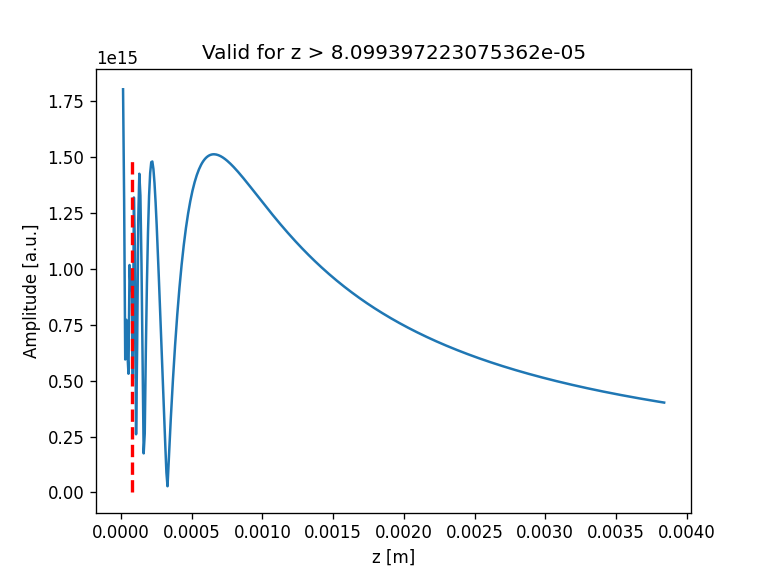

In [28]:
###Propagate field *10and calculate in plane YZ, using npix bins in Y
zdist=100*radius
zmin = wavelength*10
zmax = 1.2* zdist
nzs = 500

focal_length = 3.5e-4


# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -aperture_height/2, aperture_height/2
xmin, xmax = -aperture_width/2, aperture_width/2

x = np.linspace(xmin, xmax, x_pixel)
y = np.linspace(ymin, ymax, y_pixel)
z = np.linspace(zmin, zmax, nzs)

# Calculates a field to use with the calculated mask

# Initialize a Field from the Aperture mask 
field = moe.field.create_empty_field_from_aperture(mask)

# Generate a uniform field
field = moe.field.generate_uniform_field(field, E0=1e5)

# Or Gaussian field is also available 
#field = moe.field.generate_gaussian_field(field, E0=1, w0=100*micro)

# Modulates the field with a given aperture that can be used either as an amplitude mask or a phase mask
field = moe.field.modulate_field(field, amplitude_mask=mask, phase_mask=mask_phase)

# Plots the field (amplitude and phase)
moe.plotting.plot_field(field)

plt.tight_layout()
plt.show()


screen = moe.field.Screen(x,y,z)

# Propagate the field 
EXYZ = moe.propagate.Bluestein(field, screen, wavelength)

Eyz = moe.field.Screen(0,y,z)
Eyz.screen = np.reshape(EXYZ.screen[:,int(y_pixel/2), :], np.shape(Eyz.screen[:, :, :]))

moe.plotting.plot_screen_YZ(Eyz, which='amplitude')

limitx = moe.propagate.Fresnel_criterion(wavelength,radius)
plt.vlines(limitx, -radius, radius, colors='red', linestyles='dashed', lw=2)

plt.title("Valid for z > "+str(limitx))

plt.show()

Exy = moe.field.Screen(x,y,focal_length)
Exy.screen = np.reshape(EXYZ.screen[:,:, int(focal_length/zmax*nzs)], np.shape(Exy.screen[:, :, :]))

moe.plotting.plot_screen_XY(Exy, which='amplitude')

Ezz = moe.field.Screen(0,0,z)
Ezz.screen = np.reshape(EXYZ.screen[int(x_pixel/2),int(y_pixel/2),:], np.shape(Ezz.screen[:, :, :]))

moe.plotting.plot_screen_ZZ(Ezz, which='amplitude')

limitx = moe.propagate.Fresnel_criterion(wavelength,radius)
plt.vlines(limitx, 0, np.max(Ezz.screen), colors='red', linestyles='dashed', lw=2)

plt.title("Valid for z > "+str(limitx))

plt.show()

###Propagate field *10and calculate in plane YZ, using npix bins in Y
zdist=100*radius
zmin = wavelength*10
zmax = 1.2* zdist
nzs = 500

focal_length = 4.5e-4


# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -aperture_height/2, aperture_height/2
xmin, xmax = -aperture_width/2, aperture_width/2

x = np.linspace(xmin, xmax, x_pixel)
y = np.linspace(ymin, ymax, y_pixel)
z = np.linspace(zmin, zmax, nzs)

# Calculates a field to use with the calculated mask

# Initialize a Field from the Aperture mask 
field = moe.field.create_empty_field_from_aperture(mask)

# Generate a uniform field
field = moe.field.generate_uniform_field(field, E0=1e5)

# Or Gaussian field is also available 
#field = moe.field.generate_gaussian_field(field, E0=1, w0=100*micro)

# Modulates the field with a given aperture that can be used either as an amplitude mask or a phase mask
field = moe.field.modulate_field(field, amplitude_mask=mask, phase_mask=mask_phase)

# Plots the field (amplitude and phase)
moe.plotting.plot_field(field)

plt.tight_layout()
plt.show()


screen = moe.field.Screen(x,y,z)

# Propagate the field 
EXYZ = moe.propagate.Bluestein(field, screen, wavelength)

Eyz = moe.field.Screen(0,y,z)
Eyz.screen = np.reshape(EXYZ.screen[:,int(y_pixel/2), :], np.shape(Eyz.screen[:, :, :]))

moe.plotting.plot_screen_YZ(Eyz, which='amplitude')

limitx = moe.propagate.Fresnel_criterion(wavelength,radius)
plt.vlines(limitx, -radius, radius, colors='red', linestyles='dashed', lw=2)

plt.title("Valid for z > "+str(limitx))

plt.show()

Exy = moe.field.Screen(x,y,[focal_length])
Exy.screen = np.reshape(EXYZ.screen[:,:, int(focal_length/zmax*nzs)], np.shape(Exy.screen[:, :, :]))

moe.plotting.plot_screen_XY(Exy, which='amplitude')

Ezz = moe.field.Screen(0,0,z)
Ezz.screen = np.reshape(EXYZ.screen[int(x_pixel/2),int(y_pixel/2),:], np.shape(Ezz.screen[:, :, :]))

moe.plotting.plot_screen_ZZ(Ezz, which='amplitude')

limitx = moe.propagate.Fresnel_criterion(wavelength,radius)
plt.vlines(limitx, 0, np.max(Ezz.screen), colors='red', linestyles='dashed', lw=2)

plt.title("Valid for z > "+str(limitx))

plt.show()

In [65]:
"""
center=(0,0)

parray1 = np.linspace(0, aperture_width, 200)

enarray = [moe.metrics.encircled_energy(Exy, p) for p in parray1]
enmax = moe.metrics.encircled_energy(Exy, 1.01)


parray2 = np.linspace(0, 24*radius, 100)
enarray_theo = [moe.metrics.theoretical_encircled_energy(Exy, p) for p in parray2]
enmaxtheo = moe.metrics.theoretical_encircled_energy(Exy, 1.01)


enarray2 = [moe.metrics.encircled_energy(Exy, p) for p in parray1]
enmax2 = moe.metrics.encircled_energy(Exy, 1.01)


fig = plt.figure() 

plt.plot(parray1/parray1.max(), enarray/enmax)
plt.plot(parray2/parray2.max(), enarray_theo/enmaxtheo)
plt.plot(parray1/parray1.max(), enarray2/enmax2)
#plt.ylim([0,1])
plt.xlabel("Normalized radius")
plt.ylabel("Normalized energy")
plt.title("Encircled energy")
#plt.yscale("log")

#This is not exactly one, because other energy is lost to the square parts of the sensor 
"""

'\ncenter=(0,0)\n\nparray1 = np.linspace(0, aperture_width, 200)\n\nenarray = [moe.metrics.encircled_energy(Exy, p) for p in parray1]\nenmax = moe.metrics.encircled_energy(Exy, 1.01)\n\n\nparray2 = np.linspace(0, 24*radius, 100)\nenarray_theo = [moe.metrics.theoretical_encircled_energy(Exy, p) for p in parray2]\nenmaxtheo = moe.metrics.theoretical_encircled_energy(Exy, 1.01)\n\n\nenarray2 = [moe.metrics.encircled_energy(Exy, p) for p in parray1]\nenmax2 = moe.metrics.encircled_energy(Exy, 1.01)\n\n\nfig = plt.figure() \n\nplt.plot(parray1/parray1.max(), enarray/enmax)\nplt.plot(parray2/parray2.max(), enarray_theo/enmaxtheo)\nplt.plot(parray1/parray1.max(), enarray2/enmax2)\n#plt.ylim([0,1])\nplt.xlabel("Normalized radius")\nplt.ylabel("Normalized energy")\nplt.title("Encircled energy")\n#plt.yscale("log")\n\n#This is not exactly one, because other energy is lost to the square parts of the sensor \n'

In [66]:
"""
center=(0,0)

parray1 = np.linspace(0, aperture_width, 100)

enarray = [moe.metrics.encircled_energy(Exy, p) for p in parray1]
enmax = moe.metrics.encircled_energy(Exy, 1.01)


parray2 = np.linspace(0, 24*radius, 100)
enarray_theo = [moe.metrics.theoretical_encircled_energy(Exy, p) for p in parray2]
enmaxtheo = moe.metrics.theoretical_encircled_energy(Exy, 1.01)



fig = plt.figure() 

plt.plot(parray1, enarray/enmax, label="RS")
#plt.plot(parray2/parray2.max(), enarray_theo/enmaxtheo)
plt.ylim([0,1])
plt.xlim([0,6e-5])

#plt.yscale("log")


#fig = plt.figure() 

#plt.plot(parray1, enarray/enmax)
plt.plot(parray2, enarray_theo/enmaxtheo, label="Theo")
plt.ylim([0,1])
plt.xlim([0,6e-5])
plt.xlabel("Radius (m)")
plt.ylabel("Normalized energy")
plt.title("Encircled energy")
#plt.yscale("log")

plt.legend()

#This is not exactly one, because other energy is lost to the square parts of the sensor 
"""

'\ncenter=(0,0)\n\nparray1 = np.linspace(0, aperture_width, 100)\n\nenarray = [moe.metrics.encircled_energy(Exy, p) for p in parray1]\nenmax = moe.metrics.encircled_energy(Exy, 1.01)\n\n\nparray2 = np.linspace(0, 24*radius, 100)\nenarray_theo = [moe.metrics.theoretical_encircled_energy(Exy, p) for p in parray2]\nenmaxtheo = moe.metrics.theoretical_encircled_energy(Exy, 1.01)\n\n\n\nfig = plt.figure() \n\nplt.plot(parray1, enarray/enmax, label="RS")\n#plt.plot(parray2/parray2.max(), enarray_theo/enmaxtheo)\nplt.ylim([0,1])\nplt.xlim([0,6e-5])\n\n#plt.yscale("log")\n\n\n#fig = plt.figure() \n\n#plt.plot(parray1, enarray/enmax)\nplt.plot(parray2, enarray_theo/enmaxtheo, label="Theo")\nplt.ylim([0,1])\nplt.xlim([0,6e-5])\nplt.xlabel("Radius (m)")\nplt.ylabel("Normalized energy")\nplt.title("Encircled energy")\n#plt.yscale("log")\n\nplt.legend()\n\n#This is not exactly one, because other energy is lost to the square parts of the sensor \n'

In [67]:
# These metrics could be used to build specific loss functions 

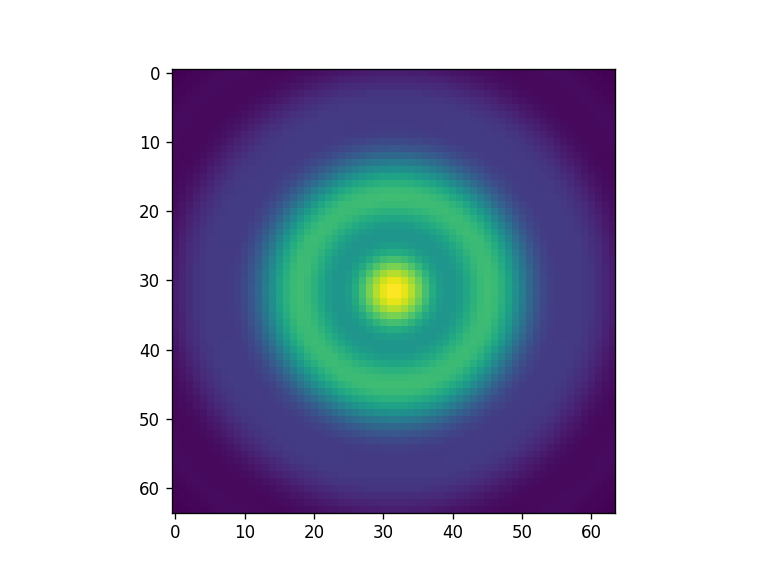

In [68]:
fig = plt.figure()
plt.imshow(np.abs(Exy.screen[:,:,-1])**2)

Picking up the last z propagated assumed to be the screen position


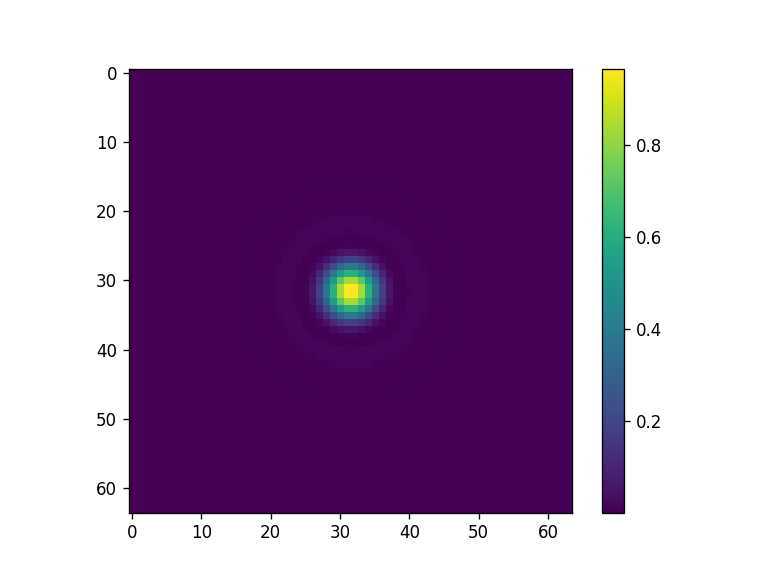

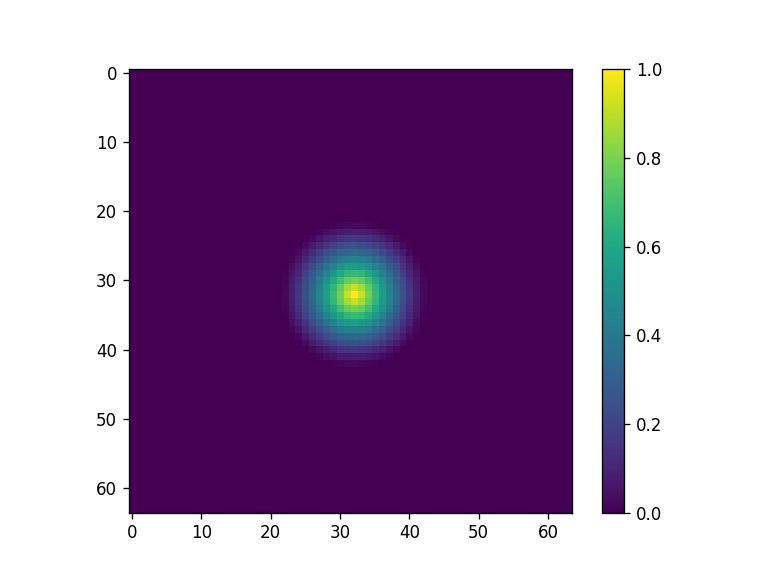

<Figure size 768x576 with 0 Axes>

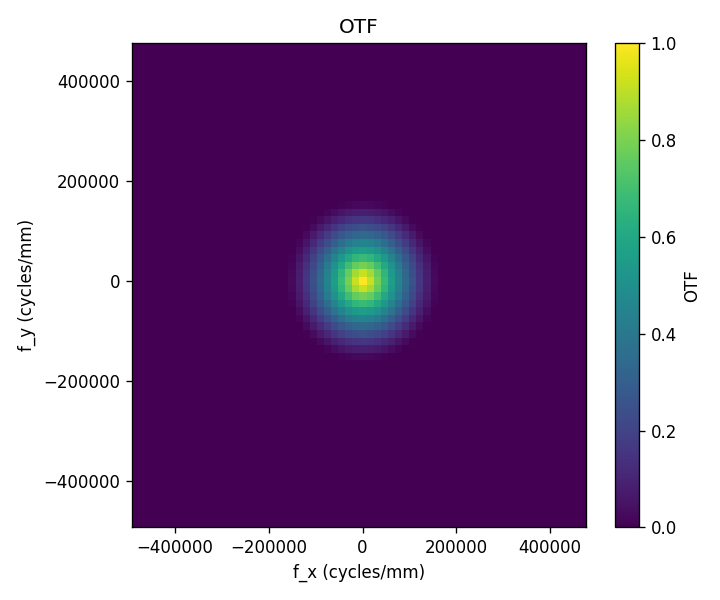

In [33]:
D = np.max(Exy.x)*2        

wavelength = 200e-9  # Wavelength in meters (e.g., 550 nm)

intensity_circular = intensity_theo_Airy(screen, D*2, wavelength, z=1)


fig = plt.figure() 
plt.imshow(intensity_circular  )
plt.colorbar()

OTF_circular = calculate_OTF(intensity_circular)


fig = plt.figure()
plt.imshow(np.abs(OTF_circular) )
plt.colorbar()

fig = plt.figure()

N = 512
dx = 10e-6  # pixel pitch in meters
dy = 10e-6


# Plot
plt.figure(figsize=(6, 5))
plt.imshow(np.abs(OTF_circular), extent=(np.min(Exy.fx), np.max(Exy.fx), np.min(Exy.fy), np.max(Exy.fy)),
           origin='lower', cmap='viridis', aspect='auto')
plt.colorbar(label='OTF')
plt.xlabel('f_x (cycles/mm)')
plt.ylabel('f_y (cycles/mm)')
plt.title('OTF')
plt.tight_layout()
plt.show()

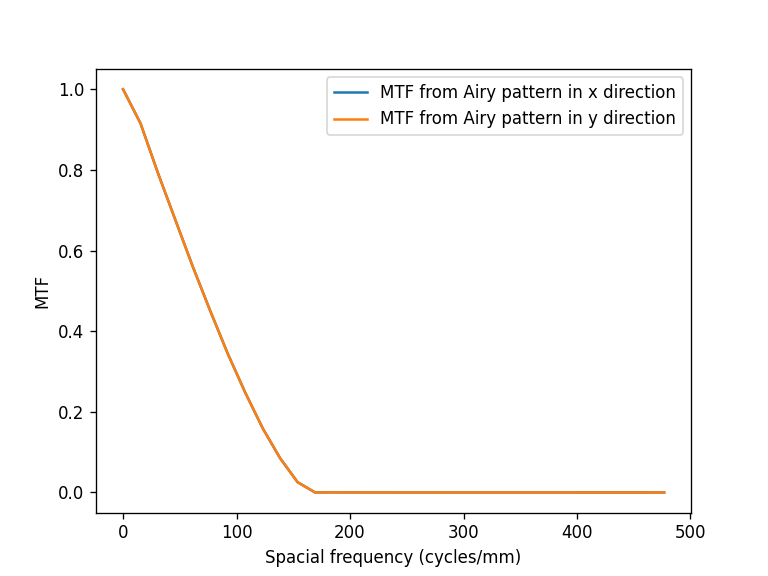

In [34]:
mtf, mtfx1, mtfy1 = moe.metrics.MTF_from_OTF(OTF_circular)


fx, fy = screen.fx*1e-3, screen.fy *1e-3

fig = plt.figure() 
plt.plot(fx[np.where(fx>=0)],  mtfx1, label="MTF from Airy pattern in x direction")
plt.plot(fy[np.where(fy>=0)],  mtfy1, label="MTF from Airy pattern in y direction")
plt.xlabel("Spacial frequency (cycles/mm)")
plt.ylabel("MTF")

plt.legend()


In [35]:


otf = moe.metrics.theoretical_ideal_OTF(screen, D*2, wavelength, screen.z[-1]) 

mtf, mtfx2, mtfy2 = moe.metrics.MTF_from_OTF(otf)

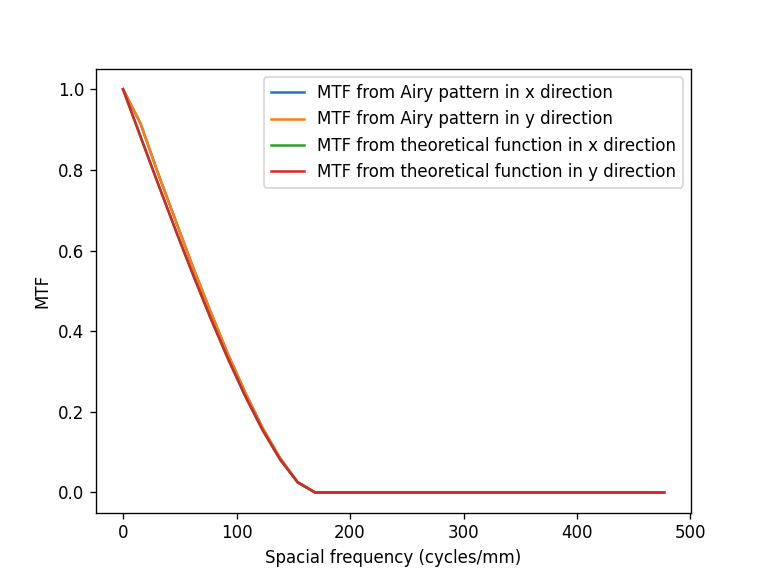

In [36]:
fx = screen.fx*1e-3
fy = screen.fy*1e-3

fig = plt.figure() 
plt.plot(fx[np.where(fx>=0)],  mtfx1, label="MTF from Airy pattern in x direction")
plt.plot(fy[np.where(fy>=0)],  mtfy1, label="MTF from Airy pattern in y direction")
plt.plot(fx[np.where(fx>=0)],  mtfx2, label="MTF from theoretical function in x direction")
plt.plot(fy[np.where(fy>=0)],  mtfy2, label="MTF from theoretical function in y direction")
plt.xlabel("Spacial frequency (cycles/mm)")
plt.ylabel("MTF")

plt.legend()

Text(0, 0.5, 'MTF')

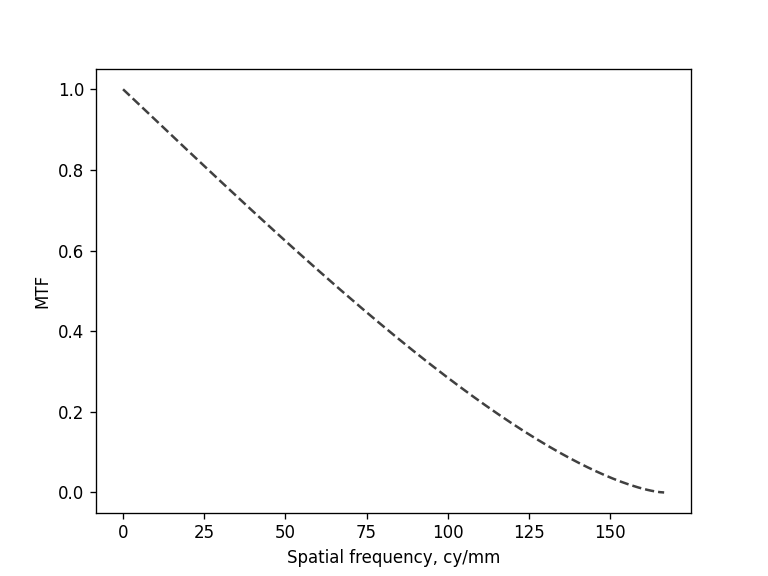

In [37]:
#TO ERASE 

from prysm.otf import mtf_from_psf, diffraction_limited_mtf

efl = screen.z[-1] * 1e3


#NA = 0.25
NA = np.sin(np.arctan(D*2/2/screen.z[-1]) )
fno = 1/(2*NA) #f number
#fno = screen.z[-1]/(D/2)

wvl = wavelength * 1e6  # mid visible band, um

freq, difflim = diffraction_limited_mtf(fno, wvl)

fig = plt.figure()
plt.plot(freq, difflim, ls='--', c='k', alpha=0.75, zorder=1)
plt.xlabel('Spatial frequency, cy/mm')
plt.ylabel('MTF')

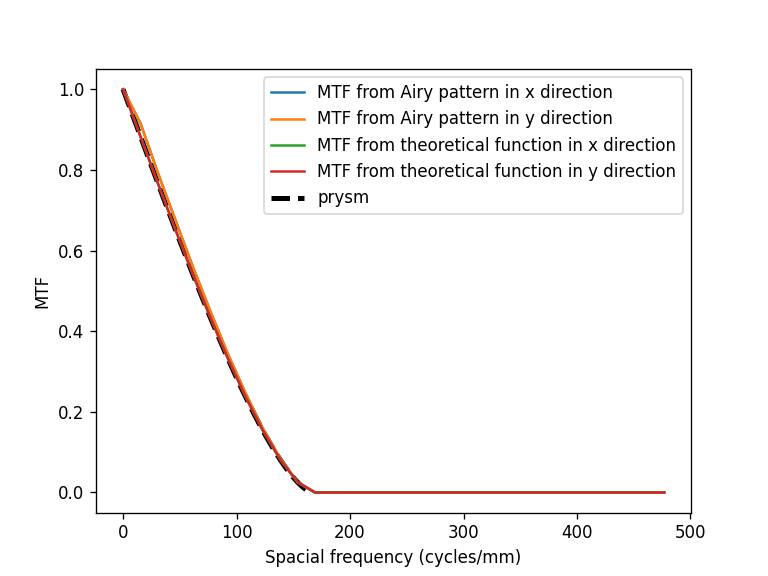

In [38]:
fx = screen.fx*1e-3
fy = screen.fy*1e-3

fig = plt.figure() 
plt.plot(fx[np.where(fx>=0)],  mtfx1, label="MTF from Airy pattern in x direction")
plt.plot(fy[np.where(fy>=0)],  mtfy1, label="MTF from Airy pattern in y direction")
plt.plot(fx[np.where(fx>=0)],  mtfx2, label="MTF from theoretical function in x direction")
plt.plot(fy[np.where(fy>=0)],  mtfy2, label="MTF from theoretical function in y direction")
plt.xlabel("Spacial frequency (cycles/mm)")
plt.ylabel("MTF")

freq, difflim = diffraction_limited_mtf(fno, wvl)

plt.plot(freq, difflim, ls='--', c='k', lw=3, zorder=1, label="prysm")

plt.legend()

In [39]:
#This should give 1 

moe.metrics.strehl_ratio(intensity_circular, screen, D*2, wavelength, z = screen.z[-1])

0.998955749058071